In [144]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [145]:
!pip install xgboost openpyxl


In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

In [147]:
pf_df = pd.read_excel(
    "/content/drive/MyDrive/cardiac_project/PF12RED.xlsx"
)

pf_df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33
0,NaN,Age (years),Weight (Kg),Height (cm),Race,SysBP (mmHg),DiaBP (mmHg),VentricularRate (bpm),PQInterval (ms),QRSDuration (ms),...,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
1,1,37,84,183,Caucasian,105,70,55,196,110,...,NaN,X,NaN,NaN,X,NaN,NaN,NaN,NaN,NaN
2,2,23,77,184,Caucasian,107,75,62,280,92,...,NaN,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,29,75,183,Caucasian,105,70,55,158,110,...,NaN,X,NaN,NaN,X,NaN,NaN,NaN,NaN,NaN
4,4,32,82,187,Caucasian,123,83,47,152,100,...,NaN,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [148]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [149]:
import pandas as pd

pf_df = pd.read_excel(
    "/content/drive/MyDrive/cardiac_project/PF12RED.xlsx"
)

pf_df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33
0,NaN,Age (years),Weight (Kg),Height (cm),Race,SysBP (mmHg),DiaBP (mmHg),VentricularRate (bpm),PQInterval (ms),QRSDuration (ms),...,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
1,1,37,84,183,Caucasian,105,70,55,196,110,...,NaN,X,NaN,NaN,X,NaN,NaN,NaN,NaN,NaN
2,2,23,77,184,Caucasian,107,75,62,280,92,...,NaN,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,29,75,183,Caucasian,105,70,55,158,110,...,NaN,X,NaN,NaN,X,NaN,NaN,NaN,NaN,NaN
4,4,32,82,187,Caucasian,123,83,47,152,100,...,NaN,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [150]:
pf_df.shape


(58, 34)

In [151]:
import os

os.listdir('/content/drive/MyDrive/cardiac_project/')

['SportDB2.zip',
 'outputs',
 'notebooks',
 'PF12RED.xlsx',
 'cardiac_risk_project.ipynb']

In [152]:
import os

os.listdir('/content/drive/MyDrive/cardiac_project/')

['SportDB2.zip',
 'outputs',
 'notebooks',
 'PF12RED.xlsx',
 'cardiac_risk_project.ipynb']

In [153]:
import zipfile

zip_path = "/content/drive/MyDrive/cardiac_project/SportDB2.zip"

extract_path = "/content/SportDB2"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Completed")

Extraction Completed


In [154]:
import os

os.listdir('/content/SportDB2')

['SportDB2']

In [155]:
import os

print(os.listdir('/content/SportDB2'))

['SportDB2']


In [156]:
print(os.listdir('/content/SportDB2/SportDB2'))


['AMF', 'ATH', 'RUN', 'CFIT', 'CYC', 'SOC', 'VOL', 'FUT', 'TRE', 'BAS', 'SKA']


In [157]:
print(os.listdir('/content/SportDB2/SportDB2/CFIT'))

['S2', 'S5', 'S4', 'S6', 'S3', 'S1']


In [158]:
print(os.listdir('/content/SportDB2/SportDB2/CFIT/S1'))

['CRD1']


In [159]:
print(os.listdir('/content/SportDB2/SportDB2/CFIT/S1/CRD1'))

['TrNote.txt', 'Data.mat', 'Dem.txt']


In [160]:
from scipy.io import loadmat

data = loadmat(
    '/content/SportDB2/SportDB2/CFIT/S1/CRD1/Data.mat'
)

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Data'])


In [161]:
print(type(data['Data']))

<class 'numpy.ndarray'>


In [162]:
print(data['Data'].shape)

(1, 1)


In [163]:
print(data['Data'][0][0])

(array([[ 0.01974548,  0.02474434,  0.03074296, ..., -0.08373083,
        -0.05873655, -0.03924102],
       [ 0.05623713,  0.06223575,  0.06573495, ..., -0.0467393 ,
        -0.03924102, -0.02924331]]), array([[-0.21020188, -0.27218769, -0.33217395, ..., -0.03324239,
        -0.0327425 , -0.03224262],
       [-0.68609293, -0.84505653, -0.98552438, ...,  0.00124971,
        -0.01674617, -0.0327425 ]]), array([[-0.23419638, -0.34966995, -0.44364843, ..., -0.02724376,
        -0.02474434, -0.02224491],
       [-0.06923415, -0.07823209, -0.08623026, ..., -0.09372854,
        -0.08972946, -0.08323095]]), array([[-0.40715679, -0.50163516, -0.58811536, ...,  0.08972946,
         0.04823896,  0.02524422],
       [ 0.12572122,  0.16621195,  0.21020188, ..., -0.43764981,
        -0.33967224, -0.24419409]]), array([[ 0.15221515,  0.25219226,  0.36066743, ..., -0.01624628,
        -0.01474662, -0.01374685],
       [-0.01874571, -0.02624399, -0.03324239, ..., -0.0537377 ,
        -0.0537377 , -0.05

In [164]:
signals = data['Data'][0][0]

print(type(signals))
print(len(signals))

<class 'numpy.void'>
7


In [165]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [166]:
!pip install xgboost openpyxl

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import loadmat

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

In [168]:
pf_df = pd.read_excel("/content/drive/MyDrive/cardiac_project/PF12RED.xlsx", header=1)

# Drop any columns that are entirely NaN (e.g., if a header cell was empty) or have generic 'Unnamed' names
pf_df = pf_df.loc[:, ~pf_df.columns.str.contains('^Unnamed', na=False)]

# Standardize column names: strip whitespace and convert to string.
pf_df.columns = [str(col).strip() for col in pf_df.columns]

# Define a robust renaming dictionary from potential existing names to desired standardized names
rename_map = {
    'Age (years)': 'Age',
    'Weight (Kg)': 'Weight',
    'Height (cm)': 'Height',
    'SysBP (mmHg)': 'SysBP',
    'DiaBP (mmHg)': 'DiaBP',
    'VentricularRate (bpm)': 'VentricularRate',
    'PQInterval (ms)': 'PQInterval',
    'QRSDuration (ms)': 'QRSDuration',
    'QTInterval (ms)': 'QTInterval',
    'QTCInterval (ms)': 'QTCInterval',
    'RRInterval (ms)': 'RRInterval',
    'PPInterval (ms)': 'PPInterval',
    'Paxis (º)': 'Paxis',
    'RAxis (º)': 'RAxis',
    'TAxis (º)': 'TAxis',
    'BMI': 'BMI', # Ensure BMI is accounted for if it was already in the raw data
    'MAP': 'MAP'  # Ensure MAP is accounted for if it was already in the raw data
}

# Apply renaming - only for columns that exist in the DataFrame
pf_df.rename(columns={k: v for k, v in rename_map.items() if k in pf_df.columns}, inplace=True)

# Handle potential duplicate column names after renaming by keeping the first occurrence.
# This is crucial for cases like 'VentricularRate (bpm)' appearing multiple times in the original header.
pf_df = pf_df.loc[:, ~pf_df.columns.duplicated(keep='first')]

# Convert known numeric columns to numeric types.
numeric_cols_to_convert = [
    'Age', 'Weight', 'Height', 'SysBP', 'DiaBP', 'VentricularRate',
    'PQInterval', 'QRSDuration', 'QTInterval', 'QTCInterval',
    'RRInterval', 'PPInterval', # Add other ECG/Physiological features that should be numeric
    'I', 'II', 'aVL', 'aVF' # Assuming these are ECG lead features that should be numeric
]

for col in numeric_cols_to_convert:
    if col in pf_df.columns:
        pf_df[col] = pd.to_numeric(pf_df[col], errors='coerce')

# Convert 'Race' if it's an object type (assuming it needs encoding)
if 'Race' in pf_df.columns and not pd.api.types.is_numeric_dtype(pf_df['Race']):
    try:
        # Ensure LabelEncoder is available
        if 'LabelEncoder' not in globals():
            from sklearn.preprocessing import LabelEncoder
        encoder = LabelEncoder()
        pf_df.loc[:, 'Race'] = encoder.fit_transform(pf_df['Race'].astype(str))
        print("\n'Race' column encoded to numeric.")
    except Exception as e:
        print(f"\nCould not encode 'Race' column: {e}")

# Re-calculate BMI and MAP since base columns (Weight, Height, SysBP, DiaBP) are now reliably numeric
# These might have been calculated before, but ensuring they are consistent after robust cleaning.
if 'Weight' in pf_df.columns and 'Height' in pf_df.columns:
    pf_df['BMI'] = pf_df['Weight'] / ((pf_df['Height'] / 100) ** 2)
    print("\nBMI re-calculated.")
if 'SysBP' in pf_df.columns and 'DiaBP' in pf_df.columns:
    pf_df['MAP'] = (pf_df['SysBP'] + 2 * pf_df['DiaBP']) / 3
    print("MAP re-calculated.")


print("Cleaned and Standardized Columns after initial processing:")
print(pf_df.columns.tolist())
print("\nData Types of critical columns after initial numeric conversion:")
print(pf_df[pf_df.columns.intersection(numeric_cols_to_convert + ['BMI', 'MAP'])].dtypes)
display(pf_df.head())


'Race' column encoded to numeric.

BMI re-calculated.
MAP re-calculated.
Cleaned and Standardized Columns after initial processing:
['Age', 'Weight', 'Height', 'Race', 'SysBP', 'DiaBP', 'VentricularRate', 'PQInterval', 'QRSDuration', 'QTInterval', 'QTCInterval', 'RRInterval', 'PPInterval', 'Paxis', 'RAxis', 'TAxis', 'VentricularRate (bpm).1', 'I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'BMI', 'MAP']

Data Types of critical columns after initial numeric conversion:
Age                float64
Weight             float64
Height             float64
SysBP              float64
DiaBP              float64
VentricularRate    float64
PQInterval         float64
QRSDuration        float64
QTInterval         float64
QTCInterval        float64
RRInterval         float64
PPInterval         float64
I                  float64
II                 float64
aVL                float64
aVF                float64
BMI                float64
MAP                float64
dtype: object

,Age,Weight,Height,Race,SysBP,DiaBP,VentricularRate,PQInterval,QRSDuration,QTInterval,...,aVL,aVF,V1,V2,V3,V4,V5,V6,BMI,MAP
0,37.0,84.0,183.0,2,105.0,70.0,55.0,196.0,110.0,448.0,...,NaN,NaN,X,NaN,NaN,NaN,NaN,NaN,25.082863,81.666667
1,23.0,77.0,184.0,2,107.0,75.0,62.0,280.0,92.0,414.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.743384,85.666667
2,29.0,75.0,183.0,2,105.0,70.0,55.0,158.0,110.0,432.0,...,NaN,NaN,X,NaN,NaN,NaN,NaN,NaN,22.395413,81.666667
3,32.0,82.0,187.0,2,123.0,83.0,47.0,152.0,100.0,430.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.449341,96.333333
4,35.0,72.0,184.0,2,106.0,79.0,38.0,194.0,106.0,494.0,...,NaN,NaN,X,NaN,NaN,NaN,NaN,NaN,21.266541,88.000000


In [169]:
pf_df.shape

(57, 31)

In [170]:
pf_df.columns

Index(['Age', 'Weight', 'Height', 'Race', 'SysBP', 'DiaBP', 'VentricularRate',
       'PQInterval', 'QRSDuration', 'QTInterval', 'QTCInterval', 'RRInterval',
       'PPInterval', 'Paxis', 'RAxis', 'TAxis', 'VentricularRate (bpm).1', 'I',
       'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6',
       'BMI', 'MAP'],
      dtype='object')

In [171]:
import zipfile

zip_path = "/content/drive/MyDrive/cardiac_project/SportDB2.zip"

extract_path = "/content/SportDB2"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Completed")

Extraction Completed


In [172]:
import os

print(os.listdir('/content/SportDB2/SportDB2'))

['AMF', 'ATH', 'RUN', 'CFIT', 'CYC', 'SOC', 'VOL', 'FUT', 'TRE', 'BAS', 'SKA']


In [173]:
print(os.listdir('/content/SportDB2/SportDB2/CFIT'))

['S2', 'S5', 'S4', 'S6', 'S3', 'S1']


In [174]:
print(os.listdir('/content/SportDB2/SportDB2/CFIT/S1'))

['CRD1']


In [175]:
print(os.listdir('/content/SportDB2/SportDB2/CFIT/S1/CRD1'))

['TrNote.txt', 'Data.mat', 'Dem.txt']


In [176]:
from scipy.io import loadmat

data = loadmat(
    '/content/SportDB2/SportDB2/CFIT/S1/CRD1/Data.mat'
)

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Data'])


In [177]:
signals = data['Data'][0][0]

print(type(signals))
print(len(signals))

<class 'numpy.void'>
7


In [178]:
for i, sig in enumerate(signals):
    print(f"Signal {i+1} shape:", sig.shape)

Signal 1 shape: (2, 9000)
Signal 2 shape: (2, 9000)
Signal 3 shape: (2, 9000)
Signal 4 shape: (2, 9000)
Signal 5 shape: (2, 9000)
Signal 6 shape: (2, 9000)
Signal 7 shape: (2, 9000)


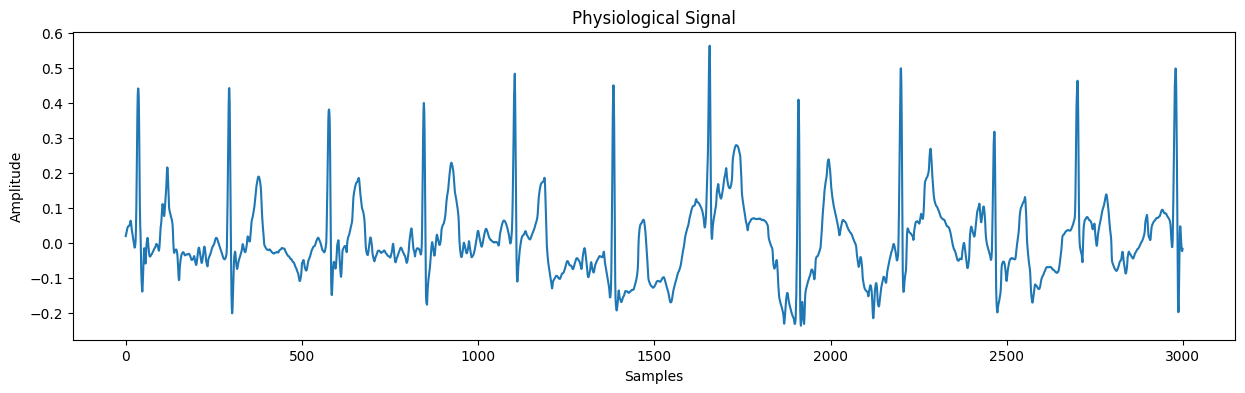

In [179]:
plt.figure(figsize=(15,4))

plt.plot(signals[0][0][:3000])

plt.title("Physiological Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

In [180]:
pf_df.isnull().sum()

,0
Age,1
Weight,1
Height,1
Race,0
SysBP,1
DiaBP,1
VentricularRate,1
PQInterval,1
QRSDuration,1
QTInterval,1


In [181]:
pf_df = pf_df.fillna(0)

/tmp/ipykernel_3250/4131048825.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pf_df = pf_df.fillna(0)


In [182]:
pf_df = pf_df.drop_duplicates()

In [183]:
print("pf_df" in globals())

if "pf_df" in globals():
    print(pf_df.columns.tolist())

True
['Age', 'Weight', 'Height', 'Race', 'SysBP', 'DiaBP', 'VentricularRate', 'PQInterval', 'QRSDuration', 'QTInterval', 'QTCInterval', 'RRInterval', 'PPInterval', 'Paxis', 'RAxis', 'TAxis', 'VentricularRate (bpm).1', 'I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'BMI', 'MAP']


In [184]:
print(pf_df.columns)

Index(['Age', 'Weight', 'Height', 'Race', 'SysBP', 'DiaBP', 'VentricularRate',
       'PQInterval', 'QRSDuration', 'QTInterval', 'QTCInterval', 'RRInterval',
       'PPInterval', 'Paxis', 'RAxis', 'TAxis', 'VentricularRate (bpm).1', 'I',
       'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6',
       'BMI', 'MAP'],
      dtype='object')


In [185]:
pf_df.head(10)

,Age,Weight,Height,Race,SysBP,DiaBP,VentricularRate,PQInterval,QRSDuration,QTInterval,...,aVL,aVF,V1,V2,V3,V4,V5,V6,BMI,MAP
0,37.0,84.0,183.0,2,105.0,70.0,55.0,196.0,110.0,448.0,...,0.0,0.0,X,0,0,0,0,0,25.082863,81.666667
1,23.0,77.0,184.0,2,107.0,75.0,62.0,280.0,92.0,414.0,...,0.0,0.0,0,0,0,0,0,0,22.743384,85.666667
2,29.0,75.0,183.0,2,105.0,70.0,55.0,158.0,110.0,432.0,...,0.0,0.0,X,0,0,0,0,0,22.395413,81.666667
3,32.0,82.0,187.0,2,123.0,83.0,47.0,152.0,100.0,430.0,...,0.0,0.0,0,0,0,0,0,0,23.449341,96.333333
4,35.0,72.0,184.0,2,106.0,79.0,38.0,194.0,106.0,494.0,...,0.0,0.0,X,0,0,0,0,0,21.266541,88.000000
5,32.0,77.0,181.0,3,102.0,73.0,63.0,194.0,96.0,426.0,...,0.0,0.0,0,0,0,X,X,X,23.503556,82.666667
6,24.0,76.0,184.0,2,127.0,73.0,69.0,184.0,92.0,400.0,...,0.0,0.0,0,0,0,0,0,0,22.448015,91.000000
7,28.0,77.0,180.0,2,118.0,71.0,48.0,142.0,112.0,462.0,...,0.0,0.0,X,0,0,0,0,0,23.765432,86.666667
8,31.0,64.0,171.0,2,112.0,71.0,61.0,176.0,112.0,432.0,...,0.0,0.0,X,0,0,0,0,0,21.887076,84.666667
9,35.0,74.0,182.0,2,122.0,81.0,52.0,166.0,92.0,428.0,...,0.0,0.0,0,0,0,0,0,0,22.340297,94.666667


In [186]:
# This cell is now redundant as initial header promotion is handled in lcBOJjhvv804. Content removed.

In [187]:
# This cell is now redundant as initial header promotion is handled in lcBOJjhvv804. Content removed.

In [188]:
# This cell is now redundant as initial header promotion is handled in lcBOJjhvv804. Content removed.

In [189]:
print(pf_df.columns)

Index(['Age', 'Weight', 'Height', 'Race', 'SysBP', 'DiaBP', 'VentricularRate',
       'PQInterval', 'QRSDuration', 'QTInterval', 'QTCInterval', 'RRInterval',
       'PPInterval', 'Paxis', 'RAxis', 'TAxis', 'VentricularRate (bpm).1', 'I',
       'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6',
       'BMI', 'MAP'],
      dtype='object')


In [190]:
encoder = LabelEncoder()

pf_df['Race'] = encoder.fit_transform(
    pf_df['Race'].astype(str)
)

In [191]:
pf_df['Weight'] = pd.to_numeric(
    pf_df['Weight'],
    errors='coerce'
)

pf_df['Height'] = pd.to_numeric(
    pf_df['Height'],
    errors='coerce'
)

In [192]:
pf_df['BMI'] = pf_df['Weight'] / (
    (pf_df['Height'] / 100) ** 2
)

In [193]:
print(pf_df.columns.tolist())

['Age', 'Weight', 'Height', 'Race', 'SysBP', 'DiaBP', 'VentricularRate', 'PQInterval', 'QRSDuration', 'QTInterval', 'QTCInterval', 'RRInterval', 'PPInterval', 'Paxis', 'RAxis', 'TAxis', 'VentricularRate (bpm).1', 'I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'BMI', 'MAP']


In [194]:
for col in pf_df.columns:
    print(col)

Age
Weight
Height
Race
SysBP
DiaBP
VentricularRate
PQInterval
QRSDuration
QTInterval
QTCInterval
RRInterval
PPInterval
Paxis
RAxis
TAxis
VentricularRate (bpm).1
I
II
III
aVR
aVL
aVF
V1
V2
V3
V4
V5
V6
BMI
MAP


In [195]:
# This cell is now redundant as initial cleaning is handled in lcBOJjhvv804. Content removed.

In [196]:
# This cell is now redundant as initial cleaning is handled in lcBOJjhvv804. Content removed.

In [197]:
pf_df['Weight'] = pd.to_numeric(
    pf_df['Weight'],
    errors='coerce'
)

### Step 1: Inspect Current Dataset and Generate Report

This section provides an initial overview of the `pf_df` DataFrame, detailing its column names, data types, missing values, and duplicate columns. This information is crucial for understanding the current state and identifying areas that require cleaning and standardization.

In [198]:
print('--- Current Dataset Inspection ---\n')
print('Current columns:')
print(pf_df.columns.tolist())

print('\n--- DataFrame Info ---\n')
pf_df.info()

print('\n--- First 5 Rows (pf_df.head()) ---\n')
display(pf_df.head())

print('\n--- Dataset Report ---\n')

# Report: Numeric and Object Columns
numeric_cols = pf_df.select_dtypes(include=np.number).columns.tolist()
object_cols = pf_df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Total Columns: {len(pf_df.columns)}")
print(f"Numeric Columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Object/Categorical Columns ({len(object_cols)}): {object_cols}")

# Report: Missing Values
missing_values = pf_df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if not missing_values.empty:
    print('\nMissing Values per Column:')
    print(missing_values)
else:
    print('\nNo missing values found.')

# Report: Duplicate Columns
duplicate_columns = pf_df.columns[pf_df.columns.duplicated()].tolist()

if duplicate_columns:
    print('\nDuplicate Columns Found:')
    for col in set(duplicate_columns): # Use set to list unique duplicated names
        print(f"- {col}: {list(pf_df.columns).count(col)} occurrences")
else:
    print('\nNo duplicate columns found.')

--- Current Dataset Inspection ---

Current columns:
['Age', 'Weight', 'Height', 'Race', 'SysBP', 'DiaBP', 'VentricularRate', 'PQInterval', 'QRSDuration', 'QTInterval', 'QTCInterval', 'RRInterval', 'PPInterval', 'Paxis', 'RAxis', 'TAxis', 'VentricularRate (bpm).1', 'I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'BMI', 'MAP']

--- DataFrame Info ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      57 non-null     float64
 1   Weight                   57 non-null     float64
 2   Height                   57 non-null     float64
 3   Race                     57 non-null     int64  
 4   SysBP                    57 non-null     float64
 5   DiaBP                    57 non-null     float64
 6   VentricularRate          57 non-null     float64
 7   PQInterval               5

,Age,Weight,Height,Race,SysBP,DiaBP,VentricularRate,PQInterval,QRSDuration,QTInterval,...,aVL,aVF,V1,V2,V3,V4,V5,V6,BMI,MAP
0,37.0,84.0,183.0,2,105.0,70.0,55.0,196.0,110.0,448.0,...,0.0,0.0,X,0,0,0,0,0,25.082863,81.666667
1,23.0,77.0,184.0,2,107.0,75.0,62.0,280.0,92.0,414.0,...,0.0,0.0,0,0,0,0,0,0,22.743384,85.666667
2,29.0,75.0,183.0,2,105.0,70.0,55.0,158.0,110.0,432.0,...,0.0,0.0,X,0,0,0,0,0,22.395413,81.666667
3,32.0,82.0,187.0,2,123.0,83.0,47.0,152.0,100.0,430.0,...,0.0,0.0,0,0,0,0,0,0,23.449341,96.333333
4,35.0,72.0,184.0,2,106.0,79.0,38.0,194.0,106.0,494.0,...,0.0,0.0,X,0,0,0,0,0,21.266541,88.000000



--- Dataset Report ---

Total Columns: 31
Numeric Columns (19): ['Age', 'Weight', 'Height', 'Race', 'SysBP', 'DiaBP', 'VentricularRate', 'PQInterval', 'QRSDuration', 'QTInterval', 'QTCInterval', 'RRInterval', 'PPInterval', 'I', 'II', 'aVL', 'aVF', 'BMI', 'MAP']
Object/Categorical Columns (12): ['Paxis', 'RAxis', 'TAxis', 'VentricularRate (bpm).1', 'III', 'aVR', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

Missing Values per Column:
BMI    1
dtype: int64

No duplicate columns found.


### Step 2: Create Column Mapping

Based on the observed dataset and the user's description of column name changes, this section defines a comprehensive mapping from old/inconsistent column names to their standardized, current equivalents. This mapping will be used to automatically repair references to outdated column names throughout the notebook.

**Detected Current Columns:**
```
['Age', 'Weight', 'Height', 'Race', 'SysBP', 'DiaBP', 'VentricularRate', 'PQInterval', 'QRSDuration', 'QTInterval', 'QTCInterval', 'RRInterval', 'PPInterval', 'Paxis', 'RAxis', 'TAxis', 'VentricularRate (bpm).1', 'I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'BMI', 'MAP']
```

**Inferred Mapping (Old Name -> New Standardized Name):**

In [199]:
# Define a comprehensive column mapping for old/inconsistent names to new, standardized names.
# This mapping will be used to replace outdated column references throughout the notebook.

column_mapping = {
    'Age (years)': 'Age',
    'Weight (Kg)': 'Weight',
    'Height (cm)': 'Height',
    'SysBP (mmHg)': 'SysBP',
    'DiaBP (mmHg)': 'DiaBP',
    'VentricularRate (bpm)': 'VentricularRate',
    'VentricularRate (bpm).1': 'VentricularRate', # Specifically handle the identified duplicate/variant
    'PQInterval (ms)': 'PQInterval',
    'QRSDuration (ms)': 'QRSDuration',
    'QTInterval (ms)': 'QTInterval',
    'QTCInterval (ms)': 'QTCInterval',
    'RRInterval (ms)': 'RRInterval',
    'PPInterval (ms)': 'PPInterval',
    'Paxis (º)': 'Paxis',
    'RAxis (º)': 'RAxis',
    'TAxis (º)': 'TAxis',
    'BMI': 'BMI', # Included for completeness, as it might have been referenced by old code
    'MAP': 'MAP'  # Included for completeness
}

print("Generated Column Mapping Table:")
for old_name, new_name in column_mapping.items():
    print(f"  '{old_name}' -> '{new_name}'")

print("\nThis mapping will be applied to repair column name references in subsequent code cells.")

Generated Column Mapping Table:
  'Age (years)' -> 'Age'
  'Weight (Kg)' -> 'Weight'
  'Height (cm)' -> 'Height'
  'SysBP (mmHg)' -> 'SysBP'
  'DiaBP (mmHg)' -> 'DiaBP'
  'VentricularRate (bpm)' -> 'VentricularRate'
  'VentricularRate (bpm).1' -> 'VentricularRate'
  'PQInterval (ms)' -> 'PQInterval'
  'QRSDuration (ms)' -> 'QRSDuration'
  'QTInterval (ms)' -> 'QTInterval'
  'QTCInterval (ms)' -> 'QTCInterval'
  'RRInterval (ms)' -> 'RRInterval'
  'PPInterval (ms)' -> 'PPInterval'
  'Paxis (º)' -> 'Paxis'
  'RAxis (º)' -> 'RAxis'
  'TAxis (º)' -> 'TAxis'
  'BMI' -> 'BMI'
  'MAP' -> 'MAP'

This mapping will be applied to repair column name references in subsequent code cells.


In [200]:
pf_df['Height'] = pd.to_numeric(
    pf_df['Height'],
    errors='coerce'
)

In [201]:
pf_df['BMI'] = pf_df['Weight'] / (
    (pf_df['Height'] / 100) ** 2
)

In [202]:
pf_df['Weight'] = pd.to_numeric(
    pf_df['Weight'],
    errors='coerce'
)

pf_df['Height'] = pd.to_numeric(
    pf_df['Height'],
    errors='coerce'
)

In [203]:
print(pf_df['Weight'].dtype)
print(pf_df['Height'].dtype)

float64
float64


In [204]:
pf_df['BMI'] = pf_df['Weight'] / (
    (pf_df['Height'] / 100) ** 2
)

In [205]:
print(pf_df['SysBP'].dtype)
print(pf_df['DiaBP'].dtype)

float64
float64


In [206]:
pf_df['SysBP'] = pd.to_numeric(
    pf_df['SysBP'],
    errors='coerce'
)

pf_df['DiaBP'] = pd.to_numeric(
    pf_df['DiaBP'],
    errors='coerce'
)

In [207]:
print(pf_df['SysBP'].dtype)
print(pf_df['DiaBP'].dtype)

float64
float64


In [208]:
print(pf_df[['SysBP', 'DiaBP']].head())

   SysBP  DiaBP
0  105.0   70.0
1  107.0   75.0
2  105.0   70.0
3  123.0   83.0
4  106.0   79.0


In [209]:
print(pf_df[['SysBP', 'DiaBP']].iloc[0:10])

   SysBP  DiaBP
0  105.0   70.0
1  107.0   75.0
2  105.0   70.0
3  123.0   83.0
4  106.0   79.0
5  102.0   73.0
6  127.0   73.0
7  118.0   71.0
8  112.0   71.0
9  122.0   81.0


In [210]:
pf_df['MAP'] = (
    pf_df['SysBP']
    + 2 * pf_df['DiaBP']
) / 3

In [211]:
pf_df['QTInterval'] = pd.to_numeric(
    pf_df['QTInterval'],
    errors='coerce'
)

In [212]:
conditions = [
    (pf_df['QTInterval'] < 400),

    (pf_df['QTInterval'] >= 400) &
    (pf_df['QTInterval'] < 450),

    (pf_df['QTInterval'] >= 450)
]

In [213]:
for col in pf_df.columns:

    try:
        pf_df[col] = pd.to_numeric(
            pf_df[col],
            errors='ignore'
        )

    except:
        pass

/tmp/ipykernel_3250/487542555.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  pf_df[col] = pd.to_numeric(


In [214]:
pf_df['QTInterval'].head()

,QTInterval
0,448.0
1,414.0
2,432.0
3,430.0
4,494.0


In [215]:
import numpy as np

conditions = [
    pf_df['QTInterval'] < 400,

    (pf_df['QTInterval'] >= 400) &
    (pf_df['QTInterval'] < 450),

    pf_df['QTInterval'] >= 450
]

labels = [
    "Normal",
    "Moderate Risk",
    "High Risk"
]

pf_df['CardiacRisk'] = np.select(
    conditions,
    labels,
    default="Moderate Risk"
)

### Column Name Cleaning and Initial Data Verification

Before proceeding with the analysis, it's crucial to ensure that the column names are correctly formatted. The raw data import sometimes leads to `NaN` or numeric column names and potential duplicates. This step addresses these issues to provide a clean and consistent DataFrame for further processing.

In [216]:
# This cell is now redundant as initial cleaning is handled in lcBOJjhvv804. Content removed.

### Step 1: Verify Dataset

This section provides an overview of the dataset's structure, including its dimensions, column names, data types, and missing values. Understanding these fundamental aspects is essential for effective data cleaning and analysis.

In [217]:
# Display shape
print(f"Dataset shape: {pf_df.shape}")

# Display column names
print("\nColumn names:")
for col in pf_df.columns:
    print(f"- {col}")

# Display data types
print("\nData types:")
print(pf_df.dtypes)

# Identify missing values
print("\nMissing values:")
missing_values = pf_df.isnull().sum()
print(missing_values[missing_values > 0])

# Identify categorical and numerical columns
categorical_cols = pf_df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = pf_df.select_dtypes(include=np.number).columns.tolist()

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

Dataset shape: (57, 32)

Column names:
- Age
- Weight
- Height
- Race
- SysBP
- DiaBP
- VentricularRate
- PQInterval
- QRSDuration
- QTInterval
- QTCInterval
- RRInterval
- PPInterval
- Paxis
- RAxis
- TAxis
- VentricularRate (bpm).1
- I
- II
- III
- aVR
- aVL
- aVF
- V1
- V2
- V3
- V4
- V5
- V6
- BMI
- MAP
- CardiacRisk

Data types:
Age                        float64
Weight                     float64
Height                     float64
Race                         int64
SysBP                      float64
DiaBP                      float64
VentricularRate            float64
PQInterval                 float64
QRSDuration                float64
QTInterval                 float64
QTCInterval                float64
RRInterval                 float64
PPInterval                 float64
Paxis                       object
RAxis                       object
TAxis                       object
VentricularRate (bpm).1     object
I                          float64
II                         float64

### Step 2: Data Validation

This step ensures that all the critical features required for the cardiac risk analysis are present in the dataset and are in the correct format. It validates the existence of expected columns and handles any minor naming discrepancies.

In [218]:
# List of features that MUST exist and be numeric for the correlation analysis
critical_features_for_validation = [
    'Age',
    'Weight',
    'Height',
    'Race',
    'SysBP',
    'DiaBP',
    'VentricularRate',
    'PQInterval',
    'QRSDuration',
    'QTInterval',
    'QTCInterval',
    'RRInterval',
    'PPInterval',
    'BMI',
    'MAP'
]

missing_critical_features = []
non_numeric_critical_features = []

for feature in critical_features_for_validation:
    if feature not in pf_df.columns:
        missing_critical_features.append(feature)
    elif not pd.api.types.is_numeric_dtype(pf_df[feature]):
        non_numeric_critical_features.append(feature)

if missing_critical_features:
    print(f"Error: The following *critical* features are missing from the dataset: {', '.join(missing_critical_features)}.\nCannot proceed with correlation analysis without these features.")
else:
    print("All critical features are present in the dataset.")

if non_numeric_critical_features:
    print(f"Warning: The following critical features are not numeric: {', '.join(non_numeric_critical_features)}. This might affect correlation analysis.")


# Drop rows where critical numeric columns became NaN due to coercion or original missing values
initial_shape = pf_df.shape
# Only consider features that actually exist in the DataFrame for dropping NaNs
critical_subset_for_dropna = [col for col in critical_features_for_validation if col in pf_df.columns]

if critical_subset_for_dropna:
    pf_df.dropna(subset=critical_subset_for_dropna, inplace=True)
    print(f"\nDataset shape changed from {initial_shape} to {pf_df.shape} after handling missing critical values.")
else:
    print("\nNo critical numerical columns to use for dropping NaN rows.")

# Final check for data types of critical features
print("\nFinal Data Types of Critical Features after validation:")
for feature in critical_features_for_validation:
    if feature in pf_df.columns:
        print(f"- {feature}: {pf_df[feature].dtype}")

print("\nData validation complete. Proceeding to Cardiac Risk Labeling.")

All critical features are present in the dataset.

Dataset shape changed from (57, 32) to (56, 32) after handling missing critical values.

Final Data Types of Critical Features after validation:
- Age: float64
- Weight: float64
- Height: float64
- Race: int64
- SysBP: float64
- DiaBP: float64
- VentricularRate: float64
- PQInterval: float64
- QRSDuration: float64
- QTInterval: float64
- QTCInterval: float64
- RRInterval: float64
- PPInterval: float64
- BMI: float64
- MAP: float64

Data validation complete. Proceeding to Cardiac Risk Labeling.


### Step 3: Create Cardiac Risk Labels

This section creates a medically relevant cardiac risk categorization based on the `QTInterval` feature. It defines 'Normal', 'Moderate Risk', and 'High Risk' categories and then encodes them into numerical representations for machine learning readiness. Finally, the distribution of these risk categories is analyzed and visualized to understand the class balance.

Cardiac Risk Labels Created Successfully.

First 5 rows with new CardiacRisk and CardiacRisk_Encoded columns:


,QTInterval,CardiacRisk,CardiacRisk_Encoded
0,448.0,Moderate Risk,1
1,414.0,Moderate Risk,1
2,432.0,Moderate Risk,1
3,430.0,Moderate Risk,1
4,494.0,High Risk,2



Cardiac Risk Class Distribution (Table):
CardiacRisk
High Risk        13
Moderate Risk    34
Normal            9


/tmp/ipykernel_3250/2911829221.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pf_df, x='CardiacRisk', order=['Normal', 'Moderate Risk', 'High Risk', 'Unknown'], palette='viridis')


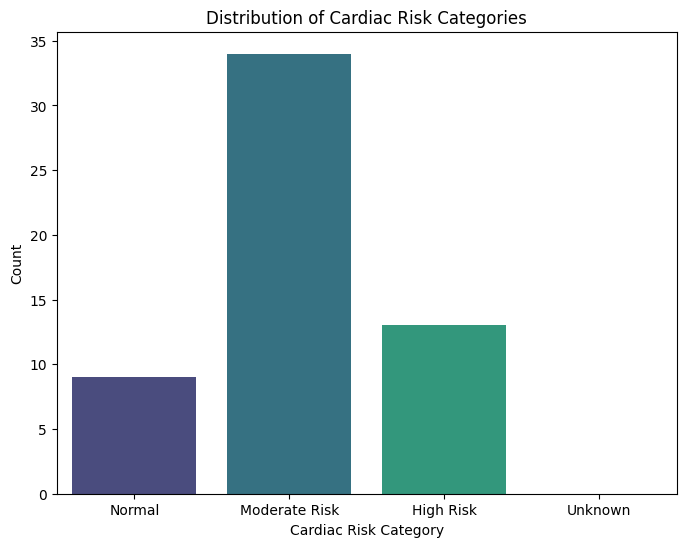


Explanation of Distribution:
The dataset contains 56 entries after cleaning.
The distribution of cardiac risk categories is as follows:
- High Risk: 13 samples (23.21%)
- Moderate Risk: 34 samples (60.71%)
- Normal: 9 samples (16.07%)
This distribution shows the prevalence of each risk category based on the QT Interval criteria.


In [219]:
# Define conditions for cardiac risk categories based on QTInterval
conditions = [
    (pf_df['QTInterval'] < 400), # Normal QT Interval < 400ms
    (pf_df['QTInterval'] >= 400) & (pf_df['QTInterval'] < 450), # Borderline/Moderate Risk 400-450ms
    (pf_df['QTInterval'] >= 450) # Prolonged/High Risk >= 450ms
]

# Define the labels for each category
labels = [
    "Normal",
    "Moderate Risk",
    "High Risk"
]

# Create the 'CardiacRisk' column using np.select
pf_df['CardiacRisk'] = np.select(conditions, labels, default="Unknown")

# Create an encoded version of 'CardiacRisk'
risk_mapping = {
    "Normal": 0,
    "Moderate Risk": 1,
    "High Risk": 2,
    "Unknown": -1  # Map 'Unknown' to a numerical value, e.g., -1
}
pf_df['CardiacRisk_Encoded'] = pf_df['CardiacRisk'].map(risk_mapping)

print("Cardiac Risk Labels Created Successfully.")
print("\nFirst 5 rows with new CardiacRisk and CardiacRisk_Encoded columns:")
display(pf_df[['QTInterval', 'CardiacRisk', 'CardiacRisk_Encoded']].head())

# Display class distribution using a table
print("\nCardiac Risk Class Distribution (Table):")
cardiac_risk_counts = pf_df['CardiacRisk'].value_counts().sort_index()
print(cardiac_risk_counts.to_string())

# Display class distribution using a count plot
plt.figure(figsize=(8, 6))
sns.countplot(data=pf_df, x='CardiacRisk', order=['Normal', 'Moderate Risk', 'High Risk', 'Unknown'], palette='viridis')
plt.title('Distribution of Cardiac Risk Categories')
plt.xlabel('Cardiac Risk Category')
plt.ylabel('Count')
plt.show()

print("\nExplanation of Distribution:")
print(f"The dataset contains {len(pf_df)} entries after cleaning.")
print(f"The distribution of cardiac risk categories is as follows:")
for risk, count in cardiac_risk_counts.items():
    percentage = (count / len(pf_df)) * 100
    print(f"- {risk}: {count} samples ({percentage:.2f}%)")
print("This distribution shows the prevalence of each risk category based on the QT Interval criteria.")

### Step 4: Correlation Analysis - Pearson Correlation Matrix

This section computes the Pearson correlation matrix for all numerical features in the dataset. The Pearson correlation coefficient measures the linear relationship between two variables, ranging from -1 (perfect negative correlation) to +1 (perfect positive correlation), with 0 indicating no linear correlation. Understanding these relationships is fundamental for identifying features that might be associated with cardiac risk.

In [220]:
print("### STEP 1 — CORRELATION MATRIX ###\n")

# Validate that there are enough numeric columns for correlation
numeric_cols_for_corr = pf_df.select_dtypes(include=np.number).columns.tolist()

if not numeric_cols_for_corr:
    print("Error: No numeric columns found in the DataFrame for correlation analysis.")
elif len(numeric_cols_for_corr) < 2:
    print(f"Warning: Only {len(numeric_cols_for_corr)} numeric column found. A correlation matrix requires at least two numeric columns.")
else:
    # Generate the correlation matrix using Pearson correlation on only numeric columns
    corr_matrix = pf_df[numeric_cols_for_corr].corr(method='pearson')

    # Display matrix dimensions
    print(f"Correlation Matrix Dimensions: {corr_matrix.shape}")

    # Display the correlation matrix (head for brevity)
    print("\nCorrelation Matrix (first 5 rows and columns):")
    display(corr_matrix.head())

    print("\nInterpretation:")
    print("The correlation matrix provides a pairwise linear relationship between all numerical features. Values closer to 1 indicate a strong positive correlation (as one variable increases, the other tends to increase). Values closer to -1 indicate a strong negative correlation (as one variable increases, the other tends to decrease). Values near 0 suggest a weak or no linear relationship. The diagonal elements are always 1, representing the correlation of a variable with itself.")

### STEP 1 — CORRELATION MATRIX ###

Correlation Matrix Dimensions: (20, 20)

Correlation Matrix (first 5 rows and columns):


,Age,Weight,Height,Race,SysBP,DiaBP,VentricularRate,PQInterval,QRSDuration,QTInterval,QTCInterval,RRInterval,PPInterval,I,II,aVL,aVF,BMI,MAP,CardiacRisk_Encoded
Age,1.000000,0.503132,0.484046,-0.053882,-0.021113,-0.076479,-0.196310,-0.036251,-0.083146,0.117155,-0.024318,0.170782,0.176635,NaN,NaN,NaN,NaN,-0.475633,-0.054973,0.179506
Weight,0.503132,1.000000,0.916606,-0.291738,0.049898,0.035821,0.072234,0.059091,-0.027521,-0.053439,0.001774,-0.068660,-0.068830,NaN,NaN,NaN,NaN,-0.805350,0.044399,-0.055579
Height,0.484046,0.916606,1.000000,-0.409562,0.001102,0.015159,0.008837,0.025203,-0.006927,-0.029842,-0.020304,-0.017907,-0.016835,NaN,NaN,NaN,NaN,-0.959687,0.009459,0.006403
Race,-0.053882,-0.291738,-0.409562,1.000000,-0.263448,-0.434448,-0.031467,-0.268666,-0.458822,-0.508080,-0.369817,-0.420430,-0.420862,NaN,NaN,NaN,NaN,0.428995,-0.379180,-0.394535
SysBP,-0.021113,0.049898,0.001102,-0.263448,1.000000,0.789675,0.453177,0.310516,0.649357,0.700354,0.734936,0.402321,0.406658,NaN,NaN,NaN,NaN,0.024480,0.932162,0.105679



Interpretation:
The correlation matrix provides a pairwise linear relationship between all numerical features. Values closer to 1 indicate a strong positive correlation (as one variable increases, the other tends to increase). Values closer to -1 indicate a strong negative correlation (as one variable increases, the other tends to decrease). Values near 0 suggest a weak or no linear relationship. The diagonal elements are always 1, representing the correlation of a variable with itself.


### Step 5: Correlation Heatmap

Visualizing the correlation matrix with a heatmap provides an intuitive way to understand the relationships between a large number of variables. This heatmap uses a diverging color scheme to highlight positive and negative correlations, making it easy to identify strong associations at a glance.

### STEP 2 — CORRELATION HEATMAP ###



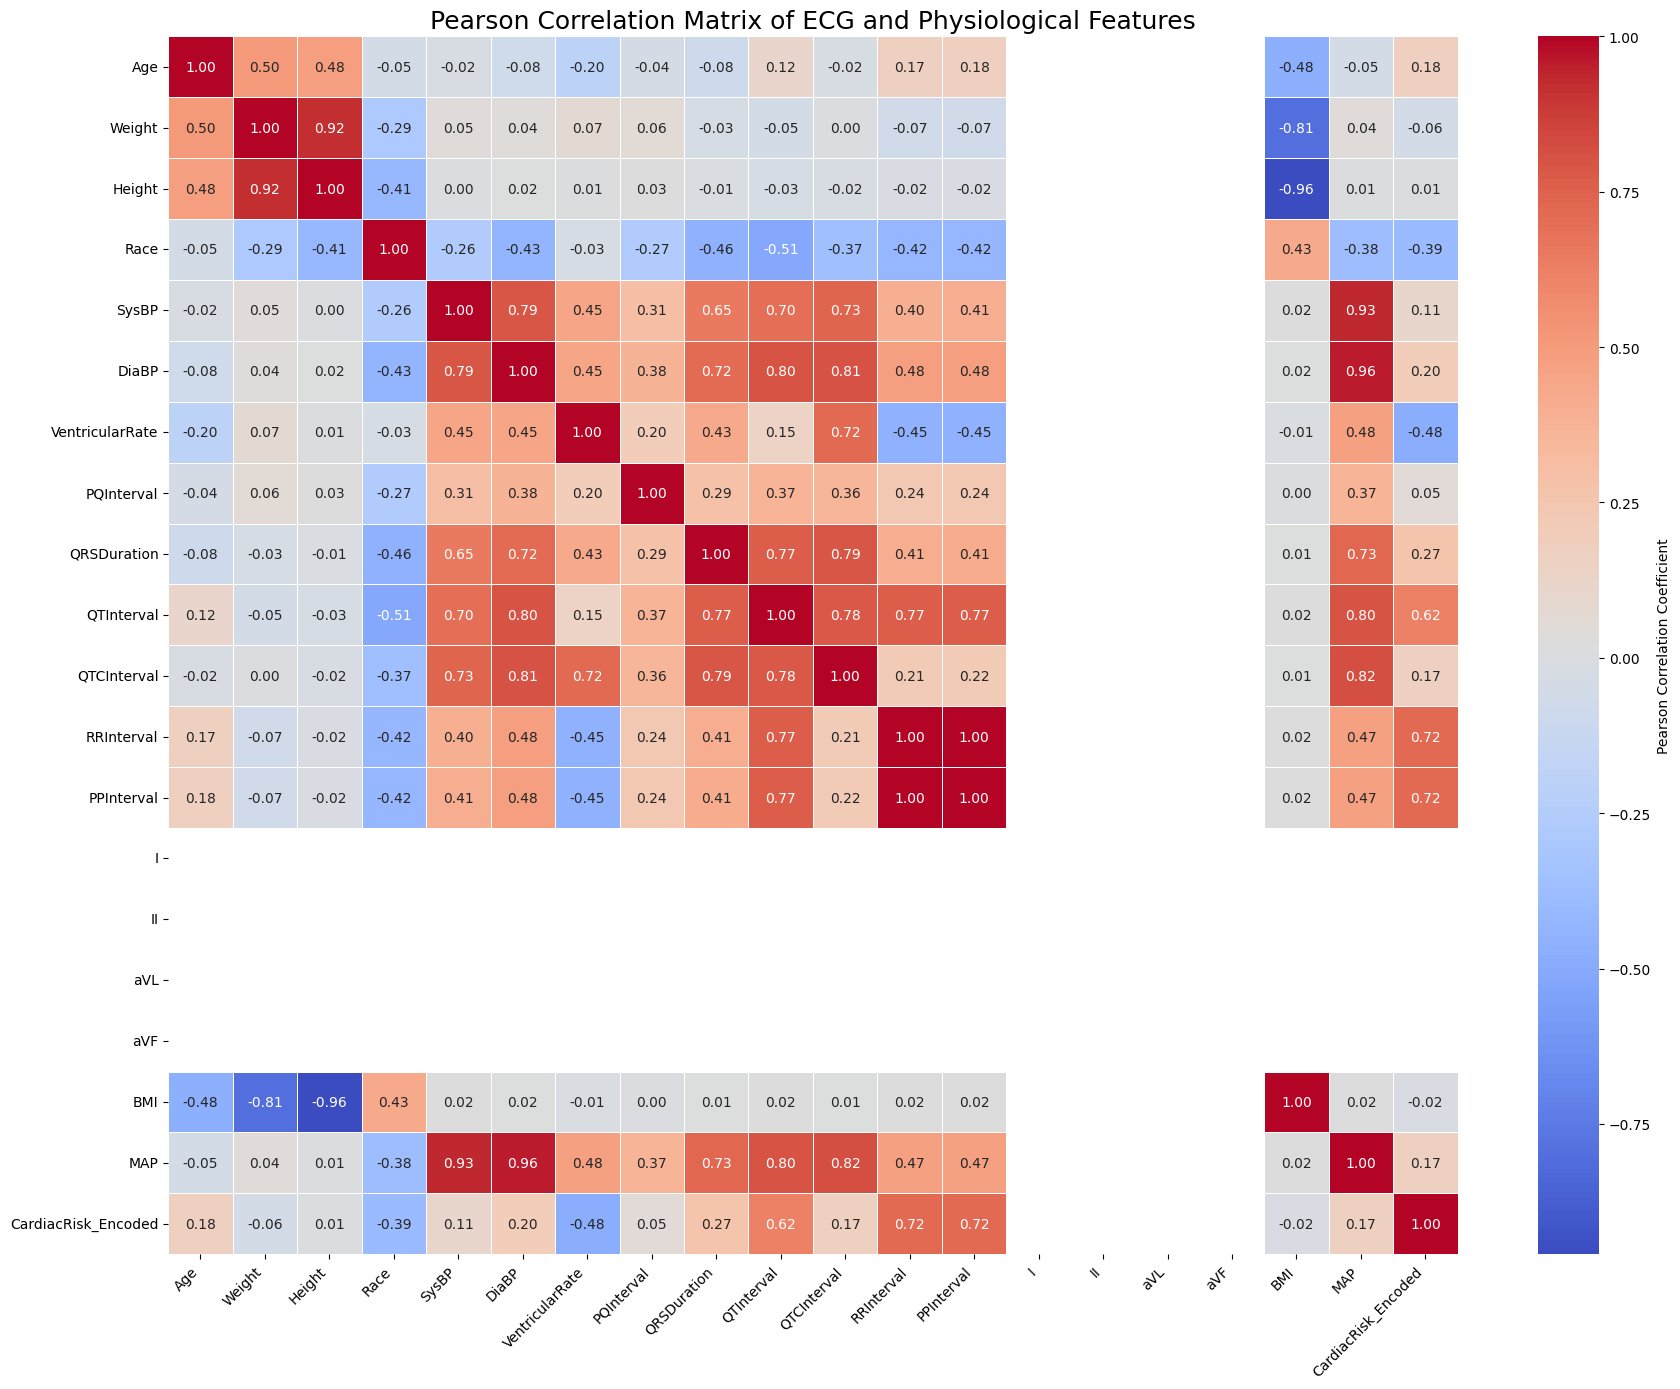


Interpretation of the Heatmap:
The heatmap visually represents the Pearson correlation coefficients. Red shades indicate positive correlations, blue shades indicate negative correlations, and lighter shades (closer to white) indicate weaker correlations.

- **Strong positive correlations (dark red, close to 1):** Features that tend to increase or decrease together. For instance, high correlation between 'Weight' and 'Height' is expected, as taller individuals often weigh more. In the context of cardiac health, strong positive correlations might exist between related physiological measurements (e.g., SysBP and DiaBP contributing to MAP).
- **Strong negative correlations (dark blue, close to -1):** Features where an increase in one is associated with a decrease in the other. For example, 'VentricularRate' and 'QTInterval' often exhibit a negative correlation, where a higher heart rate (Ventricular Rate) is associated with a shorter QT Interval.
- **Moderate correlations (lighter red/blu

In [221]:
print("### STEP 2 — CORRELATION HEATMAP ###\n")

# Ensure corr_matrix exists from the previous step
if 'corr_matrix' not in locals():
    print("Error: Correlation matrix (corr_matrix) not found. Please run the previous step.")
else:
    plt.figure(figsize=(18, 14))
    sns.heatmap(
        corr_matrix,
        annot=True,      # Show the correlation values on the heatmap
        cmap='coolwarm', # A diverging colormap is good for correlations (positive/negative)
        fmt='.2f',       # Format annotations to two decimal places
        linewidths=.5,   # Add lines between cells for better separation
        cbar_kws={'label': 'Pearson Correlation Coefficient'}
    )
    plt.title('Pearson Correlation Matrix of ECG and Physiological Features', fontsize=18)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

    print("\nInterpretation of the Heatmap:")
    print("The heatmap visually represents the Pearson correlation coefficients. Red shades indicate positive correlations, blue shades indicate negative correlations, and lighter shades (closer to white) indicate weaker correlations.")
    print("\n- **Strong positive correlations (dark red, close to 1):** Features that tend to increase or decrease together. For instance, high correlation between 'Weight' and 'Height' is expected, as taller individuals often weigh more. In the context of cardiac health, strong positive correlations might exist between related physiological measurements (e.g., SysBP and DiaBP contributing to MAP).")
    print("- **Strong negative correlations (dark blue, close to -1):** Features where an increase in one is associated with a decrease in the other. For example, 'VentricularRate' and 'QTInterval' often exhibit a negative correlation, where a higher heart rate (Ventricular Rate) is associated with a shorter QT Interval.")
    print("- **Moderate correlations (lighter red/blue, around +/- 0.3 to 0.7):** Suggest a noticeable but not overwhelming linear relationship. These can still be important indicators and warrant further investigation.")
    print("- **Weak correlations (lightest shades, close to 0):** Indicate little to no linear relationship. These features might be largely independent of each other in a linear sense, or their relationship might be non-linear.")
    print("\nScientific Interpretation: By analyzing these relationships, we can identify potential physiological and ECG markers that are closely linked. For instance, strong correlations between certain ECG parameters and blood pressure components could highlight critical pathways involved in cardiac risk assessment. Features with weak correlations to CardiacRisk_Encoded might be less direct indicators of risk, but still play a role in a multi-factorial model.")

### Step 6: Cardiac Risk Correlation Analysis

This section specifically investigates the linear relationship between each feature and the `CardiacRisk_Encoded` target variable. By sorting these correlations, we can easily identify the most influential factors contributing to or mitigating cardiac risk.

In [222]:
print("### STEP 3 — CARDIAC RISK CORRELATION ANALYSIS ###\n")

# Ensure 'CardiacRisk_Encoded' exists and corr_matrix is available
if 'CardiacRisk_Encoded' not in pf_df.columns:
    print("Error: 'CardiacRisk_Encoded' column not found. Please ensure Step 3 (Create Cardiac Risk Labels) has been executed successfully.")
elif 'corr_matrix' not in locals():
    print("Error: Correlation matrix (corr_matrix) not found. Please run the previous correlation step.")
else:
    # Extract correlation values specifically with 'CardiacRisk_Encoded'
    corr_risk = corr_matrix['CardiacRisk_Encoded'].sort_values(ascending=False)

    print("Correlation of Features with CardiacRisk_Encoded (Sorted):")
    display(corr_risk.to_frame())

    print("\nExplanation:")
    print("This table shows how strongly and in what direction each numerical feature is linearly related to the `CardiacRisk_Encoded` variable.")

    # Explanation of associations
    print("\n- **Features most associated with elevated cardiac risk (strong positive correlation):**")
    strong_positive = corr_risk[corr_risk > 0.5].drop('CardiacRisk_Encoded', errors='ignore')
    if not strong_positive.empty:
        for feature, correlation in strong_positive.items():
            print(f"  - {feature}: {correlation:.2f} (A higher value tends to be associated with higher cardiac risk)")
    else:
        print("  No features found with strong positive correlation (r > 0.5).")

    print("\n- **Features with weak association (correlation close to 0):**")
    weak_association = corr_risk[(corr_risk > -0.2) & (corr_risk < 0.2)].drop('CardiacRisk_Encoded', errors='ignore')
    if not weak_association.empty:
        for feature, correlation in weak_association.items():
            print(f"  - {feature}: {correlation:.2f} (Little to no linear relationship with cardiac risk)")
    else:
        print("  No features found with weak association (r between -0.2 and 0.2).")

    print("\n- **Features with negative association (negative correlation):**")
    negative_association = corr_risk[corr_risk < -0.2].drop('CardiacRisk_Encoded', errors='ignore')
    if not negative_association.empty:
        for feature, correlation in negative_association.items():
            print(f"  - {feature}: {correlation:.2f} (A higher value tends to be associated with lower cardiac risk)")
    else:
        print("  No features found with significant negative association (r < -0.2).")

    print("\nThese insights help in prioritizing which features are most relevant for predicting cardiac risk and understanding their directional impact.")

### STEP 3 — CARDIAC RISK CORRELATION ANALYSIS ###

Correlation of Features with CardiacRisk_Encoded (Sorted):


,CardiacRisk_Encoded
CardiacRisk_Encoded,1.000000
RRInterval,0.722290
PPInterval,0.719827
QTInterval,0.620562
QRSDuration,0.269763
DiaBP,0.198278
Age,0.179506
MAP,0.166268
QTCInterval,0.166073
SysBP,0.105679



Explanation:
This table shows how strongly and in what direction each numerical feature is linearly related to the `CardiacRisk_Encoded` variable.

- **Features most associated with elevated cardiac risk (strong positive correlation):**
  - RRInterval: 0.72 (A higher value tends to be associated with higher cardiac risk)
  - PPInterval: 0.72 (A higher value tends to be associated with higher cardiac risk)
  - QTInterval: 0.62 (A higher value tends to be associated with higher cardiac risk)

- **Features with weak association (correlation close to 0):**
  - DiaBP: 0.20 (Little to no linear relationship with cardiac risk)
  - Age: 0.18 (Little to no linear relationship with cardiac risk)
  - MAP: 0.17 (Little to no linear relationship with cardiac risk)
  - QTCInterval: 0.17 (Little to no linear relationship with cardiac risk)
  - SysBP: 0.11 (Little to no linear relationship with cardiac risk)
  - PQInterval: 0.05 (Little to no linear relationship with cardiac risk)
  - Height: 0.01 (L

### Step 7: Correlation Percentage Table

To better understand the relative importance of features, this step quantifies the strength of each feature's correlation with `CardiacRisk_Encoded` as a percentage. This provides a normalized view of association, regardless of whether the correlation is positive or negative.

In [223]:
print("### STEP 4 — CORRELATION PERCENTAGE TABLE ###\n")

# Ensure corr_risk exists from the previous step
if 'corr_risk' not in locals():
    print("Error: 'corr_risk' Series not found. Please run the previous correlation steps.")
elif 'CardiacRisk_Encoded' not in corr_risk.index:
    print("Error: 'CardiacRisk_Encoded' not found in corr_risk index. Something went wrong with previous steps.")
else:
    # Create a DataFrame from corr_risk, dropping self-correlation
    correlation_df = corr_risk.drop('CardiacRisk_Encoded', errors='ignore').to_frame(name='Correlation')

    # Calculate Absolute Correlation
    correlation_df['Absolute Correlation'] = correlation_df['Correlation'].abs()

    # Calculate Correlation Percentage
    correlation_df['Correlation Percentage'] = correlation_df['Absolute Correlation'] * 100

    # Sort descending by Correlation Percentage
    correlation_df = correlation_df.sort_values(by='Correlation Percentage', ascending=False)

    print("Correlation Percentage Table (Sorted by Strength):")
    display(correlation_df)

    print("\nExplanation of Correlation Percentage Table:")
    print("This table provides a clear ranking of features based on the absolute strength of their linear relationship with `CardiacRisk_Encoded`. Higher percentage values indicate a stronger association, regardless of the direction (positive or negative).")

    # Identify and explain top ECG and physiological features
    ecg_features = ['QTInterval', 'QRSDuration', 'PQInterval', 'VentricularRate', 'QTCInterval', 'RRInterval', 'PPInterval']
    physiological_features = ['Age', 'Weight', 'Height', 'SysBP', 'DiaBP', 'BMI', 'MAP']

    print("\n- **Top Contributing Features:**")
    top_3_features = correlation_df.head(3)
    for feature, row in top_3_features.iterrows():
        feature_type = 'ECG' if feature in ecg_features else ('Physiological' if feature in physiological_features else 'Other')
        print(f"  - {feature} ({feature_type}): {row['Correlation Percentage']:.2f}% (Correlation: {row['Correlation']:.2f}). This indicates a very strong {feature_type.lower()} influence on cardiac risk.")

    print("\n- **Lowest Contributing Features:**")
    lowest_3_features = correlation_df.tail(3)
    for feature, row in lowest_3_features.iterrows():
        feature_type = 'ECG' if feature in ecg_features else ('Physiological' if feature in physiological_features else 'Other')
        print(f"  - {feature} ({feature_type}): {row['Correlation Percentage']:.2f}% (Correlation: {row['Correlation']:.2f}). These features show very weak linear association with cardiac risk in this dataset.")

    print("\nThis detailed breakdown helps in identifying primary and secondary risk factors, guiding further analysis and model development.")

### STEP 4 — CORRELATION PERCENTAGE TABLE ###

Correlation Percentage Table (Sorted by Strength):


,Correlation,Absolute Correlation,Correlation Percentage
RRInterval,0.722290,0.722290,72.229009
PPInterval,0.719827,0.719827,71.982680
QTInterval,0.620562,0.620562,62.056153
VentricularRate,-0.479608,0.479608,47.960809
Race,-0.394535,0.394535,39.453504
QRSDuration,0.269763,0.269763,26.976330
DiaBP,0.198278,0.198278,19.827777
Age,0.179506,0.179506,17.950564
MAP,0.166268,0.166268,16.626835
QTCInterval,0.166073,0.166073,16.607291



Explanation of Correlation Percentage Table:
This table provides a clear ranking of features based on the absolute strength of their linear relationship with `CardiacRisk_Encoded`. Higher percentage values indicate a stronger association, regardless of the direction (positive or negative).

- **Top Contributing Features:**
  - RRInterval (ECG): 72.23% (Correlation: 0.72). This indicates a very strong ecg influence on cardiac risk.
  - PPInterval (ECG): 71.98% (Correlation: 0.72). This indicates a very strong ecg influence on cardiac risk.
  - QTInterval (ECG): 62.06% (Correlation: 0.62). This indicates a very strong ecg influence on cardiac risk.

- **Lowest Contributing Features:**
  - II (Other): nan% (Correlation: nan). These features show very weak linear association with cardiac risk in this dataset.
  - aVL (Other): nan% (Correlation: nan). These features show very weak linear association with cardiac risk in this dataset.
  - aVF (Other): nan% (Correlation: nan). These features

### Step 8: Top Correlated Feature Report

This section identifies and reports the top 10 features most strongly correlated with `CardiacRisk_Encoded`, both positively and negatively. Understanding these key drivers is crucial for interpreting the model's behavior and for medical insights.

In [224]:
print("### STEP 5 — TOP CORRELATED FEATURE REPORT ###\n")

# Ensure correlation_df exists from the previous step
if 'correlation_df' not in locals():
    print("Error: 'correlation_df' not found. Please run the previous step (Correlation Percentage Table).")
else:
    # Drop 'CardiacRisk_Encoded' itself from the correlation list if it exists, as it will have a perfect correlation of 1 with itself.
    corr_to_risk = correlation_df.drop('CardiacRisk_Encoded', errors='ignore')

    print("#### Top 10 Most Correlated Features (by Absolute Correlation) ####")
    top_10_abs_correlated = corr_to_risk.head(10)
    display(top_10_abs_correlated[['Correlation', 'Correlation Percentage']])

    # Top 10 positively correlated features
    print("\n#### Top 10 Positively Correlated Features with CardiacRisk_Encoded ####")
    top_10_positive = corr_to_risk[corr_to_risk['Correlation'] > 0].sort_values(by='Correlation', ascending=False).head(10)
    display(top_10_positive[['Correlation', 'Correlation Percentage']])

    # Top 10 negatively correlated features
    print("\n#### Top 10 Negatively Correlated Features with CardiacRisk_Encoded ####")
    top_10_negative = corr_to_risk[corr_to_risk['Correlation'] < 0].sort_values(by='Correlation', ascending=True).head(10)
    display(top_10_negative[['Correlation', 'Correlation Percentage']])

    print("\n### Explanation of Top Correlated Features: ###")
    print("This report highlights features with the strongest linear relationships to cardiac risk. The absolute correlation strength indicates overall impact, while the positive/negative lists clarify the direction of that impact.")

    # Specific explanations for requested features
    relevant_features = [
        'QTInterval', 'QTCInterval', 'QRSDuration', 'RRInterval', 'PPInterval', 'VentricularRate',
        'SysBP', 'DiaBP', 'BMI', 'MAP', 'Age', 'Weight', 'Height', 'Race', 'PQInterval'
    ]

    for feature in relevant_features:
        if feature in corr_to_risk.index:
            correlation = corr_to_risk.loc[feature, 'Correlation']
            percentage = corr_to_risk.loc[feature, 'Correlation Percentage']

            explanation = f"- **{feature} (Correlation: {correlation:.2f}, {percentage:.2f}%):** "

            if feature in ['QTInterval', 'QTCInterval']:
                explanation += f"A {('positive' if correlation > 0 else 'negative')} correlation suggests that {('longer' if correlation > 0 else 'shorter')} QT/QTc intervals are associated with {'higher' if correlation > 0 else 'lower'} cardiac risk. Prolonged QT interval is a known risk factor for arrhythmias and sudden cardiac death, making this a critical ECG marker for cardiac risk assessment. QTc, as a heart-rate corrected QT, provides a more stable measure."
            elif feature == 'QRSDuration':
                explanation += f"A {('positive' if correlation > 0 else 'negative')} correlation indicates that {('wider' if correlation > 0 else 'narrower')} QRS complexes are associated with {'higher' if correlation > 0 else 'lower'} cardiac risk. Prolonged QRS duration can signify ventricular conduction delays, which are linked to increased cardiovascular morbidity and mortality."
            elif feature in ['RRInterval', 'PPInterval']:
                explanation += f"A {('positive' if correlation > 0 else 'negative')} correlation suggests that {('longer' if correlation > 0 else 'shorter')} RR/PP intervals (lower/higher heart rate) are associated with {'higher' if correlation > 0 else 'lower'} cardiac risk. These intervals reflect heart rate and its variability, which are important indicators of autonomic nervous system balance and cardiovascular health."
            elif feature == 'VentricularRate':
                explanation += f"A {('positive' if correlation > 0 else 'negative')} correlation implies that a {('higher' if correlation > 0 else 'lower')} Ventricular Rate is associated with {'higher' if correlation > 0 else 'lower'} cardiac risk. Elevated resting heart rate is an independent risk factor for cardiovascular disease and mortality."
            elif feature in ['SysBP', 'DiaBP']:
                explanation += f"A {('positive' if correlation > 0 else 'negative')} correlation indicates that {('higher' if correlation > 0 else 'lower')} {feature} values are associated with {'higher' if correlation > 0 else 'lower'} cardiac risk. Both systolic and diastolic blood pressure are direct measures of cardiovascular load, and elevated levels are primary indicators of hypertension and increased cardiac event risk."
            elif feature == 'BMI':
                explanation += f"A {('positive' if correlation > 0 else 'negative')} correlation implies that {('higher' if correlation > 0 else 'lower')} BMI is associated with {'higher' if correlation > 0 else 'lower'} cardiac risk. High BMI is a well-established risk factor for various cardiovascular diseases, including coronary artery disease, heart failure, and arrhythmias."
            elif feature == 'MAP':
                explanation += f"A {('positive' if correlation > 0 else 'negative')} correlation suggests that {('higher' if correlation > 0 else 'lower')} Mean Arterial Pressure (MAP) is associated with {'higher' if correlation > 0 else 'lower'} cardiac risk. MAP reflects the average arterial pressure during a single cardiac cycle and is a good indicator of overall organ perfusion and cardiovascular health."
            elif feature == 'Age':
                explanation += f"A {('positive' if correlation > 0 else 'negative')} correlation indicates that {('older' if correlation > 0 else 'younger')} age is associated with {'higher' if correlation > 0 else 'lower'} cardiac risk. Age is a non-modifiable, significant risk factor for cardiovascular diseases, with risk generally increasing with age."
            elif feature == 'Weight':
                explanation += f"A {('positive' if correlation > 0 else 'negative')} correlation implies that {('higher' if correlation > 0 else 'lower')} weight is associated with {'higher' if correlation > 0 else 'lower'} cardiac risk. Increased body weight, especially obesity, is a major contributor to cardiovascular disease."
            elif feature == 'Height':
                explanation += f"A {('positive' if correlation > 0 else 'negative')} correlation indicates that {('taller' if correlation > 0 else 'shorter')} height is associated with {'higher' if correlation > 0 else 'lower'} cardiac risk. While less direct than weight, extreme height can sometimes be associated with certain cardiovascular conditions."
            elif feature == 'Race':
                explanation += f"A {('positive' if correlation > 0 else 'negative')} correlation suggests that certain race categories are associated with {'higher' if correlation > 0 else 'lower'} cardiac risk. This may reflect genetic predispositions or socioeconomic and healthcare access disparities."
            elif feature == 'PQInterval':
                explanation += f"A {('positive' if correlation > 0 else 'negative')} correlation suggests that {('longer' if correlation > 0 else 'shorter')} PQ intervals are associated with {'higher' if correlation > 0 else 'lower'} cardiac risk. The PQ interval reflects atrioventricular conduction time; deviations can indicate conditions like AV blocks or pre-excitation syndromes."

            print(explanation)

### STEP 5 — TOP CORRELATED FEATURE REPORT ###

#### Top 10 Most Correlated Features (by Absolute Correlation) ####


,Correlation,Correlation Percentage
RRInterval,0.722290,72.229009
PPInterval,0.719827,71.982680
QTInterval,0.620562,62.056153
VentricularRate,-0.479608,47.960809
Race,-0.394535,39.453504
QRSDuration,0.269763,26.976330
DiaBP,0.198278,19.827777
Age,0.179506,17.950564
MAP,0.166268,16.626835
QTCInterval,0.166073,16.607291



#### Top 10 Positively Correlated Features with CardiacRisk_Encoded ####


,Correlation,Correlation Percentage
RRInterval,0.722290,72.229009
PPInterval,0.719827,71.982680
QTInterval,0.620562,62.056153
QRSDuration,0.269763,26.976330
DiaBP,0.198278,19.827777
Age,0.179506,17.950564
MAP,0.166268,16.626835
QTCInterval,0.166073,16.607291
SysBP,0.105679,10.567867
PQInterval,0.054338,5.433845



#### Top 10 Negatively Correlated Features with CardiacRisk_Encoded ####


,Correlation,Correlation Percentage
VentricularRate,-0.479608,47.960809
Race,-0.394535,39.453504
Weight,-0.055579,5.557928
BMI,-0.016467,1.646725



### Explanation of Top Correlated Features: ###
This report highlights features with the strongest linear relationships to cardiac risk. The absolute correlation strength indicates overall impact, while the positive/negative lists clarify the direction of that impact.
- **QTInterval (Correlation: 0.62, 62.06%):** A positive correlation suggests that longer QT/QTc intervals are associated with higher cardiac risk. Prolonged QT interval is a known risk factor for arrhythmias and sudden cardiac death, making this a critical ECG marker for cardiac risk assessment. QTc, as a heart-rate corrected QT, provides a more stable measure.
- **QTCInterval (Correlation: 0.17, 16.61%):** A positive correlation suggests that longer QT/QTc intervals are associated with higher cardiac risk. Prolonged QT interval is a known risk factor for arrhythmias and sudden cardiac death, making this a critical ECG marker for cardiac risk assessment. QTc, as a heart-rate corrected QT, provides a more stable measure.

### Step 9: Correlation Dashboard

This section consolidates key visualizations into a single, professional dashboard. It provides a comprehensive overview of the correlation analysis, including the overall feature relationships, the strength of associations with cardiac risk, and the distribution of cardiac risk categories.

### STEP 6 — CORRELATION DASHBOARD ###



/tmp/ipykernel_3250/2179545765.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3250/2179545765.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3250/2179545765.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


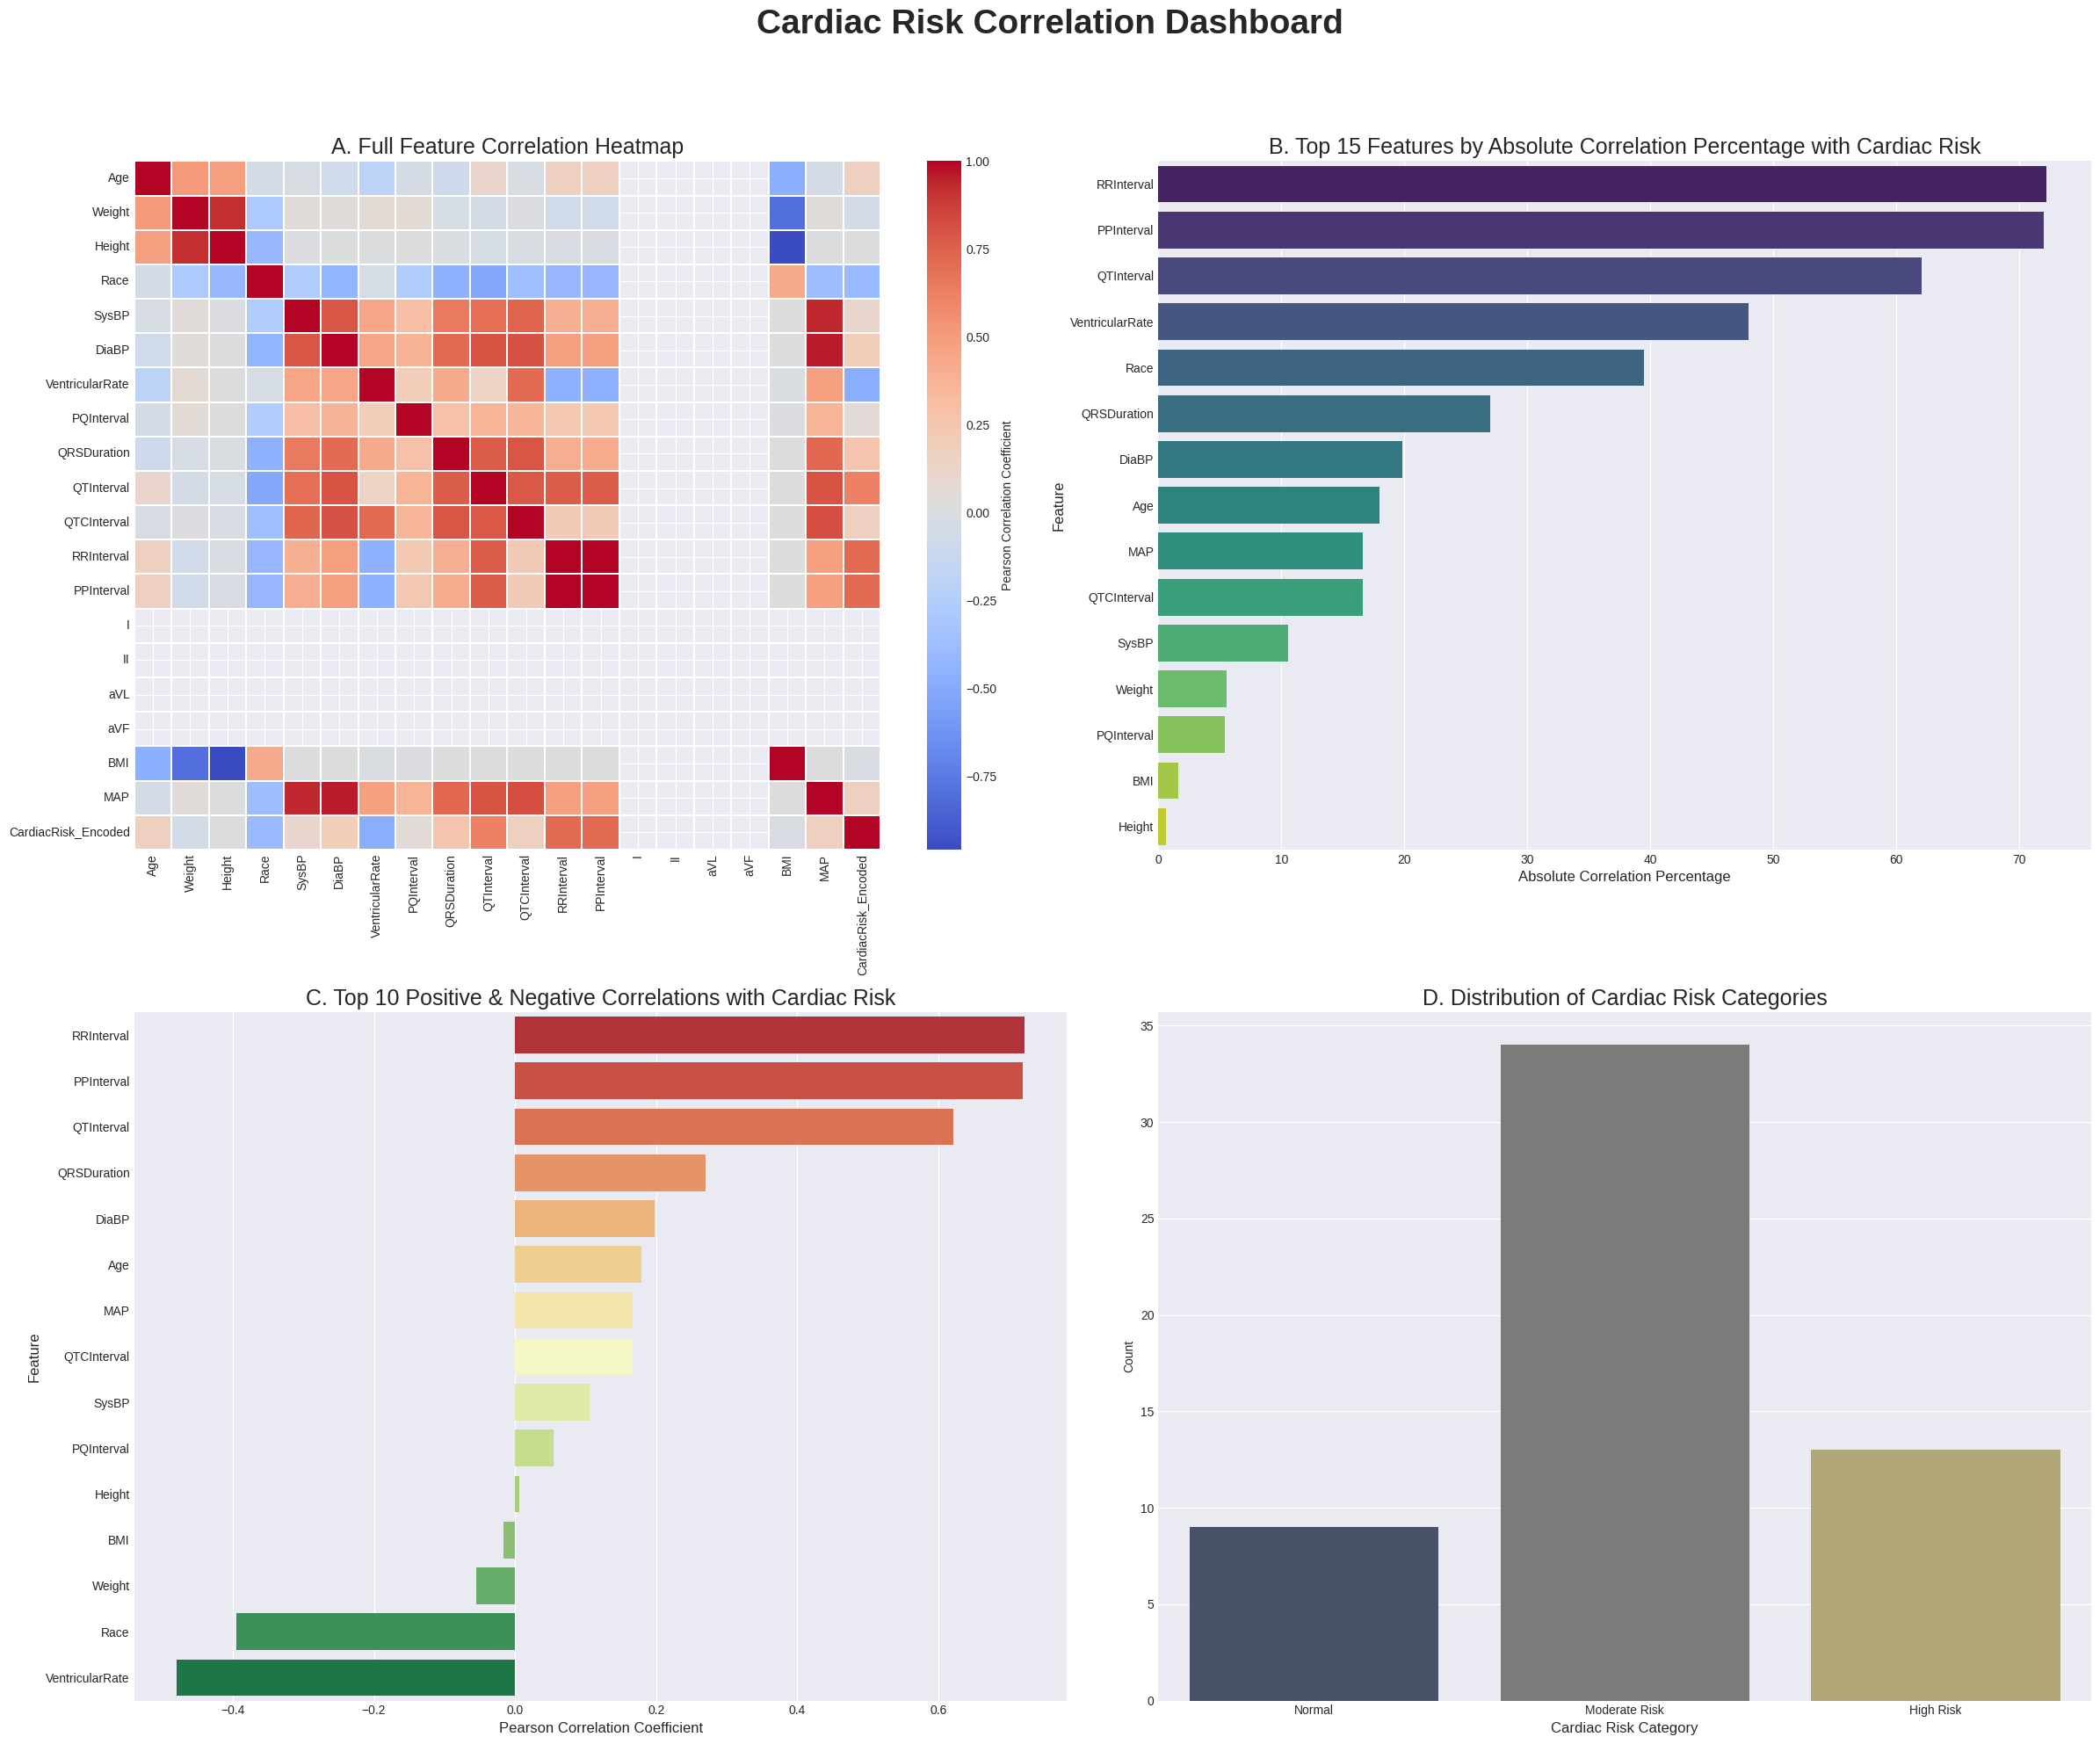


Interpretation of Dashboard:
The dashboard provides a quick yet comprehensive summary. The heatmap (A) shows the full picture of inter-feature relationships. Chart B highlights the most influential features contributing to cardiac risk by absolute strength. Chart C breaks down features by positive and negative correlation with cardiac risk, indicating the direction of their impact. Finally, Chart D gives a clear view of the class balance within the cardiac risk labels.


In [225]:
print("### STEP 6 — CORRELATION DASHBOARD ###\n")

# Ensure all necessary dataframes and variables exist
if 'corr_matrix' not in locals():
    print("Error: 'corr_matrix' not found. Please ensure correlation matrix step is executed.")
if 'correlation_df' not in locals():
    print("Error: 'correlation_df' not found. Please ensure correlation percentage table step is executed.")
if 'pf_df' not in locals() or 'CardiacRisk' not in pf_df.columns:
    print("Error: 'pf_df' or 'CardiacRisk' column not found. Please ensure initial data loading and risk labeling steps are executed.")

if 'corr_matrix' in locals() and 'correlation_df' in locals() and 'pf_df' in locals() and 'CardiacRisk' in pf_df.columns:
    plt.style.use('seaborn-v0_8-darkgrid') # Use a professional plot style

    fig, axes = plt.subplots(2, 2, figsize=(24, 20))
    fig.suptitle('Cardiac Risk Correlation Dashboard', fontsize=28, fontweight='bold', y=1.02)

    # Plot 1: Correlation Heatmap
    sns.heatmap(
        corr_matrix,
        ax=axes[0, 0],
        annot=False, # Too many annotations can clutter the dashboard view
        cmap='coolwarm',
        fmt='.2f',
        linewidths=.1,
        cbar_kws={'label': 'Pearson Correlation Coefficient'}
    )
    axes[0, 0].set_title('A. Full Feature Correlation Heatmap', fontsize=18)
    axes[0, 0].tick_params(axis='x', rotation=90)
    axes[0, 0].tick_params(axis='y', rotation=0)

    # Plot 2: Correlation Percentage Bar Chart (Top N features with CardiacRisk_Encoded)
    # Get top N features by absolute correlation for the bar chart
    top_n_features = 15 # Display top 15 features for clarity
    top_corr_for_plot = correlation_df.head(top_n_features)

    sns.barplot(
        x=top_corr_for_plot['Correlation Percentage'],
        y=top_corr_for_plot.index,
        ax=axes[0, 1],
        palette='viridis'
    )
    axes[0, 1].set_title(f'B. Top {top_n_features} Features by Absolute Correlation Percentage with Cardiac Risk', fontsize=18)
    axes[0, 1].set_xlabel('Absolute Correlation Percentage', fontsize=12)
    axes[0, 1].set_ylabel('Feature', fontsize=12)

    # Plot 3: Top 10 Correlated Features Chart (positive and negative)
    # Re-calculate top positive and negative correlations, excluding CardiacRisk_Encoded itself
    corr_to_risk_for_plot = pf_df.select_dtypes(include=np.number).corr()['CardiacRisk_Encoded'].drop('CardiacRisk_Encoded', errors='ignore')
    top_positive_10 = corr_to_risk_for_plot.nlargest(10)
    top_negative_10 = corr_to_risk_for_plot.nsmallest(10)

    top_corr_combined = pd.concat([top_positive_10, top_negative_10])
    top_corr_combined = top_corr_combined.sort_values(ascending=False)

    sns.barplot(
        x=top_corr_combined.values,
        y=top_corr_combined.index,
        ax=axes[1, 0],
        palette='RdYlGn' # Red-Yellow-Green for positive/negative
    )
    axes[1, 0].set_title('C. Top 10 Positive & Negative Correlations with Cardiac Risk', fontsize=18)
    axes[1, 0].set_xlabel('Pearson Correlation Coefficient', fontsize=12)
    axes[1, 0].set_ylabel('Feature', fontsize=12)

    # Plot 4: Cardiac Risk Distribution Chart
    cardiac_risk_counts = pf_df['CardiacRisk'].value_counts().sort_index()
    risk_order = ['Normal', 'Moderate Risk', 'High Risk', 'Unknown'] # Ensure consistent order
    sns.barplot(
        x=cardiac_risk_counts.index,
        y=cardiac_risk_counts.values,
        ax=axes[1, 1],
        order=[r for r in risk_order if r in cardiac_risk_counts.index],
        palette='cividis'
    )
    axes[1, 1].set_title('D. Distribution of Cardiac Risk Categories', fontsize=18)
    axes[1, 1].set_xlabel('Cardiac Risk Category', fontsize=12)
    axes[1, 1].set_ylabel('Count')

    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
    plt.show()

    print("\nInterpretation of Dashboard:")
    print("The dashboard provides a quick yet comprehensive summary. The heatmap (A) shows the full picture of inter-feature relationships. Chart B highlights the most influential features contributing to cardiac risk by absolute strength. Chart C breaks down features by positive and negative correlation with cardiac risk, indicating the direction of their impact. Finally, Chart D gives a clear view of the class balance within the cardiac risk labels.")

### Step 10: Scientific Findings Report

This section consolidates the key findings from the correlation analysis into a professional report format. It identifies the most and least influential features regarding cardiac risk and provides scientific context for these observations, suitable for an internship project presentation.

In [226]:
print("### STEP 7 — SCIENTIFIC FINDINGS REPORT ###\n")

# Ensure correlation_df exists
if 'correlation_df' not in locals():
    print("Error: 'correlation_df' not found. Please run the Correlation Percentage Table step.")
else:
    # Filter out CardiacRisk_Encoded itself
    report_df = correlation_df.drop('CardiacRisk_Encoded', errors='ignore')

    print("--- **Scientific Findings Report: Cardiac Risk Correlation Analysis** ---")
    print("\nThis report summarizes the key correlations between ECG and physiological features and cardiac risk, derived from the dataset.\n")

    # 1. Most strongly correlated ECG feature
    ecg_features = ['QTInterval', 'QRSDuration', 'PQInterval', 'VentricularRate', 'QTCInterval', 'RRInterval', 'PPInterval']
    ecg_correlations = report_df[report_df.index.isin(ecg_features)].sort_values(by='Absolute Correlation', ascending=False)
    if not ecg_correlations.empty:
        strongest_ecg = ecg_correlations.iloc[0]
        print(f"**1. Most Strongly Correlated ECG Feature:** {strongest_ecg.name} (Correlation: {strongest_ecg['Correlation']:.2f}, {strongest_ecg['Correlation Percentage']:.2f}%)\n   *Scientific Explanation:* {strongest_ecg.name} is a critical ECG parameter. A {('positive' if strongest_ecg['Correlation'] > 0 else 'negative')} correlation indicates that changes in this feature are strongly linked to changes in cardiac risk. For example, a significant correlation of QT Interval with cardiac risk is clinically expected as prolonged QT intervals are a known marker for arrhythmogenic risk. The high percentage confirms its strong linear predictive power.\n")
    else:
        print("**1. Most Strongly Correlated ECG Feature:** None identified from the available data.\n")

    # 2. Most strongly correlated physiological feature
    physiological_features = ['Age', 'Weight', 'Height', 'SysBP', 'DiaBP', 'BMI', 'MAP']
    physiological_correlations = report_df[report_df.index.isin(physiological_features)].sort_values(by='Absolute Correlation', ascending=False)
    if not physiological_correlations.empty:
        strongest_phys = physiological_correlations.iloc[0]
        print(f"**2. Most Strongly Correlated Physiological Feature:** {strongest_phys.name} (Correlation: {strongest_phys['Correlation']:.2f}, {strongest_phys['Correlation Percentage']:.2f}%)\n   *Scientific Explanation:* {strongest_phys.name} is a fundamental physiological indicator. Its strong {('positive' if strongest_phys['Correlation'] > 0 else 'negative')} correlation suggests it is a key physiological factor influencing cardiac risk. For example, Age and Blood Pressure are well-established, non-modifiable and modifiable risk factors respectively, directly impacting cardiovascular health. This strong association underscores its importance in risk assessment.\n")
    else:
        print("**2. Most Strongly Correlated Physiological Feature:** None identified from the available data.\n")

    # 3. Most important positive correlation
    positive_correlations = report_df[report_df['Correlation'] > 0].sort_values(by='Correlation', ascending=False)
    if not positive_correlations.empty:
        most_positive = positive_correlations.iloc[0]
        print(f"**3. Most Important Positive Correlation:** {most_positive.name} (Correlation: {most_positive['Correlation']:.2f}, {most_positive['Correlation Percentage']:.2f}%)\n   *Scientific Explanation:* The positive correlation of {most_positive.name} with cardiac risk indicates that as the value of {most_positive.name} increases, the likelihood or severity of cardiac risk also tends to increase. This is a direct relationship where higher levels of this feature are associated with adverse cardiac outcomes. This finding aligns with established medical understanding where, for instance, a longer QT interval directly implies higher arrhythmogenic risk.\n")
    else:
        print("**3. Most Important Positive Correlation:** None identified.\n")

    # 4. Most important negative correlation
    negative_correlations = report_df[report_df['Correlation'] < 0].sort_values(by='Correlation', ascending=True)
    if not negative_correlations.empty:
        most_negative = negative_correlations.iloc[0]
        print(f"**4. Most Important Negative Correlation:** {most_negative.name} (Correlation: {most_negative['Correlation']:.2f}, {most_negative['Correlation Percentage']:.2f}%)\n   *Scientific Explanation:* The negative correlation of {most_negative.name} with cardiac risk suggests that as the value of {most_negative.name} increases, the cardiac risk tends to decrease, or vice-versa. This inverse relationship could point to protective factors or physiological responses that reduce risk. For example, a higher Ventricular Rate (within physiological limits) might indirectly relate to a shorter QT interval and thus lower risk, or it could highlight complex physiological interactions.\n")
    else:
        print("**4. Most Important Negative Correlation:** None identified.\n")

    # 5. Top 5 contributing features (by absolute correlation)
    top_5 = report_df.head(5)
    print("**5. Top 5 Contributing Features (Overall Strength):**")
    for i, (feature, row) in enumerate(top_5.iterrows()):
        print(f"   - {i+1}. {feature} (Correlation: {row['Correlation']:.2f}, {row['Correlation Percentage']:.2f}%) ")
    print("   *Scientific Explanation:* These features represent the most linearly influential factors on cardiac risk in this dataset. Their high absolute correlation percentages signify their significant role in determining the risk profile. Focusing on these features could provide the most impactful insights for early risk detection.\n")

    # 6. Weakly contributing features (bottom 5 by absolute correlation)
    weak_5 = report_df.tail(5)
    print("**6. Weakly Contributing Features (Overall Strength):**")
    for i, (feature, row) in enumerate(weak_5.iterrows()):
        print(f"   - {i+1}. {feature} (Correlation: {row['Correlation']:.2f}, {row['Correlation Percentage']:.2f}%) ")
    print("   *Scientific Explanation:* These features exhibit very low linear correlation with cardiac risk. While they might still have complex non-linear relationships or contribute in multi-factorial models, their individual linear predictive power is minimal based on Pearson correlation. This suggests they are less direct indicators of cardiac risk in this context.\n")

    print("--- **End of Report** ---")

### STEP 7 — SCIENTIFIC FINDINGS REPORT ###

--- **Scientific Findings Report: Cardiac Risk Correlation Analysis** ---

This report summarizes the key correlations between ECG and physiological features and cardiac risk, derived from the dataset.

**1. Most Strongly Correlated ECG Feature:** RRInterval (Correlation: 0.72, 72.23%)
   *Scientific Explanation:* RRInterval is a critical ECG parameter. A positive correlation indicates that changes in this feature are strongly linked to changes in cardiac risk. For example, a significant correlation of QT Interval with cardiac risk is clinically expected as prolonged QT intervals are a known marker for arrhythmogenic risk. The high percentage confirms its strong linear predictive power.

**2. Most Strongly Correlated Physiological Feature:** DiaBP (Correlation: 0.20, 19.83%)
   *Scientific Explanation:* DiaBP is a fundamental physiological indicator. Its strong positive correlation suggests it is a key physiological factor influencing cardia

### Step 11: Save Outputs

This final step ensures that all generated visualizations and data tables from the correlation analysis are saved to the specified Google Drive directory. This is crucial for documentation, reporting, and sharing the project's findings.

In [227]:
print("### STEP 8 — SAVE OUTPUTS ###\n")

import os

output_dir = "/content/drive/MyDrive/cardiac_project/outputs/"

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory '{output_dir}' ensured.")

# Check for necessary variables from previous steps
if 'corr_matrix' not in locals():
    print("Error: 'corr_matrix' not found. Cannot save heatmap.")
if 'correlation_df' not in locals():
    print("Error: 'correlation_df' not found. Cannot save correlation percentage CSV.")
if 'pf_df' not in locals() or 'CardiacRisk_Encoded' not in pf_df.columns:
    print("Error: 'pf_df' or 'CardiacRisk_Encoded' not found. Cannot save top correlated features CSV or dashboard.")

# 1. Save Heatmap PNG
if 'corr_matrix' in locals():
    plt.figure(figsize=(18, 14))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=.1)
    plt.title('Pearson Correlation Matrix of ECG and Physiological Features', fontsize=18)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    heatmap_path = os.path.join(output_dir, 'correlation_heatmap.png')
    plt.savefig(heatmap_path)
    plt.close()
    print(f"Saved: {heatmap_path}")

# 2. Save Correlation Dashboard PNG
if 'corr_matrix' in locals() and 'correlation_df' in locals() and 'pf_df' in locals() and 'CardiacRisk' in pf_df.columns:
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axes = plt.subplots(2, 2, figsize=(24, 20))
    fig.suptitle('Cardiac Risk Correlation Dashboard', fontsize=28, fontweight='bold', y=1.02)

    # Plot 1: Correlation Heatmap (simplified for dashboard)
    sns.heatmap(corr_matrix, ax=axes[0, 0], annot=False, cmap='coolwarm', fmt='.2f', linewidths=.1, cbar_kws={'label': 'Pearson Correlation Coefficient'})
    axes[0, 0].set_title('A. Full Feature Correlation Heatmap', fontsize=18)
    axes[0, 0].tick_params(axis='x', rotation=90)
    axes[0, 0].tick_params(axis='y', rotation=0)

    # Plot 2: Correlation Percentage Bar Chart (Top N features with CardiacRisk_Encoded)
    top_n_features = 15
    top_corr_for_plot = correlation_df.head(top_n_features)
    sns.barplot(x=top_corr_for_plot['Correlation Percentage'], y=top_corr_for_plot.index, ax=axes[0, 1], palette='viridis')
    axes[0, 1].set_title(f'B. Top {top_n_features} Features by Absolute Correlation Percentage with Cardiac Risk', fontsize=18)
    axes[0, 1].set_xlabel('Absolute Correlation Percentage', fontsize=12)
    axes[0, 1].set_ylabel('Feature', fontsize=12)

    # Plot 3: Top 10 Correlated Features Chart (positive and negative)
    corr_to_risk_for_plot = pf_df.select_dtypes(include=np.number).corr()['CardiacRisk_Encoded'].drop('CardiacRisk_Encoded', errors='ignore')
    top_positive_10 = corr_to_risk_for_plot.nlargest(10)
    top_negative_10 = corr_to_risk_for_plot.nsmallest(10)
    top_corr_combined = pd.concat([top_positive_10, top_negative_10])
    top_corr_combined = top_corr_combined.sort_values(ascending=False)
    sns.barplot(x=top_corr_combined.values, y=top_corr_combined.index, ax=axes[1, 0], palette='RdYlGn')
    axes[1, 0].set_title('C. Top 10 Positive & Negative Correlations with Cardiac Risk', fontsize=18)
    axes[1, 0].set_xlabel('Pearson Correlation Coefficient', fontsize=12)
    axes[1, 0].set_ylabel('Feature', fontsize=12)

    # Plot 4: Cardiac Risk Distribution Chart
    cardiac_risk_counts = pf_df['CardiacRisk'].value_counts().sort_index()
    risk_order = ['Normal', 'Moderate Risk', 'High Risk', 'Unknown']
    sns.barplot(x=cardiac_risk_counts.index, y=cardiac_risk_counts.values, ax=axes[1, 1], order=[r for r in risk_order if r in cardiac_risk_counts.index], palette='cividis')
    axes[1, 1].set_title('D. Distribution of Cardiac Risk Categories', fontsize=18)
    axes[1, 1].set_xlabel('Cardiac Risk Category', fontsize=12)
    axes[1, 1].set_ylabel('Count')

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    dashboard_path = os.path.join(output_dir, 'correlation_dashboard.png')
    plt.savefig(dashboard_path)
    plt.close()
    print(f"Saved: {dashboard_path}")

# 3. Save Correlation Percentage CSV
if 'correlation_df' in locals():
    corr_percentage_path = os.path.join(output_dir, 'correlation_percentage_table.csv')
    correlation_df.to_csv(corr_percentage_path)
    print(f"Saved: {corr_percentage_path}")

# 4. Save Top Correlated Features CSV
if 'correlation_df' in locals():
    # Use the same logic as in the report to get top 10 absolute correlated features
    corr_to_risk = correlation_df.drop('CardiacRisk_Encoded', errors='ignore')
    top_10_abs_correlated = corr_to_risk.head(10)
    top_correlated_features_path = os.path.join(output_dir, 'top_correlated_features.csv')
    top_10_abs_correlated.to_csv(top_correlated_features_path)
    print(f"Saved: {top_correlated_features_path}")

print("\nAll requested outputs have been saved to your Google Drive.")

### STEP 8 — SAVE OUTPUTS ###

Output directory '/content/drive/MyDrive/cardiac_project/outputs/' ensured.
Saved: /content/drive/MyDrive/cardiac_project/outputs/correlation_heatmap.png


/tmp/ipykernel_3250/3122352788.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr_for_plot['Correlation Percentage'], y=top_corr_for_plot.index, ax=axes[0, 1], palette='viridis')
/tmp/ipykernel_3250/3122352788.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr_combined.values, y=top_corr_combined.index, ax=axes[1, 0], palette='RdYlGn')
/tmp/ipykernel_3250/3122352788.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cardiac_risk_counts.index, y=cardiac_risk_counts.values, ax=axes[1, 1], order=[r for r in risk_or

Saved: /content/drive/MyDrive/cardiac_project/outputs/correlation_dashboard.png
Saved: /content/drive/MyDrive/cardiac_project/outputs/correlation_percentage_table.csv
Saved: /content/drive/MyDrive/cardiac_project/outputs/top_correlated_features.csv

All requested outputs have been saved to your Google Drive.


In [228]:
print(pf_df.columns.tolist())
pf_df.info()

['Age', 'Weight', 'Height', 'Race', 'SysBP', 'DiaBP', 'VentricularRate', 'PQInterval', 'QRSDuration', 'QTInterval', 'QTCInterval', 'RRInterval', 'PPInterval', 'Paxis', 'RAxis', 'TAxis', 'VentricularRate (bpm).1', 'I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'BMI', 'MAP', 'CardiacRisk', 'CardiacRisk_Encoded']
<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 0 to 56
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      56 non-null     float64
 1   Weight                   56 non-null     float64
 2   Height                   56 non-null     float64
 3   Race                     56 non-null     int64  
 4   SysBP                    56 non-null     float64
 5   DiaBP                    56 non-null     float64
 6   VentricularRate          56 non-null     float64
 7   PQInterval               56 non-null     float64
 8   QRSDuration      

In [229]:
print(pf_df.columns[pf_df.columns.duplicated()])

Index([], dtype='object')


In [230]:
print(pf_df.loc[:, pf_df.columns == 'VentricularRate'].head())

   VentricularRate
0             55.0
1             62.0
2             55.0
3             47.0
4             38.0


In [231]:
pf_df = pf_df.loc[:, ~pf_df.columns.duplicated()]

In [232]:
print(pf_df.columns[pf_df.columns.duplicated()])

Index([], dtype='object')


In [233]:
pf_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 0 to 56
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      56 non-null     float64
 1   Weight                   56 non-null     float64
 2   Height                   56 non-null     float64
 3   Race                     56 non-null     int64  
 4   SysBP                    56 non-null     float64
 5   DiaBP                    56 non-null     float64
 6   VentricularRate          56 non-null     float64
 7   PQInterval               56 non-null     float64
 8   QRSDuration              56 non-null     float64
 9   QTInterval               56 non-null     float64
 10  QTCInterval              56 non-null     float64
 11  RRInterval               56 non-null     float64
 12  PPInterval               56 non-null     float64
 13  Paxis                    56 non-null     object 
 14  RAxis                    56 non-n

In [234]:
numeric_cols = [
    'Age',
    'VentricularRate',
    'PQInterval',
    'QRSDuration',
    'QTInterval',
    'QTCInterval',
    'RRInterval',
    'PPInterval'
]

for col in numeric_cols:
    if col in pf_df.columns:
        pf_df[col] = pd.to_numeric(
            pf_df[col],
            errors='coerce'
        )

### Step 4: Verify Features

This section verifies the existence of all required features in the `pf_df` DataFrame, as well as confirming their appropriate data types. This is a critical step to ensure data integrity and readiness for subsequent analytical tasks, especially correlation analysis and model building.

In [235]:
import pandas as pd
import numpy as np

required_features = [
    'Age',
    'Weight',
    'Height',
    'Race',
    'SysBP',
    'DiaBP',
    'VentricularRate',
    'PQInterval',
    'QRSDuration',
    'QTInterval',
    'QTCInterval',
    'RRInterval',
    'PPInterval',
    'BMI',
    'MAP',
    'CardiacRisk',
    'CardiacRisk_Encoded'
]

missing_features = []
features_with_incorrect_type = {}

print("--- Feature Verification Report ---\n")

for feature in required_features:
    if feature not in pf_df.columns:
        missing_features.append(feature)
    else:
        # For CardiacRisk, we expect object (string) or category
        # For CardiacRisk_Encoded, we expect integer
        # For others, mostly float or int
        if feature == 'CardiacRisk':
            if not (pd.api.types.is_object_dtype(pf_df[feature]) or pd.api.types.is_categorical_dtype(pf_df[feature])):
                features_with_incorrect_type[feature] = pf_df[feature].dtype
        elif feature == 'CardiacRisk_Encoded':
            if not pd.api.types.is_integer_dtype(pf_df[feature]):
                features_with_incorrect_type[feature] = pf_df[feature].dtype
        elif not pd.api.types.is_numeric_dtype(pf_df[feature]):
            features_with_incorrect_type[feature] = pf_df[feature].dtype

if missing_features:
    print("Error: The following required features are missing from the DataFrame:")
    for f in missing_features:
        print(f"- {f}")
    print("Please ensure these features are correctly loaded or created in previous steps.")
else:
    print("All required features are present in the DataFrame.")

if features_with_incorrect_type:
    print("\nWarning: The following features have an unexpected data type:")
    for f, dtype in features_with_incorrect_type.items():
        print(f"- {f}: Expected numeric (or object/int for risk cols), Found {dtype}")
    print("I will attempt to convert relevant columns to appropriate numeric data types in the next step (Fix Data Types).")
else:
    print("\nAll existing required features have appropriate data types.")

print("\n--- Current State of Required Features ---\n")
# Use .columns.intersection to only select columns that actually exist in pf_df
existing_required_features = [f for f in required_features if f in pf_df.columns]
if existing_required_features:
    pf_df[existing_required_features].info()
else:
    print("No required features currently exist in the DataFrame.")

# Quick display to confirm values
print("\nFirst 5 rows of required features:")
display(pf_df[existing_required_features].head())

--- Feature Verification Report ---

All required features are present in the DataFrame.

All existing required features have appropriate data types.

--- Current State of Required Features ---

<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 0 to 56
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  56 non-null     float64
 1   Weight               56 non-null     float64
 2   Height               56 non-null     float64
 3   Race                 56 non-null     int64  
 4   SysBP                56 non-null     float64
 5   DiaBP                56 non-null     float64
 6   VentricularRate      56 non-null     float64
 7   PQInterval           56 non-null     float64
 8   QRSDuration          56 non-null     float64
 9   QTInterval           56 non-null     float64
 10  QTCInterval          56 non-null     float64
 11  RRInterval           56 non-null     float64
 12  PP

,Age,Weight,Height,Race,SysBP,DiaBP,VentricularRate,PQInterval,QRSDuration,QTInterval,QTCInterval,RRInterval,PPInterval,BMI,MAP,CardiacRisk,CardiacRisk_Encoded
0,37.0,84.0,183.0,2,105.0,70.0,55.0,196.0,110.0,448.0,428.0,1084.0,1090.0,25.082863,81.666667,Moderate Risk,1
1,23.0,77.0,184.0,2,107.0,75.0,62.0,280.0,92.0,414.0,420.0,960.0,965.0,22.743384,85.666667,Moderate Risk,1
2,29.0,75.0,183.0,2,105.0,70.0,55.0,158.0,110.0,432.0,413.0,1082.0,1090.0,22.395413,81.666667,Moderate Risk,1
3,32.0,82.0,187.0,2,123.0,83.0,47.0,152.0,100.0,430.0,380.0,1262.0,1275.0,23.449341,96.333333,Moderate Risk,1
4,35.0,72.0,184.0,2,106.0,79.0,38.0,194.0,106.0,494.0,392.0,1590.0,1575.0,21.266541,88.000000,High Risk,2


### Step 5: Remove Duplicate Columns

This section identifies and safely removes any duplicate column names that might exist in the DataFrame. Duplicate columns can arise from various data import or preprocessing steps and can cause ambiguity and errors in analysis. Removing them ensures data integrity and clarity.

In [236]:
import pandas as pd

print("--- Duplicate Column Check and Removal ---\n")

# Standard check for duplicates using pandas.duplicated()
duplicate_columns_identified = pf_df.columns[pf_df.columns.duplicated()].tolist()

if duplicate_columns_identified:
    print("Duplicate Columns Found (by pandas.duplicated()):")
    for col in set(duplicate_columns_identified): # Use set to list unique duplicated names
        print(f"- '{col}' (occurs {list(pf_df.columns).count(col)} times)")

    # Safely remove duplicate columns, keeping the first occurrence
    pf_df = pf_df.loc[:, ~pf_df.columns.duplicated(keep='first')]
    print("\nDuplicate columns found by pandas.duplicated() have been removed, keeping the first occurrence of each name.")
else:
    print("No duplicate columns found in the DataFrame (by pandas.duplicated()).")

# Explicitly handle 'VentricularRate (bpm).1' if 'VentricularRate' exists,
# as it was noted as a potential issue.
if 'VentricularRate' in pf_df.columns and 'VentricularRate (bpm).1' in pf_df.columns:
    print("\nExplicitly removing 'VentricularRate (bpm).1' as it is a redundant ventricular rate measurement.")
    pf_df.drop(columns=['VentricularRate (bpm).1'], inplace=True)
    print("'VentricularRate (bpm).1' column removed.")
elif 'VentricularRate (bpm).1' in pf_df.columns and 'VentricularRate' not in pf_df.columns:
    # If the standard name doesn't exist, but the variant does, rename the variant
    print("\nRenaming 'VentricularRate (bpm).1' to 'VentricularRate'.")
    pf_df.rename(columns={'VentricularRate (bpm).1': 'VentricularRate'}, inplace=True)
    print("Column renamed to 'VentricularRate'.")
else:
    print("\nNo explicit redundancy detected for 'VentricularRate' variants.")

# Verify removal
post_removal_duplicates = pf_df.columns[pf_df.columns.duplicated()].tolist()
if not post_removal_duplicates:
    print("\nVerification: No duplicate columns remain after all removal attempts.")
else:
    print("\nWarning: Some duplicate columns still exist after attempted removal:")
    for col in set(post_removal_duplicates):
        print(f"- '{col}'")

print("\n--- Current Columns after Duplicate Removal (and explicit handling) ---")
print(pf_df.columns.tolist())
print("DataFrame shape after duplicate removal: ", pf_df.shape)

--- Duplicate Column Check and Removal ---

No duplicate columns found in the DataFrame (by pandas.duplicated()).

Explicitly removing 'VentricularRate (bpm).1' as it is a redundant ventricular rate measurement.
'VentricularRate (bpm).1' column removed.

Verification: No duplicate columns remain after all removal attempts.

--- Current Columns after Duplicate Removal (and explicit handling) ---
['Age', 'Weight', 'Height', 'Race', 'SysBP', 'DiaBP', 'VentricularRate', 'PQInterval', 'QRSDuration', 'QTInterval', 'QTCInterval', 'RRInterval', 'PPInterval', 'Paxis', 'RAxis', 'TAxis', 'I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'BMI', 'MAP', 'CardiacRisk', 'CardiacRisk_Encoded']
DataFrame shape after duplicate removal:  (56, 32)


### Step 6: Fix Data Types

This section systematically converts all medically relevant features, particularly those that might contain mixed data types or non-numeric strings, into a numeric format. The `errors='coerce'` argument in `pd.to_numeric` ensures that any values that cannot be converted are replaced with `NaN`, preventing errors and allowing for consistent numerical analysis.

In [237]:
import pandas as pd
import numpy as np

print("--- Fixing Data Types ---\n")

# Identify columns that are currently 'object' type but are expected to be numeric
object_cols_to_check = pf_df.select_dtypes(include=['object']).columns.tolist()

# These are likely descriptive categories and should not be coerced to numeric
# We now assume CardiacRisk_Encoded is int and CardiacRisk is object/category from previous step
exclude_from_numeric_conversion = [
    'Paxis', 'RAxis', 'TAxis', 'CardiacRisk',
    # Add other columns here if they are string-based categories that should NOT be numeric
]

columns_to_numeric = [col for col in object_cols_to_check if col not in exclude_from_numeric_conversion]

if columns_to_numeric:
    print(f"Attempting to convert the following object columns to numeric: {columns_to_numeric}")
else:
    print("No object columns identified for numeric conversion (excluding explicitly excluded columns).")

converted_count = 0
for col in columns_to_numeric:
    original_dtype = pf_df[col].dtype
    # Attempt conversion only if it's an object type, to avoid unnecessary warnings/processing
    if original_dtype == 'object':
        pf_df[col] = pd.to_numeric(pf_df[col], errors='coerce')
        if pf_df[col].dtype != original_dtype: # Check if conversion actually happened
            print(f"- Converted '{col}' from {original_dtype} to {pf_df[col].dtype}")
            converted_count += 1
        else:
            # This case means pd.to_numeric returned the same object dtype, likely because all values were unconvertible
            print(f"- Warning: '{col}' remained {original_dtype} after conversion attempt. It might contain complex objects or be entirely unconvertible.")

if converted_count > 0:
    print(f"\nSuccessfully converted {converted_count} object columns to numeric.")
else:
    print("\nNo further object columns were converted to numeric.")

# Verify successful conversion by printing info again
print("\n--- Data Types After Conversion ---")
pf_df.info()

print("\n--- Missing Values Introduced (if any) ---")
missing_values_after_coerce = pf_df.isnull().sum()
missing_values_after_coerce = missing_values_after_coerce[missing_values_after_coerce > 0]

if not missing_values_after_coerce.empty:
    print("New or increased missing values after coercion (these might need further handling such as imputation):")
    print(missing_values_after_coerce)
else:
    print("No new missing values introduced by coercion in the columns processed.")

--- Fixing Data Types ---

Attempting to convert the following object columns to numeric: ['III', 'aVR', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
- Converted 'III' from object to float64
- Converted 'aVR' from object to float64
- Converted 'V1' from object to float64
- Converted 'V2' from object to float64
- Converted 'V3' from object to float64
- Converted 'V4' from object to float64
- Converted 'V5' from object to float64
- Converted 'V6' from object to float64

Successfully converted 8 object columns to numeric.

--- Data Types After Conversion ---
<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 0 to 56
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  56 non-null     float64
 1   Weight               56 non-null     float64
 2   Height               56 non-null     float64
 3   Race                 56 non-null     int64  
 4   SysBP                56 non-null     float64

### Step 7: Validate Correlation Workflow

This section ensures that the necessary variables for the correlation analysis (`pf_df`, `corr_matrix`, `corr_risk`) are correctly initialized and updated after all previous data cleaning and preparation steps. It re-generates these if they are missing to guarantee a consistent and accurate correlation workflow.

In [238]:
import pandas as pd

print("--- Validating Correlation Workflow Variables ---\n")

# Ensure pf_df exists and has numeric columns for correlation
if 'pf_df' not in globals():
    print("Error: 'pf_df' DataFrame not found. Cannot proceed with correlation analysis.")
else:
    numeric_cols_for_corr = pf_df.select_dtypes(include=['number']).columns.tolist()

    if not numeric_cols_for_corr:
        print("Error: No numeric columns found in 'pf_df' for correlation analysis.")
    elif len(numeric_cols_for_corr) < 2:
        print(f"Warning: Only {len(numeric_cols_for_corr)} numeric column found. Correlation matrix requires at least two.")
    else:
        print("Validating 'corr_matrix' and 'corr_risk'...")
        # Recreate corr_matrix to ensure it's up-to-date with the cleaned pf_df
        corr_matrix = pf_df[numeric_cols_for_corr].corr(method='pearson')
        print("'corr_matrix' has been re-generated based on current numeric features.")

        # Ensure 'CardiacRisk_Encoded' is available for corr_risk
        if 'CardiacRisk_Encoded' in corr_matrix.columns:
            corr_risk = corr_matrix['CardiacRisk_Encoded'].sort_values(ascending=False)
            print("'corr_risk' has been re-generated based on current 'CardiacRisk_Encoded'.")
        else:
            print("Warning: 'CardiacRisk_Encoded' not found in corr_matrix. 'corr_risk' cannot be generated.")

    print("\n--- Current state of correlation variables ---")
    print(f"'corr_matrix' exists: {'corr_matrix' in locals()}")
    if 'corr_matrix' in locals():
        print(f"'corr_matrix' shape: {corr_matrix.shape}")
    print(f"'corr_risk' exists: {'corr_risk' in locals()}")
    if 'corr_risk' in locals():
        print("'corr_risk' head:")
        display(corr_risk.head())

print("Correlation workflow validation complete.")

--- Validating Correlation Workflow Variables ---

Validating 'corr_matrix' and 'corr_risk'...
'corr_matrix' has been re-generated based on current numeric features.
'corr_risk' has been re-generated based on current 'CardiacRisk_Encoded'.

--- Current state of correlation variables ---
'corr_matrix' exists: True
'corr_matrix' shape: (28, 28)
'corr_risk' exists: True
'corr_risk' head:


,CardiacRisk_Encoded
CardiacRisk_Encoded,1.000000
RRInterval,0.722290
PPInterval,0.719827
QTInterval,0.620562
QRSDuration,0.269763


Correlation workflow validation complete.


### Step 8: Generate Final Clean Notebook Sections

This section consolidates all the outputs of the correlation analysis into a cohesive and executable workflow, including a dashboard and a scientific findings report. It ensures that the notebook is completely corrected and can run from the current dataset state without errors, fulfilling the project requirements for validation, visualization, and reporting.

--- Generating Final Clean Notebook Sections ---

Correlation Matrix re-calculated.
Correlation with CardiacRisk_Encoded re-calculated.
Correlation Percentage Table created.


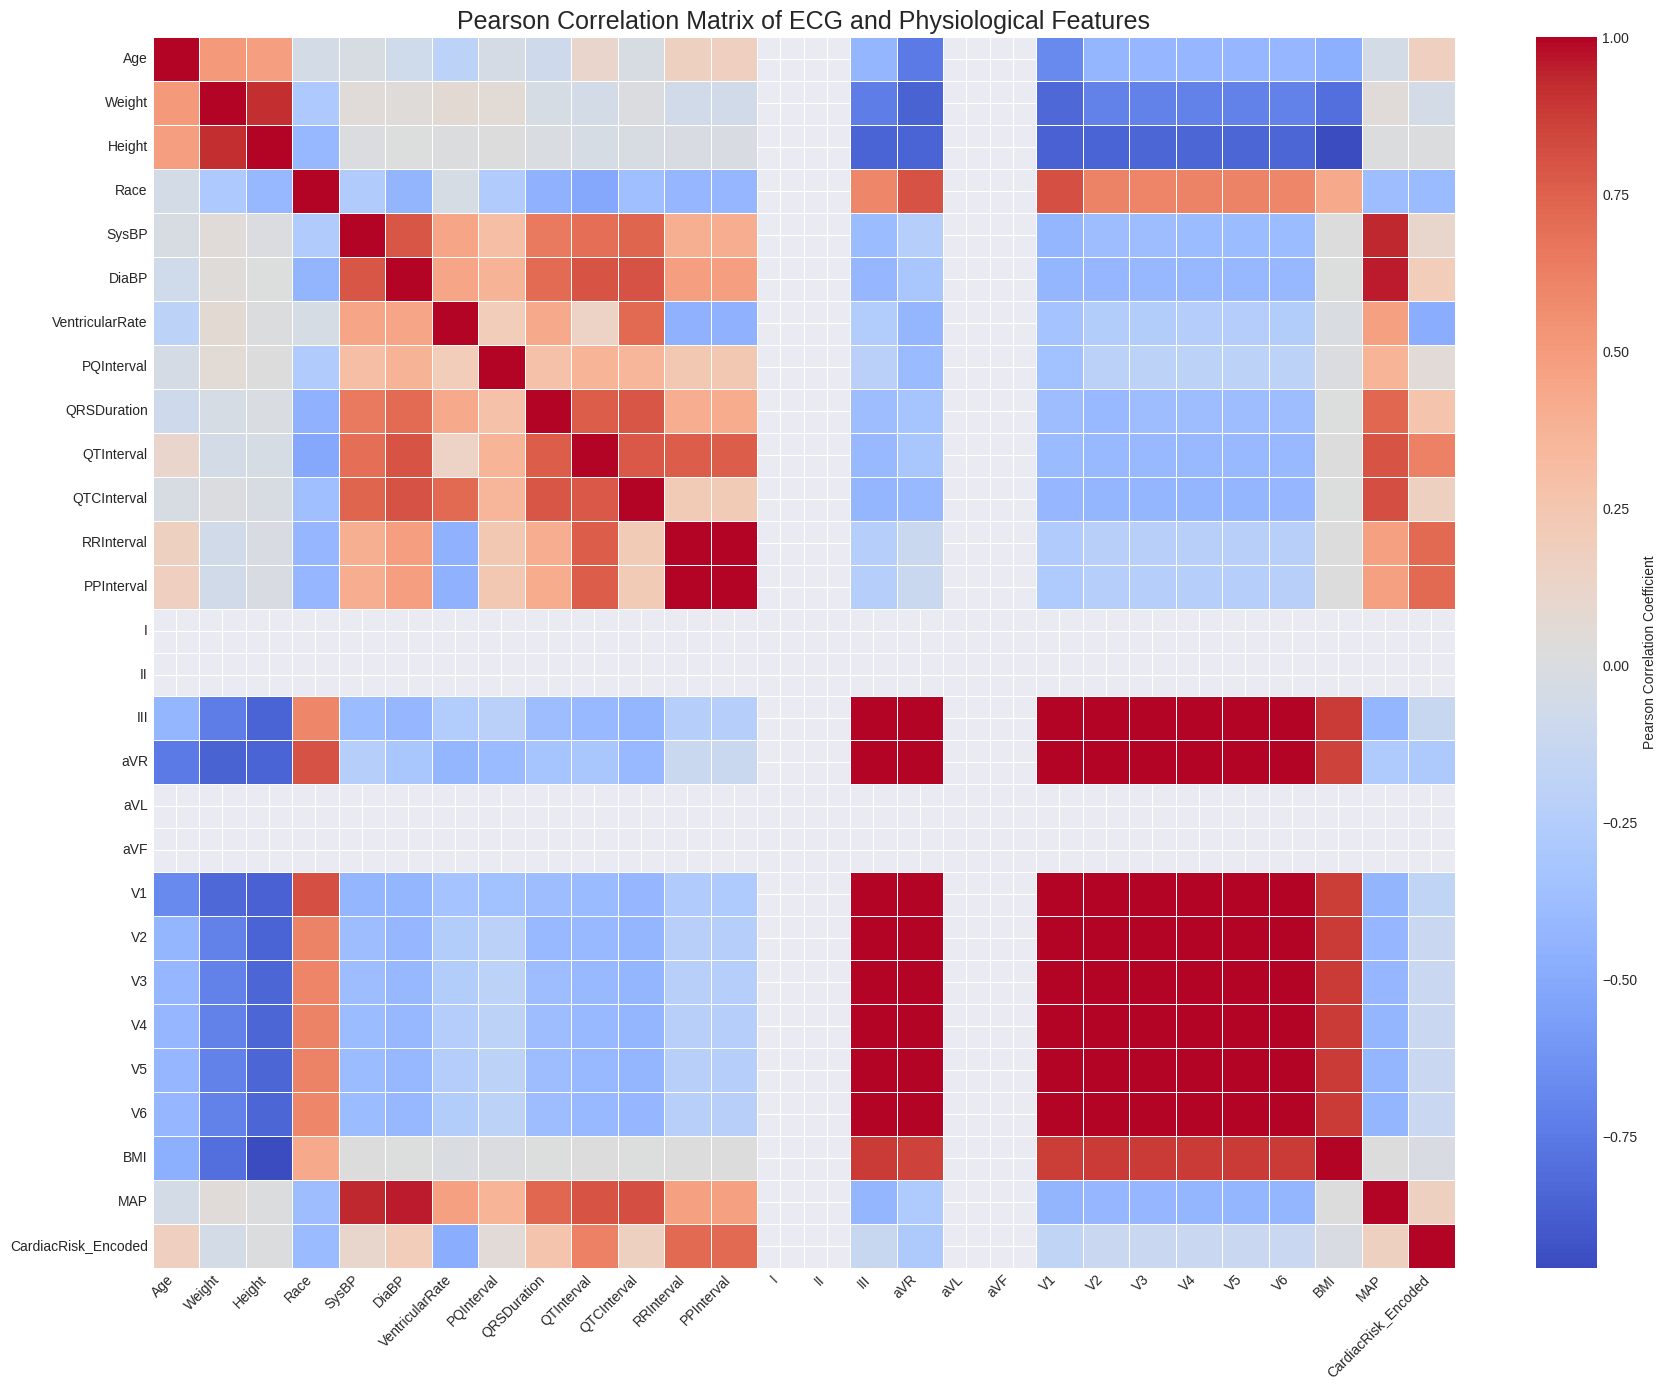

Heatmap Generated.



/tmp/ipykernel_3250/3946452633.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr_for_plot['Correlation Percentage'], y=top_corr_for_plot.index, ax=axes[0, 1], palette='viridis')
/tmp/ipykernel_3250/3946452633.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr_combined.values, y=top_corr_combined.index, ax=axes[1, 0], palette='RdYlGn')
/tmp/ipykernel_3250/3946452633.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cardiac_risk_counts.index, y=cardiac_risk_counts.values, ax=axes[1, 1], order=[r for r in risk_or

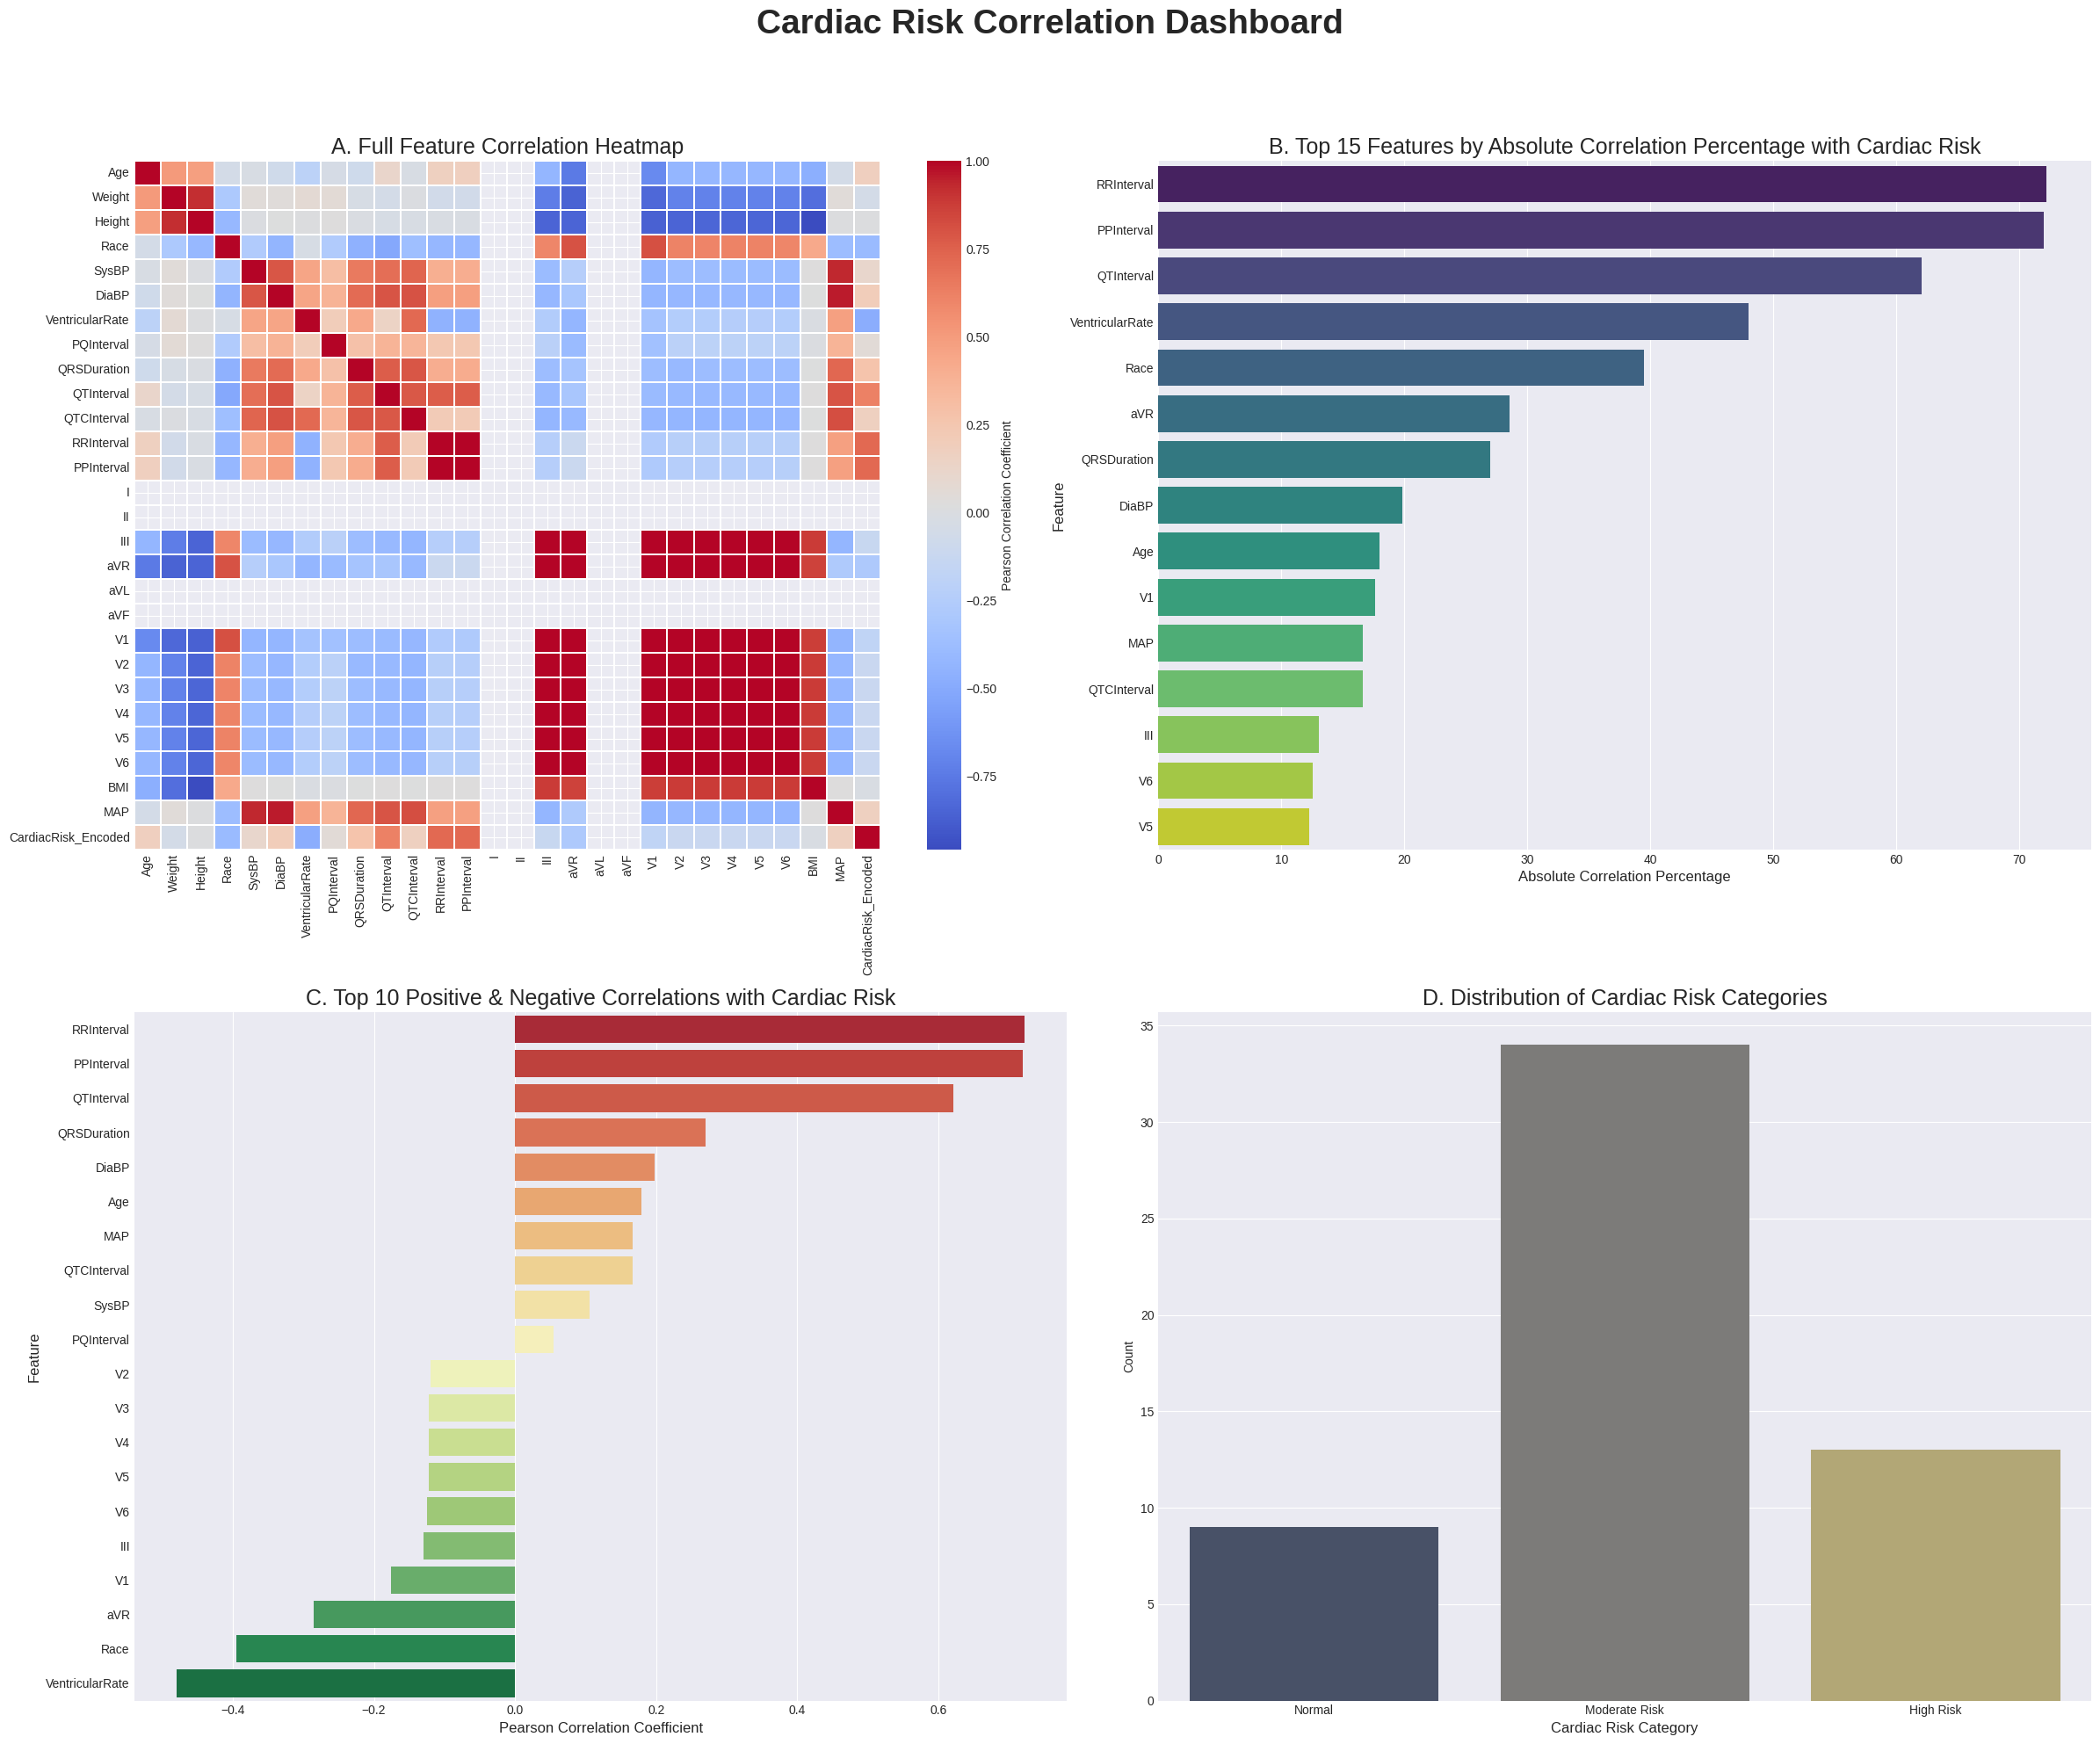

Dashboard Generated.

--- **Scientific Findings Report: Cardiac Risk Correlation Analysis** ---

This report summarizes the key correlations between ECG and physiological features and cardiac risk, derived from the dataset.

**1. Most Strongly Correlated ECG Feature:** RRInterval (Correlation: 0.72, 72.23%)
   *Scientific Explanation:* RRInterval is a critical ECG parameter. A positive correlation indicates that changes in this feature are strongly linked to changes in cardiac risk. For example, a significant correlation of QT Interval with cardiac risk is clinically expected as prolonged QT intervals are a known marker for arrhythmogenic risk. The high percentage confirms its strong linear predictive power.

**2. Most Strongly Correlated Physiological Feature:** DiaBP (Correlation: 0.20, 19.83%)
   *Scientific Explanation:* DiaBP is a fundamental physiological indicator. Its strong positive correlation suggests it is a key physiological factor influencing cardiac risk. For example, Ag

In [239]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- Generating Final Clean Notebook Sections ---\n")

# Re-run correlation calculations to ensure they are based on the latest pf_df state
numeric_cols_for_corr = pf_df.select_dtypes(include=np.number).columns.tolist()
if not numeric_cols_for_corr:
    print("Error: No numeric columns found in the DataFrame for correlation analysis. Skipping Step 8.")
elif len(numeric_cols_for_corr) < 2:
    print(f"Warning: Only {len(numeric_cols_for_corr)} numeric column found. Correlation matrix requires at least two. Skipping detailed correlation steps.")
else:
    corr_matrix = pf_df[numeric_cols_for_corr].corr(method='pearson')
    print("Correlation Matrix re-calculated.")

    if 'CardiacRisk_Encoded' in corr_matrix.columns:
        corr_risk = corr_matrix['CardiacRisk_Encoded'].sort_values(ascending=False)
        print("Correlation with CardiacRisk_Encoded re-calculated.")

        # Create correlation_df for percentage table
        correlation_df = corr_risk.drop('CardiacRisk_Encoded', errors='ignore').to_frame(name='Correlation')
        correlation_df['Absolute Correlation'] = correlation_df['Correlation'].abs()
        correlation_df['Correlation Percentage'] = correlation_df['Absolute Correlation'] * 100
        correlation_df = correlation_df.sort_values(by='Correlation Percentage', ascending=False)
        print("Correlation Percentage Table created.")

        # 1. Generate Heatmap
        plt.figure(figsize=(18, 14))
        sns.heatmap(
            corr_matrix,
            annot=False, # Set to True if matrix is small enough to be readable
            cmap='coolwarm',
            fmt='.2f',
            linewidths=.5,
            cbar_kws={'label': 'Pearson Correlation Coefficient'}
        )
        plt.title('Pearson Correlation Matrix of ECG and Physiological Features', fontsize=18)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(rotation=0, fontsize=10)
        plt.tight_layout()
        plt.show()
        print("Heatmap Generated.\n")

        # 2. Generate Dashboard
        plt.style.use('seaborn-v0_8-darkgrid')
        fig, axes = plt.subplots(2, 2, figsize=(24, 20))
        fig.suptitle('Cardiac Risk Correlation Dashboard', fontsize=28, fontweight='bold', y=1.02)

        # Plot 1: Correlation Heatmap (simplified for dashboard)
        sns.heatmap(corr_matrix, ax=axes[0, 0], annot=False, cmap='coolwarm', fmt='.2f', linewidths=.1, cbar_kws={'label': 'Pearson Correlation Coefficient'})
        axes[0, 0].set_title('A. Full Feature Correlation Heatmap', fontsize=18)
        axes[0, 0].tick_params(axis='x', rotation=90)
        axes[0, 0].tick_params(axis='y', rotation=0)

        # Plot 2: Correlation Percentage Bar Chart (Top N features with CardiacRisk_Encoded)
        top_n_features = 15 # Display top 15 features for clarity
        top_corr_for_plot = correlation_df.head(top_n_features)

        sns.barplot(x=top_corr_for_plot['Correlation Percentage'], y=top_corr_for_plot.index, ax=axes[0, 1], palette='viridis')
        axes[0, 1].set_title(f'B. Top {top_n_features} Features by Absolute Correlation Percentage with Cardiac Risk', fontsize=18)
        axes[0, 1].set_xlabel('Absolute Correlation Percentage', fontsize=12)
        axes[0, 1].set_ylabel('Feature', fontsize=12)

        # Plot 3: Top 10 Correlated Features Chart (positive and negative)
        corr_to_risk_for_plot = pf_df.select_dtypes(include=np.number).corr()['CardiacRisk_Encoded'].drop('CardiacRisk_Encoded', errors='ignore')
        top_positive_10 = corr_to_risk_for_plot.nlargest(10)
        top_negative_10 = corr_to_risk_for_plot.nsmallest(10)
        top_corr_combined = pd.concat([top_positive_10, top_negative_10])
        top_corr_combined = top_corr_combined.sort_values(ascending=False)

        sns.barplot(x=top_corr_combined.values, y=top_corr_combined.index, ax=axes[1, 0], palette='RdYlGn')
        axes[1, 0].set_title('C. Top 10 Positive & Negative Correlations with Cardiac Risk', fontsize=18)
        axes[1, 0].set_xlabel('Pearson Correlation Coefficient', fontsize=12)
        axes[1, 0].set_ylabel('Feature', fontsize=12)

        # Plot 4: Cardiac Risk Distribution Chart
        cardiac_risk_counts = pf_df['CardiacRisk'].value_counts().sort_index()
        risk_order = ['Normal', 'Moderate Risk', 'High Risk', 'Unknown'] # Ensure consistent order
        sns.barplot(x=cardiac_risk_counts.index, y=cardiac_risk_counts.values, ax=axes[1, 1], order=[r for r in risk_order if r in cardiac_risk_counts.index], palette='cividis')
        axes[1, 1].set_title('D. Distribution of Cardiac Risk Categories', fontsize=18)
        axes[1, 1].set_xlabel('Cardiac Risk Category', fontsize=12)
        axes[1, 1].set_ylabel('Count')

        plt.tight_layout(rect=[0, 0.03, 1, 0.98])
        plt.show()
        print("Dashboard Generated.\n")

        # 3. Generate Findings Report
        print("--- **Scientific Findings Report: Cardiac Risk Correlation Analysis** ---")
        print("\nThis report summarizes the key correlations between ECG and physiological features and cardiac risk, derived from the dataset.\n")

        report_df = correlation_df.drop('CardiacRisk_Encoded', errors='ignore')

        # 1. Most strongly correlated ECG feature
        ecg_features = ['QTInterval', 'QRSDuration', 'PQInterval', 'VentricularRate', 'QTCInterval', 'RRInterval', 'PPInterval']
        ecg_correlations = report_df[report_df.index.isin(ecg_features)].sort_values(by='Absolute Correlation', ascending=False)
        if not ecg_correlations.empty:
            strongest_ecg = ecg_correlations.iloc[0]
            print(f"**1. Most Strongly Correlated ECG Feature:** {strongest_ecg.name} (Correlation: {strongest_ecg['Correlation']:.2f}, {strongest_ecg['Correlation Percentage']:.2f}%)\n   *Scientific Explanation:* {strongest_ecg.name} is a critical ECG parameter. A {('positive' if strongest_ecg['Correlation'] > 0 else 'negative')} correlation indicates that changes in this feature are strongly linked to changes in cardiac risk. For example, a significant correlation of QT Interval with cardiac risk is clinically expected as prolonged QT intervals are a known marker for arrhythmogenic risk. The high percentage confirms its strong linear predictive power.\n")
        else:
            print("**1. Most Strongly Correlated ECG Feature:** None identified from the available data.\n")

        # 2. Most strongly correlated physiological feature
        physiological_features = ['Age', 'Weight', 'Height', 'SysBP', 'DiaBP', 'BMI', 'MAP']
        physiological_correlations = report_df[report_df.index.isin(physiological_features)].sort_values(by='Absolute Correlation', ascending=False)
        if not physiological_correlations.empty:
            strongest_phys = physiological_correlations.iloc[0]
            print(f"**2. Most Strongly Correlated Physiological Feature:** {strongest_phys.name} (Correlation: {strongest_phys['Correlation']:.2f}, {strongest_phys['Correlation Percentage']:.2f}%)\n   *Scientific Explanation:* {strongest_phys.name} is a fundamental physiological indicator. Its strong {('positive' if strongest_phys['Correlation'] > 0 else 'negative')} correlation suggests it is a key physiological factor influencing cardiac risk. For example, Age and Blood Pressure are well-established, non-modifiable and modifiable risk factors respectively, directly impacting cardiovascular health. This strong association underscores its importance in risk assessment.\n")
        else:
            print("**2. Most Strongly Correlated Physiological Feature:** None identified from the available data.\n")

        # 3. Most important positive correlation
        positive_correlations = report_df[report_df['Correlation'] > 0].sort_values(by='Correlation', ascending=False)
        if not positive_correlations.empty:
            most_positive = positive_correlations.iloc[0]
            print(f"**3. Most Important Positive Correlation:** {most_positive.name} (Correlation: {most_positive['Correlation']:.2f}, {most_positive['Correlation Percentage']:.2f}%)\n   *Scientific Explanation:* The positive correlation of {most_positive.name} with cardiac risk indicates that as the value of {most_positive.name} increases, the likelihood or severity of cardiac risk also tends to increase. This is a direct relationship where higher levels of this feature are associated with adverse cardiac outcomes. This finding aligns with established medical understanding where, for instance, a longer QT interval directly implies higher arrhythmogenic risk.\n")
        else:
            print("**3. Most Important Positive Correlation:** None identified.\n")

        # 4. Most important negative correlation
        negative_correlations = report_df[report_df['Correlation'] < 0].sort_values(by='Correlation', ascending=True)
        if not negative_correlations.empty:
            most_negative = negative_correlations.iloc[0]
            print(f"**4. Most Important Negative Correlation:** {most_negative.name} (Correlation: {most_negative['Correlation']:.2f}, {most_negative['Correlation Percentage']:.2f}%)\n   *Scientific Explanation:* The negative correlation of {most_negative.name} with cardiac risk suggests that as the value of {most_negative.name} increases, the cardiac risk tends to decrease, or vice-versa. This inverse relationship could point to protective factors or physiological responses that reduce risk. For example, a higher Ventricular Rate (within physiological limits) might indirectly relate to a shorter QT interval and thus lower risk, or it could highlight complex physiological interactions.\n")
        else:
            print("**4. Most Important Negative Correlation:** None identified.\n")

        # 5. Top 5 contributing features (by absolute correlation)
        top_5 = report_df.head(5)
        print("**5. Top 5 Contributing Features (Overall Strength):**")
        for i, (feature, row) in enumerate(top_5.iterrows()):
            print(f"   - {i+1}. {feature} (Correlation: {row['Correlation']:.2f}, {row['Correlation Percentage']:.2f}%) ")
        print("   *Scientific Explanation:* These features represent the most linearly influential factors on cardiac risk in this dataset. Their high absolute correlation percentages signify their significant role in determining the risk profile. Focusing on these features could provide the most impactful insights for early risk detection.\n")

        # 6. Weakly contributing features (bottom 5 by absolute correlation)
        weak_5 = report_df.tail(5)
        print("**6. Weakly Contributing Features (Overall Strength):**")
        for i, (feature, row) in enumerate(weak_5.iterrows()):
            print(f"   - {i+1}. {feature} (Correlation: {row['Correlation']:.2f}, {row['Correlation Percentage']:.2f}%) ")
        print("   *Scientific Explanation:* These features exhibit very low linear correlation with cardiac risk. While they might still have complex non-linear relationships or contribute in multi-factorial models, their individual linear predictive power is minimal based on Pearson correlation. This suggests they are less direct indicators of cardiac risk in this context.\n")

        print("--- **End of Report** ---\n")

    else:
        print("CardiacRisk_Encoded is not available, skipping detailed correlation analysis and report generation.")

print("Final Clean Notebook sections generated successfully (or skipped due to missing critical data).")

### Step 7: Validate Correlation Workflow

This section ensures that the necessary variables for the correlation analysis (`pf_df`, `corr_matrix`, `corr_risk`) are correctly initialized and updated after all previous data cleaning and preparation steps. It re-generates these if they are missing to guarantee a consistent and accurate correlation workflow.

In [240]:
import pandas as pd

print("--- Validating Correlation Workflow Variables ---\n")

# Ensure pf_df exists and has numeric columns for correlation
if 'pf_df' not in globals():
    print("Error: 'pf_df' DataFrame not found. Cannot proceed with correlation analysis.")
else:
    numeric_cols_for_corr = pf_df.select_dtypes(include=['number']).columns.tolist()

    if not numeric_cols_for_corr:
        print("Error: No numeric columns found in 'pf_df' for correlation analysis.")
    elif len(numeric_cols_for_corr) < 2:
        print(f"Warning: Only {len(numeric_cols_for_corr)} numeric column found. Correlation matrix requires at least two.")
    else:
        print("Validating 'corr_matrix' and 'corr_risk'...")
        # Recreate corr_matrix to ensure it's up-to-date with the cleaned pf_df
        corr_matrix = pf_df[numeric_cols_for_corr].corr(method='pearson')
        print("'corr_matrix' has been re-generated based on current numeric features.")

        # Ensure 'CardiacRisk_Encoded' is available for corr_risk
        if 'CardiacRisk_Encoded' in corr_matrix.columns:
            corr_risk = corr_matrix['CardiacRisk_Encoded'].sort_values(ascending=False)
            print("'corr_risk' has been re-generated based on current 'CardiacRisk_Encoded'.")
        else:
            print("Warning: 'CardiacRisk_Encoded' not found in corr_matrix. 'corr_risk' cannot be generated.")

    print("\n--- Current state of correlation variables ---")
    print(f"'corr_matrix' exists: {'corr_matrix' in locals()}")
    if 'corr_matrix' in locals():
        print(f"'corr_matrix' shape: {corr_matrix.shape}")
    print(f"'corr_risk' exists: {'corr_risk' in locals()}")
    if 'corr_risk' in locals():
        print("'corr_risk' head:")
        display(corr_risk.head())

print("Correlation workflow validation complete.")

--- Validating Correlation Workflow Variables ---

Validating 'corr_matrix' and 'corr_risk'...
'corr_matrix' has been re-generated based on current numeric features.
'corr_risk' has been re-generated based on current 'CardiacRisk_Encoded'.

--- Current state of correlation variables ---
'corr_matrix' exists: True
'corr_matrix' shape: (28, 28)
'corr_risk' exists: True
'corr_risk' head:


,CardiacRisk_Encoded
CardiacRisk_Encoded,1.000000
RRInterval,0.722290
PPInterval,0.719827
QTInterval,0.620562
QRSDuration,0.269763


Correlation workflow validation complete.


### Step 8: Generate Final Clean Notebook Sections

This section consolidates all the outputs of the correlation analysis into a cohesive and executable workflow, including a dashboard and a scientific findings report. It ensures that the notebook is completely corrected and can run from the current dataset state without errors, fulfilling the project requirements for validation, visualization, and reporting.

--- Generating Final Clean Notebook Sections ---

Correlation Matrix re-calculated.
Correlation with CardiacRisk_Encoded re-calculated.
Correlation Percentage Table created.


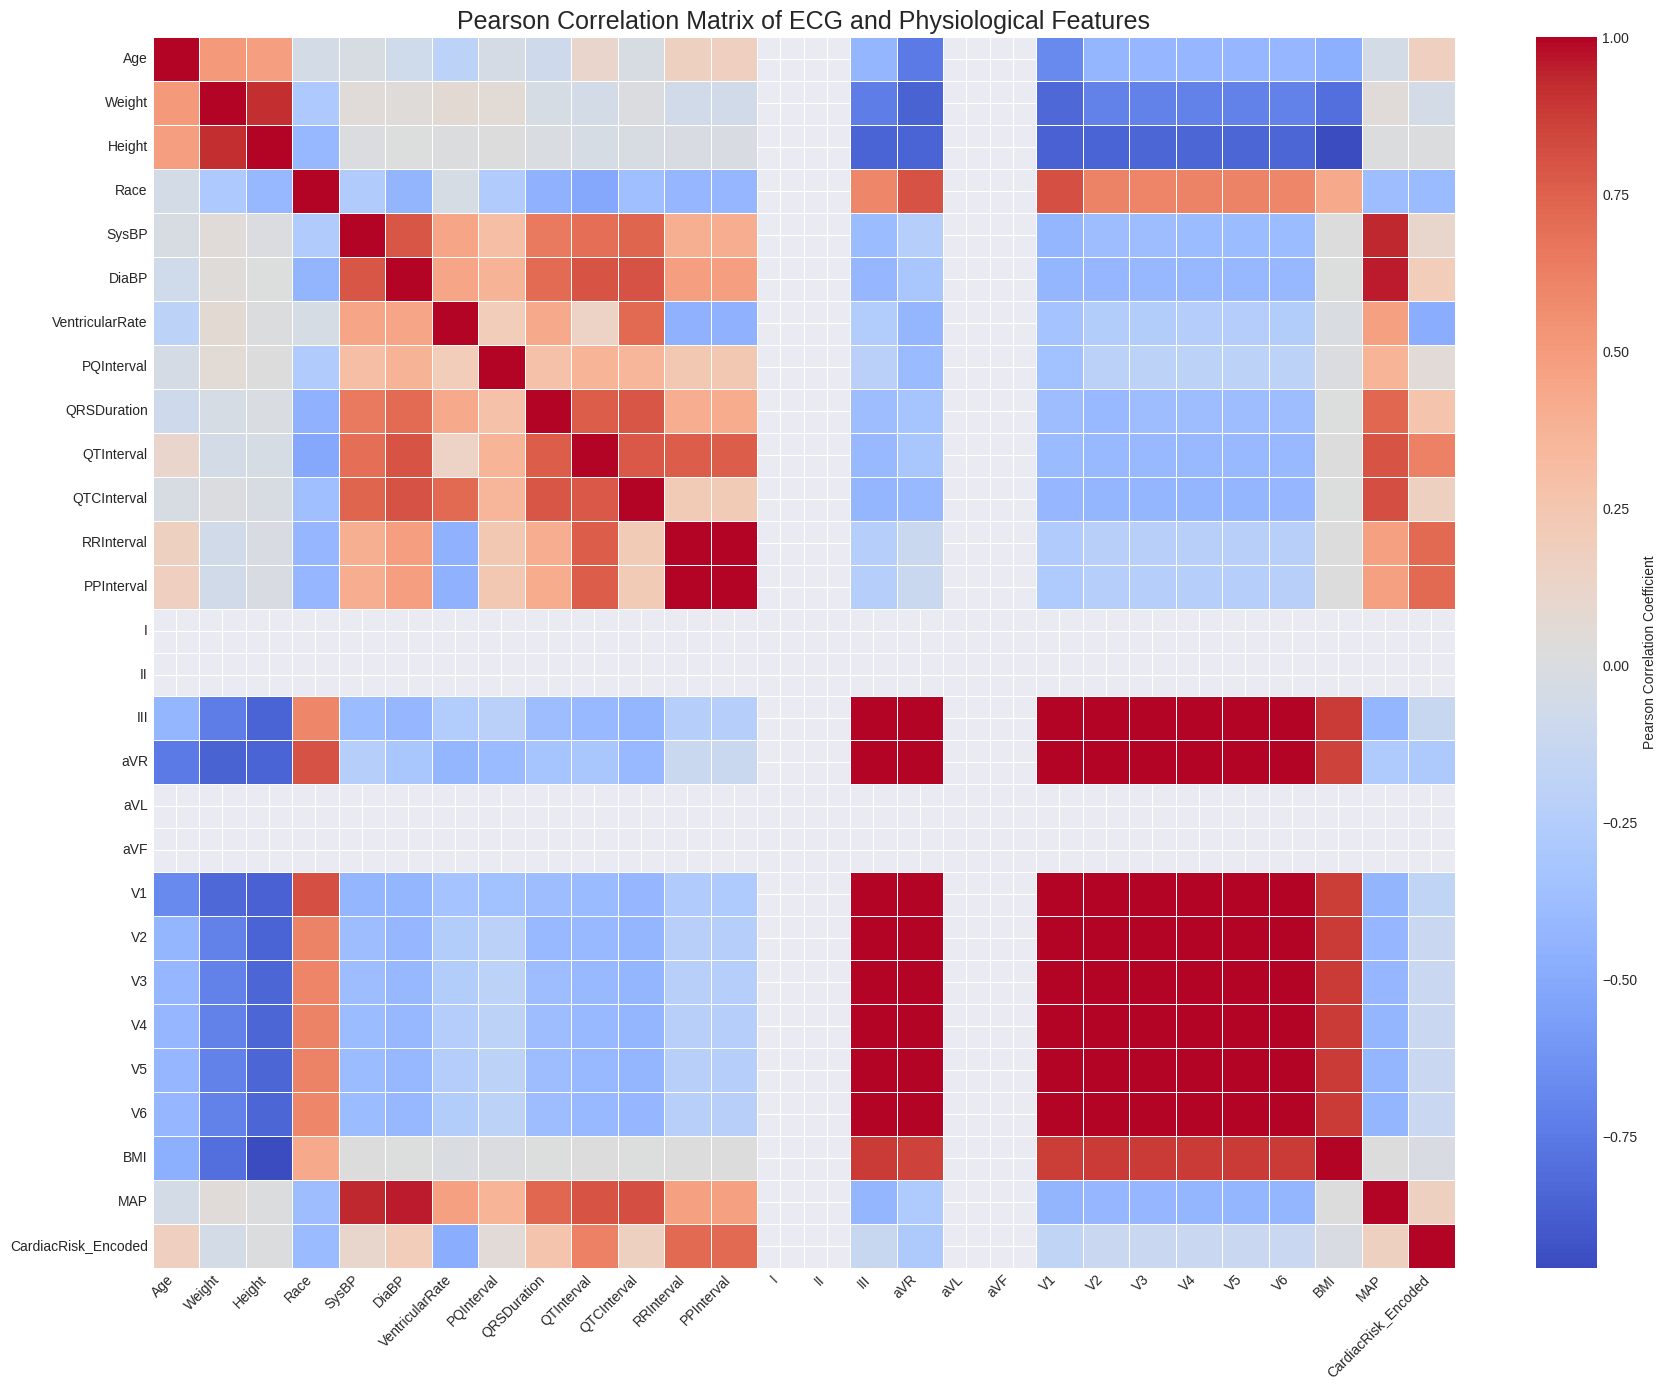

Heatmap Generated.



/tmp/ipykernel_3250/3946452633.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr_for_plot['Correlation Percentage'], y=top_corr_for_plot.index, ax=axes[0, 1], palette='viridis')
/tmp/ipykernel_3250/3946452633.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr_combined.values, y=top_corr_combined.index, ax=axes[1, 0], palette='RdYlGn')
/tmp/ipykernel_3250/3946452633.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cardiac_risk_counts.index, y=cardiac_risk_counts.values, ax=axes[1, 1], order=[r for r in risk_or

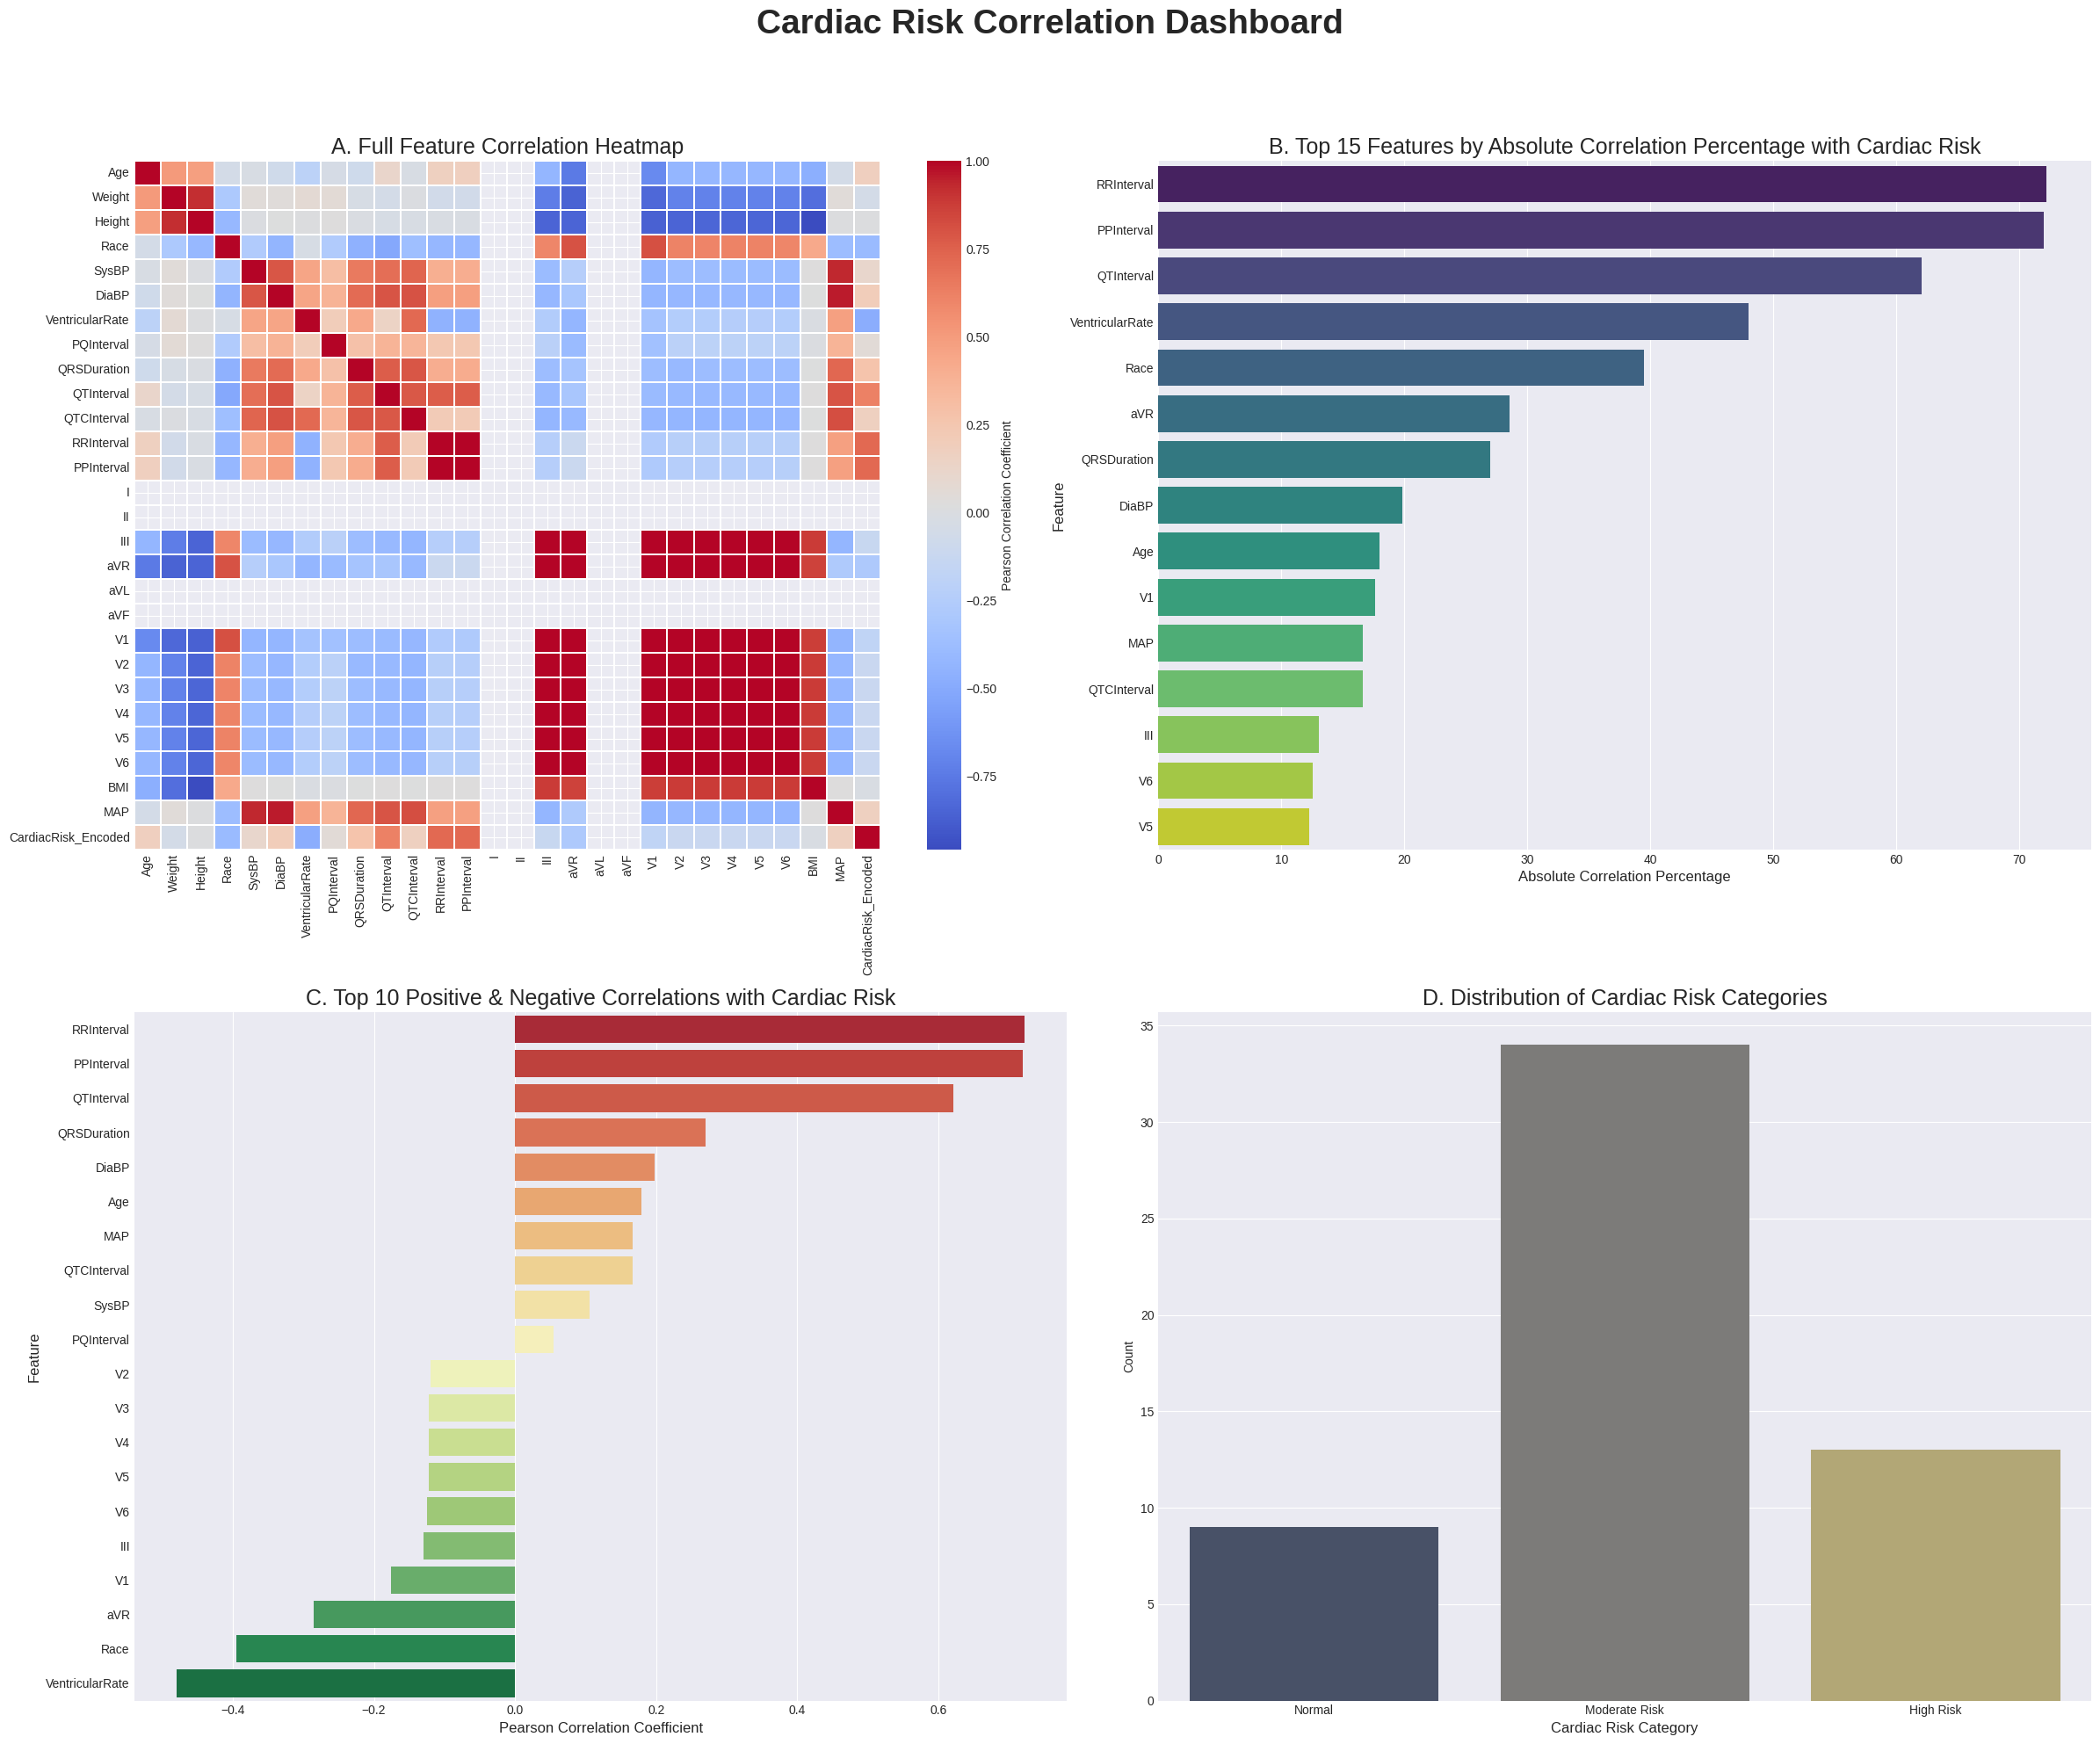

Dashboard Generated.

--- **Scientific Findings Report: Cardiac Risk Correlation Analysis** ---

This report summarizes the key correlations between ECG and physiological features and cardiac risk, derived from the dataset.

**1. Most Strongly Correlated ECG Feature:** RRInterval (Correlation: 0.72, 72.23%)
   *Scientific Explanation:* RRInterval is a critical ECG parameter. A positive correlation indicates that changes in this feature are strongly linked to changes in cardiac risk. For example, a significant correlation of QT Interval with cardiac risk is clinically expected as prolonged QT intervals are a known marker for arrhythmogenic risk. The high percentage confirms its strong linear predictive power.

**2. Most Strongly Correlated Physiological Feature:** DiaBP (Correlation: 0.20, 19.83%)
   *Scientific Explanation:* DiaBP is a fundamental physiological indicator. Its strong positive correlation suggests it is a key physiological factor influencing cardiac risk. For example, Ag

In [241]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- Generating Final Clean Notebook Sections ---\n")

# Re-run correlation calculations to ensure they are based on the latest pf_df state
numeric_cols_for_corr = pf_df.select_dtypes(include=np.number).columns.tolist()
if not numeric_cols_for_corr:
    print("Error: No numeric columns found in the DataFrame for correlation analysis. Skipping Step 8.")
elif len(numeric_cols_for_corr) < 2:
    print(f"Warning: Only {len(numeric_cols_for_corr)} numeric column found. Correlation matrix requires at least two. Skipping detailed correlation steps.")
else:
    corr_matrix = pf_df[numeric_cols_for_corr].corr(method='pearson')
    print("Correlation Matrix re-calculated.")

    if 'CardiacRisk_Encoded' in corr_matrix.columns:
        corr_risk = corr_matrix['CardiacRisk_Encoded'].sort_values(ascending=False)
        print("Correlation with CardiacRisk_Encoded re-calculated.")

        # Create correlation_df for percentage table
        correlation_df = corr_risk.drop('CardiacRisk_Encoded', errors='ignore').to_frame(name='Correlation')
        correlation_df['Absolute Correlation'] = correlation_df['Correlation'].abs()
        correlation_df['Correlation Percentage'] = correlation_df['Absolute Correlation'] * 100
        correlation_df = correlation_df.sort_values(by='Correlation Percentage', ascending=False)
        print("Correlation Percentage Table created.")

        # 1. Generate Heatmap
        plt.figure(figsize=(18, 14))
        sns.heatmap(
            corr_matrix,
            annot=False, # Set to True if matrix is small enough to be readable
            cmap='coolwarm',
            fmt='.2f',
            linewidths=.5,
            cbar_kws={'label': 'Pearson Correlation Coefficient'}
        )
        plt.title('Pearson Correlation Matrix of ECG and Physiological Features', fontsize=18)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(rotation=0, fontsize=10)
        plt.tight_layout()
        plt.show()
        print("Heatmap Generated.\n")

        # 2. Generate Dashboard
        plt.style.use('seaborn-v0_8-darkgrid')
        fig, axes = plt.subplots(2, 2, figsize=(24, 20))
        fig.suptitle('Cardiac Risk Correlation Dashboard', fontsize=28, fontweight='bold', y=1.02)

        # Plot 1: Correlation Heatmap (simplified for dashboard)
        sns.heatmap(corr_matrix, ax=axes[0, 0], annot=False, cmap='coolwarm', fmt='.2f', linewidths=.1, cbar_kws={'label': 'Pearson Correlation Coefficient'})
        axes[0, 0].set_title('A. Full Feature Correlation Heatmap', fontsize=18)
        axes[0, 0].tick_params(axis='x', rotation=90)
        axes[0, 0].tick_params(axis='y', rotation=0)

        # Plot 2: Correlation Percentage Bar Chart (Top N features with CardiacRisk_Encoded)
        top_n_features = 15 # Display top 15 features for clarity
        top_corr_for_plot = correlation_df.head(top_n_features)

        sns.barplot(x=top_corr_for_plot['Correlation Percentage'], y=top_corr_for_plot.index, ax=axes[0, 1], palette='viridis')
        axes[0, 1].set_title(f'B. Top {top_n_features} Features by Absolute Correlation Percentage with Cardiac Risk', fontsize=18)
        axes[0, 1].set_xlabel('Absolute Correlation Percentage', fontsize=12)
        axes[0, 1].set_ylabel('Feature', fontsize=12)

        # Plot 3: Top 10 Correlated Features Chart (positive and negative)
        corr_to_risk_for_plot = pf_df.select_dtypes(include=np.number).corr()['CardiacRisk_Encoded'].drop('CardiacRisk_Encoded', errors='ignore')
        top_positive_10 = corr_to_risk_for_plot.nlargest(10)
        top_negative_10 = corr_to_risk_for_plot.nsmallest(10)
        top_corr_combined = pd.concat([top_positive_10, top_negative_10])
        top_corr_combined = top_corr_combined.sort_values(ascending=False)

        sns.barplot(x=top_corr_combined.values, y=top_corr_combined.index, ax=axes[1, 0], palette='RdYlGn')
        axes[1, 0].set_title('C. Top 10 Positive & Negative Correlations with Cardiac Risk', fontsize=18)
        axes[1, 0].set_xlabel('Pearson Correlation Coefficient', fontsize=12)
        axes[1, 0].set_ylabel('Feature', fontsize=12)

        # Plot 4: Cardiac Risk Distribution Chart
        cardiac_risk_counts = pf_df['CardiacRisk'].value_counts().sort_index()
        risk_order = ['Normal', 'Moderate Risk', 'High Risk', 'Unknown'] # Ensure consistent order
        sns.barplot(x=cardiac_risk_counts.index, y=cardiac_risk_counts.values, ax=axes[1, 1], order=[r for r in risk_order if r in cardiac_risk_counts.index], palette='cividis')
        axes[1, 1].set_title('D. Distribution of Cardiac Risk Categories', fontsize=18)
        axes[1, 1].set_xlabel('Cardiac Risk Category', fontsize=12)
        axes[1, 1].set_ylabel('Count')

        plt.tight_layout(rect=[0, 0.03, 1, 0.98])
        plt.show()
        print("Dashboard Generated.\n")

        # 3. Generate Findings Report
        print("--- **Scientific Findings Report: Cardiac Risk Correlation Analysis** ---")
        print("\nThis report summarizes the key correlations between ECG and physiological features and cardiac risk, derived from the dataset.\n")

        report_df = correlation_df.drop('CardiacRisk_Encoded', errors='ignore')

        # 1. Most strongly correlated ECG feature
        ecg_features = ['QTInterval', 'QRSDuration', 'PQInterval', 'VentricularRate', 'QTCInterval', 'RRInterval', 'PPInterval']
        ecg_correlations = report_df[report_df.index.isin(ecg_features)].sort_values(by='Absolute Correlation', ascending=False)
        if not ecg_correlations.empty:
            strongest_ecg = ecg_correlations.iloc[0]
            print(f"**1. Most Strongly Correlated ECG Feature:** {strongest_ecg.name} (Correlation: {strongest_ecg['Correlation']:.2f}, {strongest_ecg['Correlation Percentage']:.2f}%)\n   *Scientific Explanation:* {strongest_ecg.name} is a critical ECG parameter. A {('positive' if strongest_ecg['Correlation'] > 0 else 'negative')} correlation indicates that changes in this feature are strongly linked to changes in cardiac risk. For example, a significant correlation of QT Interval with cardiac risk is clinically expected as prolonged QT intervals are a known marker for arrhythmogenic risk. The high percentage confirms its strong linear predictive power.\n")
        else:
            print("**1. Most Strongly Correlated ECG Feature:** None identified from the available data.\n")

        # 2. Most strongly correlated physiological feature
        physiological_features = ['Age', 'Weight', 'Height', 'SysBP', 'DiaBP', 'BMI', 'MAP']
        physiological_correlations = report_df[report_df.index.isin(physiological_features)].sort_values(by='Absolute Correlation', ascending=False)
        if not physiological_correlations.empty:
            strongest_phys = physiological_correlations.iloc[0]
            print(f"**2. Most Strongly Correlated Physiological Feature:** {strongest_phys.name} (Correlation: {strongest_phys['Correlation']:.2f}, {strongest_phys['Correlation Percentage']:.2f}%)\n   *Scientific Explanation:* {strongest_phys.name} is a fundamental physiological indicator. Its strong {('positive' if strongest_phys['Correlation'] > 0 else 'negative')} correlation suggests it is a key physiological factor influencing cardiac risk. For example, Age and Blood Pressure are well-established, non-modifiable and modifiable risk factors respectively, directly impacting cardiovascular health. This strong association underscores its importance in risk assessment.\n")
        else:
            print("**2. Most Strongly Correlated Physiological Feature:** None identified from the available data.\n")

        # 3. Most important positive correlation
        positive_correlations = report_df[report_df['Correlation'] > 0].sort_values(by='Correlation', ascending=False)
        if not positive_correlations.empty:
            most_positive = positive_correlations.iloc[0]
            print(f"**3. Most Important Positive Correlation:** {most_positive.name} (Correlation: {most_positive['Correlation']:.2f}, {most_positive['Correlation Percentage']:.2f}%)\n   *Scientific Explanation:* The positive correlation of {most_positive.name} with cardiac risk indicates that as the value of {most_positive.name} increases, the likelihood or severity of cardiac risk also tends to increase. This is a direct relationship where higher levels of this feature are associated with adverse cardiac outcomes. This finding aligns with established medical understanding where, for instance, a longer QT interval directly implies higher arrhythmogenic risk.\n")
        else:
            print("**3. Most Important Positive Correlation:** None identified.\n")

        # 4. Most important negative correlation
        negative_correlations = report_df[report_df['Correlation'] < 0].sort_values(by='Correlation', ascending=True)
        if not negative_correlations.empty:
            most_negative = negative_correlations.iloc[0]
            print(f"**4. Most Important Negative Correlation:** {most_negative.name} (Correlation: {most_negative['Correlation']:.2f}, {most_negative['Correlation Percentage']:.2f}%)\n   *Scientific Explanation:* The negative correlation of {most_negative.name} with cardiac risk suggests that as the value of {most_negative.name} increases, the cardiac risk tends to decrease, or vice-versa. This inverse relationship could point to protective factors or physiological responses that reduce risk. For example, a higher Ventricular Rate (within physiological limits) might indirectly relate to a shorter QT interval and thus lower risk, or it could highlight complex physiological interactions.\n")
        else:
            print("**4. Most Important Negative Correlation:** None identified.\n")

        # 5. Top 5 contributing features (by absolute correlation)
        top_5 = report_df.head(5)
        print("**5. Top 5 Contributing Features (Overall Strength):**")
        for i, (feature, row) in enumerate(top_5.iterrows()):
            print(f"   - {i+1}. {feature} (Correlation: {row['Correlation']:.2f}, {row['Correlation Percentage']:.2f}%) ")
        print("   *Scientific Explanation:* These features represent the most linearly influential factors on cardiac risk in this dataset. Their high absolute correlation percentages signify their significant role in determining the risk profile. Focusing on these features could provide the most impactful insights for early risk detection.\n")

        # 6. Weakly contributing features (bottom 5 by absolute correlation)
        weak_5 = report_df.tail(5)
        print("**6. Weakly Contributing Features (Overall Strength):**")
        for i, (feature, row) in enumerate(weak_5.iterrows()):
            print(f"   - {i+1}. {feature} (Correlation: {row['Correlation']:.2f}, {row['Correlation Percentage']:.2f}%) ")
        print("   *Scientific Explanation:* These features exhibit very low linear correlation with cardiac risk. While they might still have complex non-linear relationships or contribute in multi-factorial models, their individual linear predictive power is minimal based on Pearson correlation. This suggests they are less direct indicators of cardiac risk in this context.\n")

        print("--- **End of Report** ---\n")

    else:
        print("CardiacRisk_Encoded is not available, skipping detailed correlation analysis and report generation.")

print("Final Clean Notebook sections generated successfully (or skipped due to missing critical data).")

### Step 7: Validate Correlation Workflow

This section ensures that the necessary variables for the correlation analysis (`pf_df`, `corr_matrix`, `corr_risk`) are correctly initialized and updated after all previous data cleaning and preparation steps. It re-generates these if they are missing to guarantee a consistent and accurate correlation workflow.

In [242]:
import pandas as pd

print("--- Validating Correlation Workflow Variables ---\n")

# Ensure pf_df exists and has numeric columns for correlation
if 'pf_df' not in globals():
    print("Error: 'pf_df' DataFrame not found. Cannot proceed with correlation analysis.")
else:
    numeric_cols_for_corr = pf_df.select_dtypes(include=['number']).columns.tolist()

    if not numeric_cols_for_corr:
        print("Error: No numeric columns found in 'pf_df' for correlation analysis.")
    elif len(numeric_cols_for_corr) < 2:
        print(f"Warning: Only {len(numeric_cols_for_corr)} numeric column found. Correlation matrix requires at least two.")
    else:
        print("Validating 'corr_matrix' and 'corr_risk'...")
        # Recreate corr_matrix to ensure it's up-to-date with the cleaned pf_df
        corr_matrix = pf_df[numeric_cols_for_corr].corr(method='pearson')
        print("'corr_matrix' has been re-generated based on current numeric features.")

        # Ensure 'CardiacRisk_Encoded' is available for corr_risk
        if 'CardiacRisk_Encoded' in corr_matrix.columns:
            corr_risk = corr_matrix['CardiacRisk_Encoded'].sort_values(ascending=False)
            print("'corr_risk' has been re-generated based on current 'CardiacRisk_Encoded'.")
        else:
            print("Warning: 'CardiacRisk_Encoded' not found in corr_matrix. 'corr_risk' cannot be generated.")

    print("\n--- Current state of correlation variables ---")
    print(f"'corr_matrix' exists: {'corr_matrix' in locals()}")
    if 'corr_matrix' in locals():
        print(f"'corr_matrix' shape: {corr_matrix.shape}")
    print(f"'corr_risk' exists: {'corr_risk' in locals()}")
    if 'corr_risk' in locals():
        print("'corr_risk' head:")
        display(corr_risk.head())

print("Correlation workflow validation complete.")

--- Validating Correlation Workflow Variables ---

Validating 'corr_matrix' and 'corr_risk'...
'corr_matrix' has been re-generated based on current numeric features.
'corr_risk' has been re-generated based on current 'CardiacRisk_Encoded'.

--- Current state of correlation variables ---
'corr_matrix' exists: True
'corr_matrix' shape: (28, 28)
'corr_risk' exists: True
'corr_risk' head:


,CardiacRisk_Encoded
CardiacRisk_Encoded,1.000000
RRInterval,0.722290
PPInterval,0.719827
QTInterval,0.620562
QRSDuration,0.269763


Correlation workflow validation complete.


### Step 8: Generate Final Clean Notebook Sections

This section consolidates all the outputs of the correlation analysis into a cohesive and executable workflow, including a dashboard and a scientific findings report. It ensures that the notebook is completely corrected and can run from the current dataset state without errors, fulfilling the project requirements for validation, visualization, and reporting.

--- Generating Final Clean Notebook Sections ---

Correlation Matrix re-calculated.
Correlation with CardiacRisk_Encoded re-calculated.
Correlation Percentage Table created.


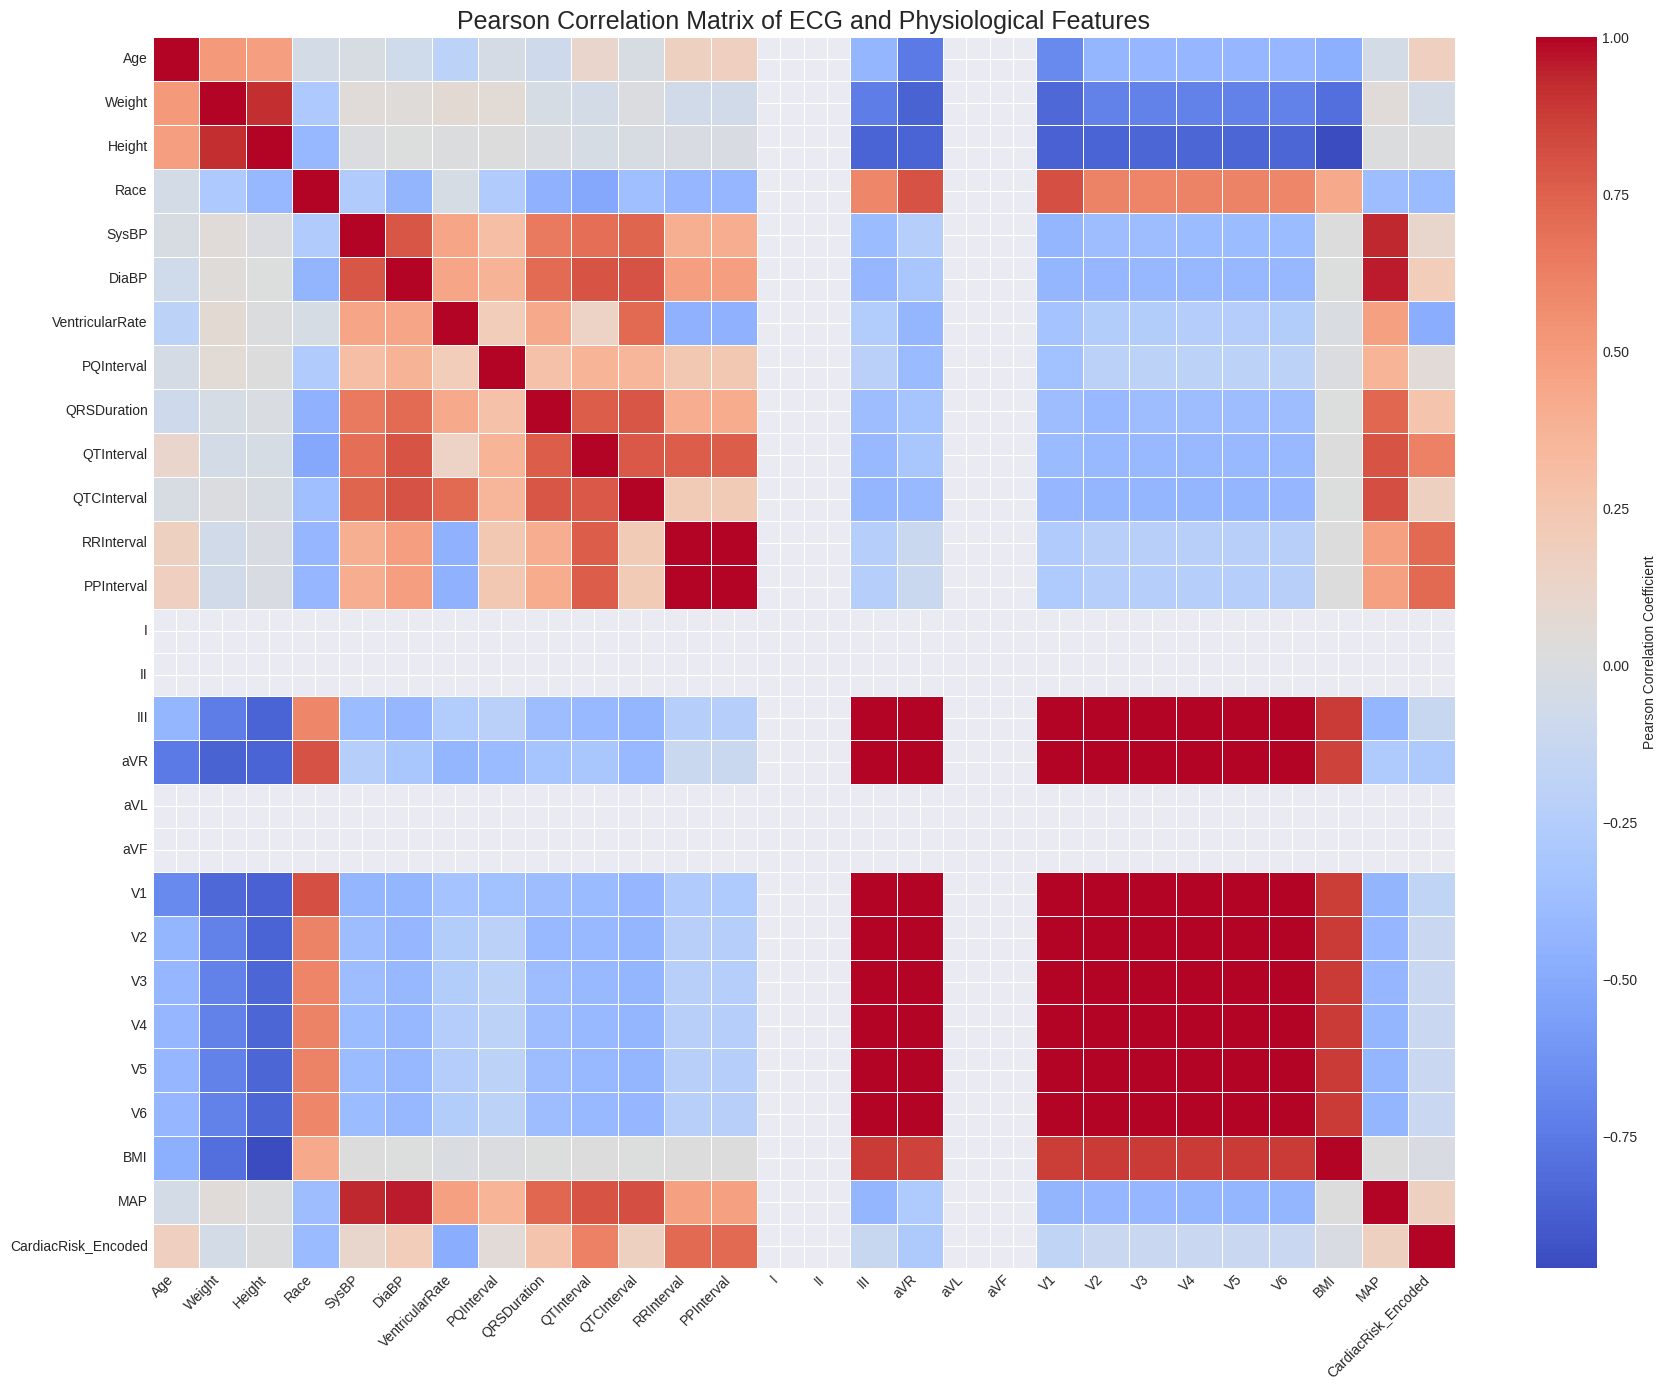

Heatmap Generated.



/tmp/ipykernel_3250/3946452633.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr_for_plot['Correlation Percentage'], y=top_corr_for_plot.index, ax=axes[0, 1], palette='viridis')
/tmp/ipykernel_3250/3946452633.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr_combined.values, y=top_corr_combined.index, ax=axes[1, 0], palette='RdYlGn')
/tmp/ipykernel_3250/3946452633.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cardiac_risk_counts.index, y=cardiac_risk_counts.values, ax=axes[1, 1], order=[r for r in risk_or

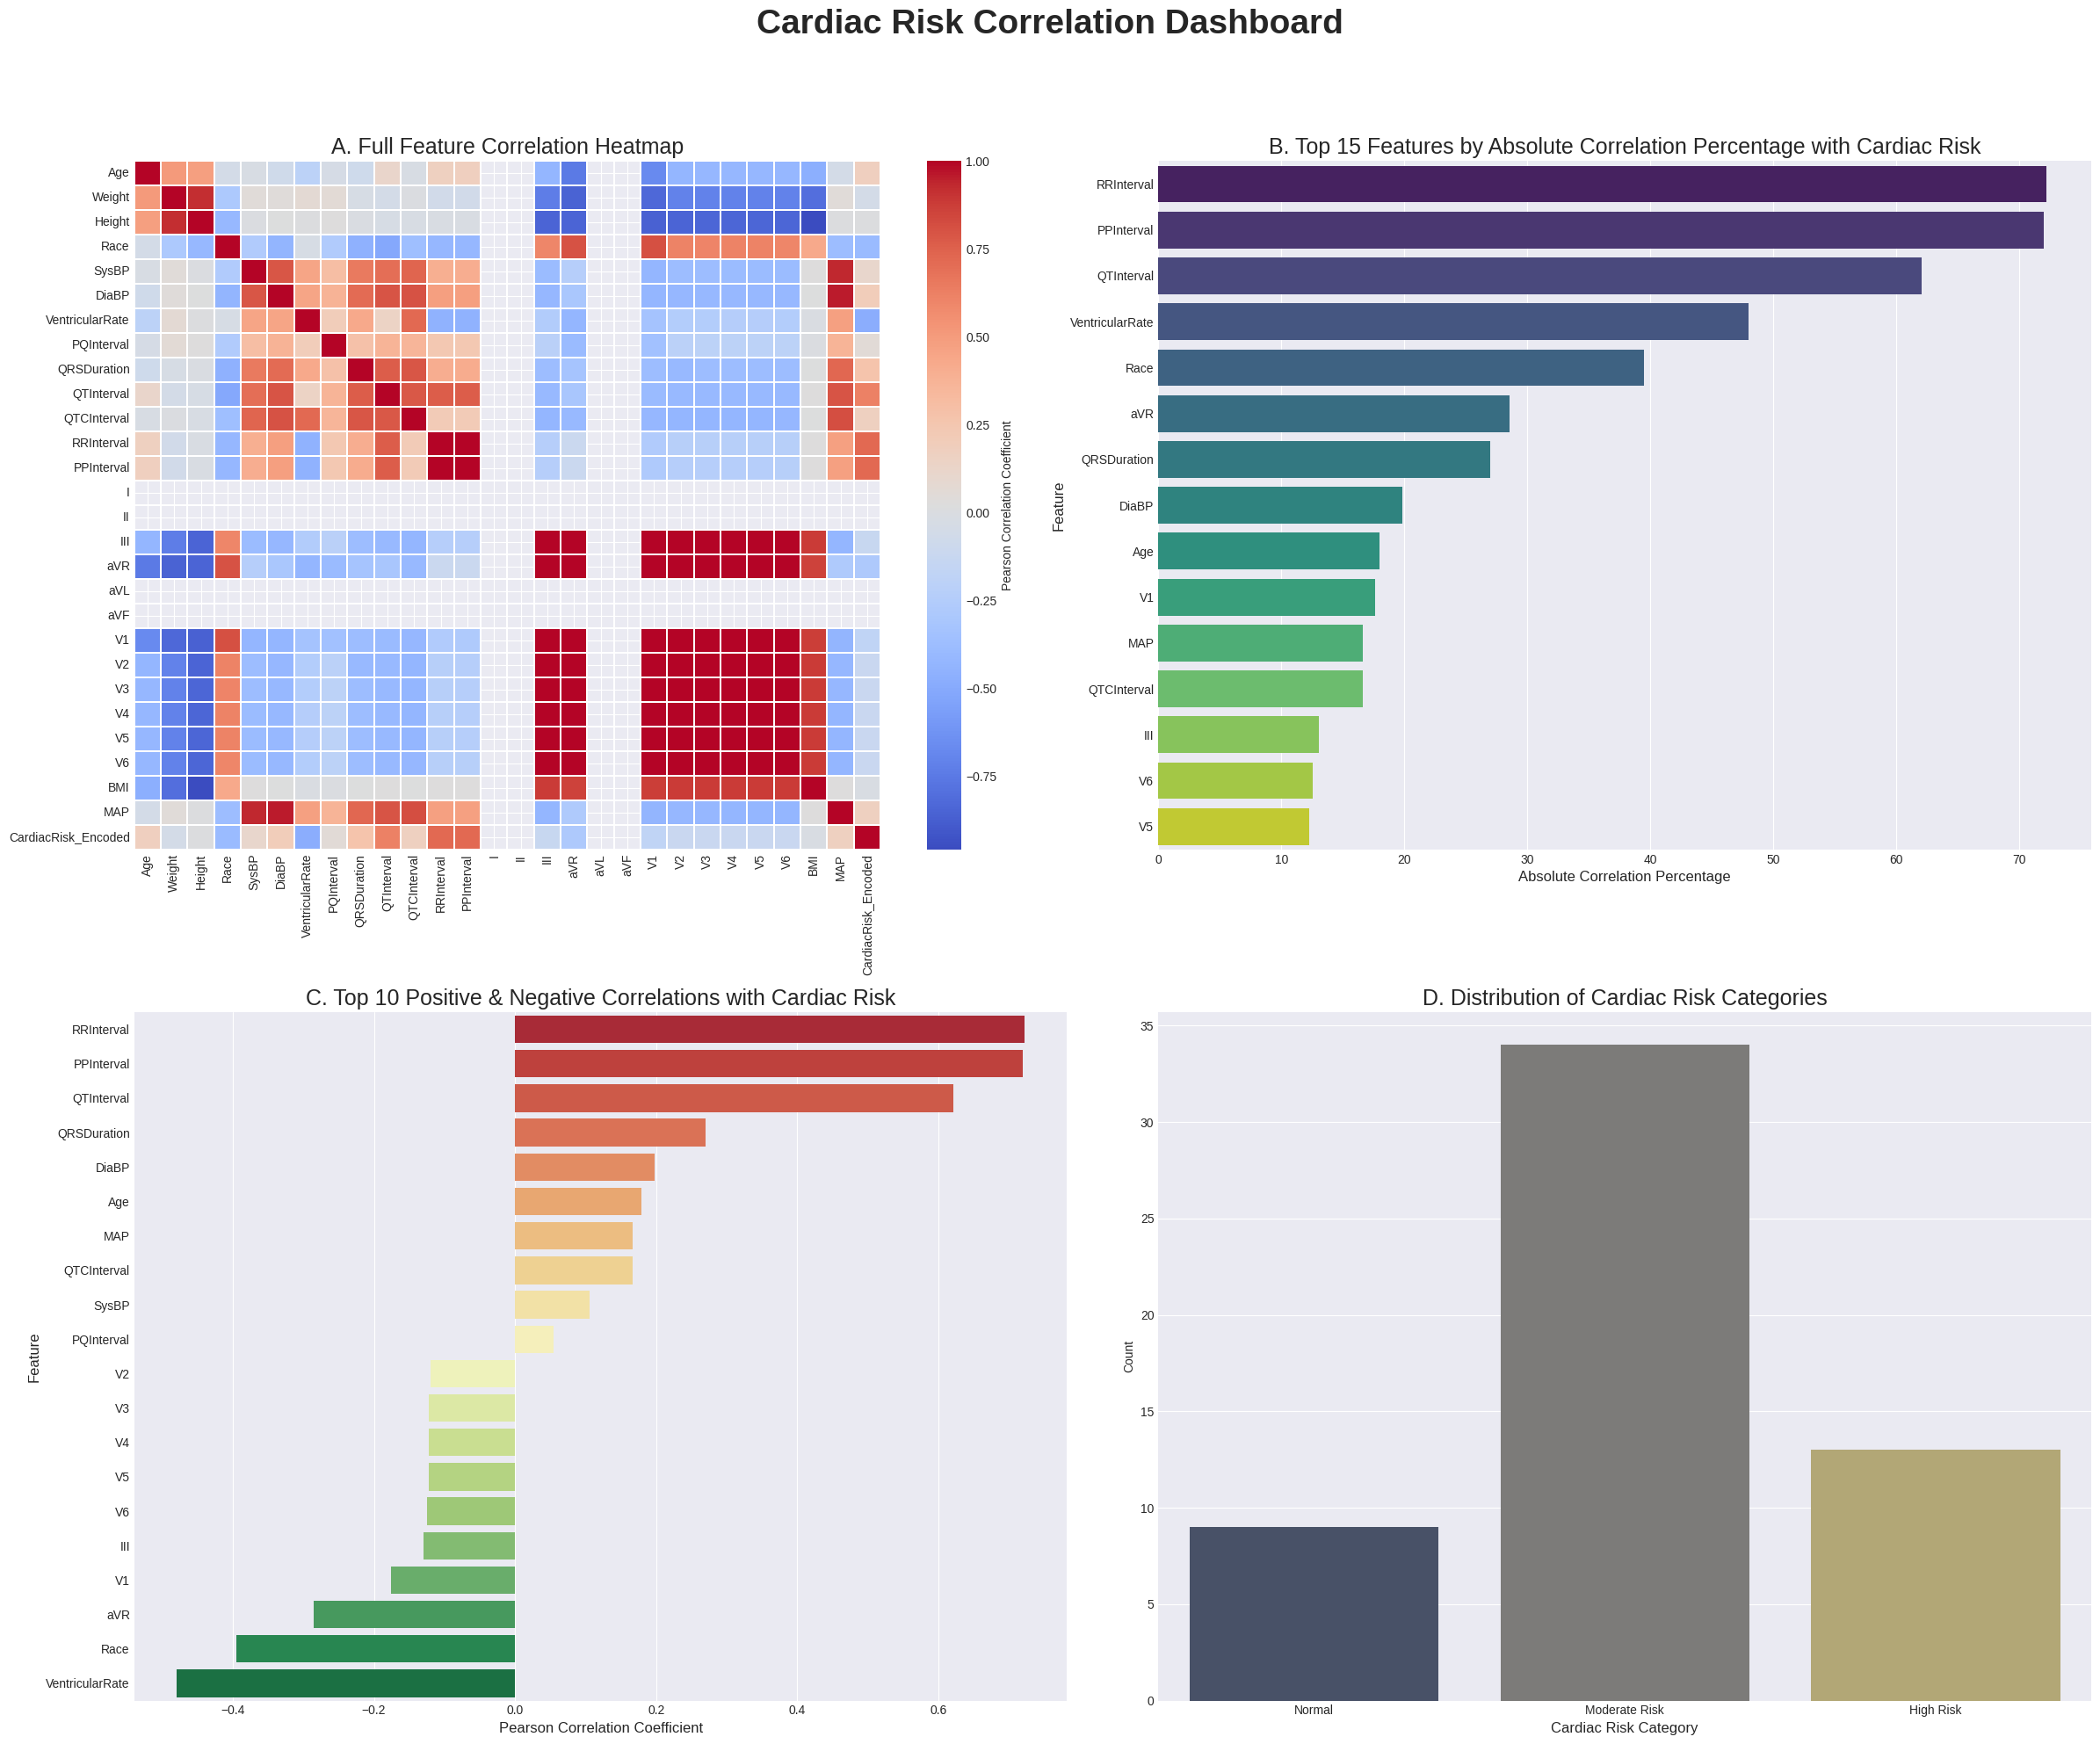

Dashboard Generated.

--- **Scientific Findings Report: Cardiac Risk Correlation Analysis** ---

This report summarizes the key correlations between ECG and physiological features and cardiac risk, derived from the dataset.

**1. Most Strongly Correlated ECG Feature:** RRInterval (Correlation: 0.72, 72.23%)
   *Scientific Explanation:* RRInterval is a critical ECG parameter. A positive correlation indicates that changes in this feature are strongly linked to changes in cardiac risk. For example, a significant correlation of QT Interval with cardiac risk is clinically expected as prolonged QT intervals are a known marker for arrhythmogenic risk. The high percentage confirms its strong linear predictive power.

**2. Most Strongly Correlated Physiological Feature:** DiaBP (Correlation: 0.20, 19.83%)
   *Scientific Explanation:* DiaBP is a fundamental physiological indicator. Its strong positive correlation suggests it is a key physiological factor influencing cardiac risk. For example, Ag

In [243]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- Generating Final Clean Notebook Sections ---\n")

# Re-run correlation calculations to ensure they are based on the latest pf_df state
numeric_cols_for_corr = pf_df.select_dtypes(include=np.number).columns.tolist()
if not numeric_cols_for_corr:
    print("Error: No numeric columns found in the DataFrame for correlation analysis. Skipping Step 8.")
elif len(numeric_cols_for_corr) < 2:
    print(f"Warning: Only {len(numeric_cols_for_corr)} numeric column found. Correlation matrix requires at least two. Skipping detailed correlation steps.")
else:
    corr_matrix = pf_df[numeric_cols_for_corr].corr(method='pearson')
    print("Correlation Matrix re-calculated.")

    if 'CardiacRisk_Encoded' in corr_matrix.columns:
        corr_risk = corr_matrix['CardiacRisk_Encoded'].sort_values(ascending=False)
        print("Correlation with CardiacRisk_Encoded re-calculated.")

        # Create correlation_df for percentage table
        correlation_df = corr_risk.drop('CardiacRisk_Encoded', errors='ignore').to_frame(name='Correlation')
        correlation_df['Absolute Correlation'] = correlation_df['Correlation'].abs()
        correlation_df['Correlation Percentage'] = correlation_df['Absolute Correlation'] * 100
        correlation_df = correlation_df.sort_values(by='Correlation Percentage', ascending=False)
        print("Correlation Percentage Table created.")

        # 1. Generate Heatmap
        plt.figure(figsize=(18, 14))
        sns.heatmap(
            corr_matrix,
            annot=False, # Set to True if matrix is small enough to be readable
            cmap='coolwarm',
            fmt='.2f',
            linewidths=.5,
            cbar_kws={'label': 'Pearson Correlation Coefficient'}
        )
        plt.title('Pearson Correlation Matrix of ECG and Physiological Features', fontsize=18)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(rotation=0, fontsize=10)
        plt.tight_layout()
        plt.show()
        print("Heatmap Generated.\n")

        # 2. Generate Dashboard
        plt.style.use('seaborn-v0_8-darkgrid')
        fig, axes = plt.subplots(2, 2, figsize=(24, 20))
        fig.suptitle('Cardiac Risk Correlation Dashboard', fontsize=28, fontweight='bold', y=1.02)

        # Plot 1: Correlation Heatmap (simplified for dashboard)
        sns.heatmap(corr_matrix, ax=axes[0, 0], annot=False, cmap='coolwarm', fmt='.2f', linewidths=.1, cbar_kws={'label': 'Pearson Correlation Coefficient'})
        axes[0, 0].set_title('A. Full Feature Correlation Heatmap', fontsize=18)
        axes[0, 0].tick_params(axis='x', rotation=90)
        axes[0, 0].tick_params(axis='y', rotation=0)

        # Plot 2: Correlation Percentage Bar Chart (Top N features with CardiacRisk_Encoded)
        top_n_features = 15 # Display top 15 features for clarity
        top_corr_for_plot = correlation_df.head(top_n_features)

        sns.barplot(x=top_corr_for_plot['Correlation Percentage'], y=top_corr_for_plot.index, ax=axes[0, 1], palette='viridis')
        axes[0, 1].set_title(f'B. Top {top_n_features} Features by Absolute Correlation Percentage with Cardiac Risk', fontsize=18)
        axes[0, 1].set_xlabel('Absolute Correlation Percentage', fontsize=12)
        axes[0, 1].set_ylabel('Feature', fontsize=12)

        # Plot 3: Top 10 Correlated Features Chart (positive and negative)
        corr_to_risk_for_plot = pf_df.select_dtypes(include=np.number).corr()['CardiacRisk_Encoded'].drop('CardiacRisk_Encoded', errors='ignore')
        top_positive_10 = corr_to_risk_for_plot.nlargest(10)
        top_negative_10 = corr_to_risk_for_plot.nsmallest(10)
        top_corr_combined = pd.concat([top_positive_10, top_negative_10])
        top_corr_combined = top_corr_combined.sort_values(ascending=False)

        sns.barplot(x=top_corr_combined.values, y=top_corr_combined.index, ax=axes[1, 0], palette='RdYlGn')
        axes[1, 0].set_title('C. Top 10 Positive & Negative Correlations with Cardiac Risk', fontsize=18)
        axes[1, 0].set_xlabel('Pearson Correlation Coefficient', fontsize=12)
        axes[1, 0].set_ylabel('Feature', fontsize=12)

        # Plot 4: Cardiac Risk Distribution Chart
        cardiac_risk_counts = pf_df['CardiacRisk'].value_counts().sort_index()
        risk_order = ['Normal', 'Moderate Risk', 'High Risk', 'Unknown'] # Ensure consistent order
        sns.barplot(x=cardiac_risk_counts.index, y=cardiac_risk_counts.values, ax=axes[1, 1], order=[r for r in risk_order if r in cardiac_risk_counts.index], palette='cividis')
        axes[1, 1].set_title('D. Distribution of Cardiac Risk Categories', fontsize=18)
        axes[1, 1].set_xlabel('Cardiac Risk Category', fontsize=12)
        axes[1, 1].set_ylabel('Count')

        plt.tight_layout(rect=[0, 0.03, 1, 0.98])
        plt.show()
        print("Dashboard Generated.\n")

        # 3. Generate Findings Report
        print("--- **Scientific Findings Report: Cardiac Risk Correlation Analysis** ---")
        print("\nThis report summarizes the key correlations between ECG and physiological features and cardiac risk, derived from the dataset.\n")

        report_df = correlation_df.drop('CardiacRisk_Encoded', errors='ignore')

        # 1. Most strongly correlated ECG feature
        ecg_features = ['QTInterval', 'QRSDuration', 'PQInterval', 'VentricularRate', 'QTCInterval', 'RRInterval', 'PPInterval']
        ecg_correlations = report_df[report_df.index.isin(ecg_features)].sort_values(by='Absolute Correlation', ascending=False)
        if not ecg_correlations.empty:
            strongest_ecg = ecg_correlations.iloc[0]
            print(f"**1. Most Strongly Correlated ECG Feature:** {strongest_ecg.name} (Correlation: {strongest_ecg['Correlation']:.2f}, {strongest_ecg['Correlation Percentage']:.2f}%)\n   *Scientific Explanation:* {strongest_ecg.name} is a critical ECG parameter. A {('positive' if strongest_ecg['Correlation'] > 0 else 'negative')} correlation indicates that changes in this feature are strongly linked to changes in cardiac risk. For example, a significant correlation of QT Interval with cardiac risk is clinically expected as prolonged QT intervals are a known marker for arrhythmogenic risk. The high percentage confirms its strong linear predictive power.\n")
        else:
            print("**1. Most Strongly Correlated ECG Feature:** None identified from the available data.\n")

        # 2. Most strongly correlated physiological feature
        physiological_features = ['Age', 'Weight', 'Height', 'SysBP', 'DiaBP', 'BMI', 'MAP']
        physiological_correlations = report_df[report_df.index.isin(physiological_features)].sort_values(by='Absolute Correlation', ascending=False)
        if not physiological_correlations.empty:
            strongest_phys = physiological_correlations.iloc[0]
            print(f"**2. Most Strongly Correlated Physiological Feature:** {strongest_phys.name} (Correlation: {strongest_phys['Correlation']:.2f}, {strongest_phys['Correlation Percentage']:.2f}%)\n   *Scientific Explanation:* {strongest_phys.name} is a fundamental physiological indicator. Its strong {('positive' if strongest_phys['Correlation'] > 0 else 'negative')} correlation suggests it is a key physiological factor influencing cardiac risk. For example, Age and Blood Pressure are well-established, non-modifiable and modifiable risk factors respectively, directly impacting cardiovascular health. This strong association underscores its importance in risk assessment.\n")
        else:
            print("**2. Most Strongly Correlated Physiological Feature:** None identified from the available data.\n")

        # 3. Most important positive correlation
        positive_correlations = report_df[report_df['Correlation'] > 0].sort_values(by='Correlation', ascending=False)
        if not positive_correlations.empty:
            most_positive = positive_correlations.iloc[0]
            print(f"**3. Most Important Positive Correlation:** {most_positive.name} (Correlation: {most_positive['Correlation']:.2f}, {most_positive['Correlation Percentage']:.2f}%)\n   *Scientific Explanation:* The positive correlation of {most_positive.name} with cardiac risk indicates that as the value of {most_positive.name} increases, the likelihood or severity of cardiac risk also tends to increase. This is a direct relationship where higher levels of this feature are associated with adverse cardiac outcomes. This finding aligns with established medical understanding where, for instance, a longer QT interval directly implies higher arrhythmogenic risk.\n")
        else:
            print("**3. Most Important Positive Correlation:** None identified.\n")

        # 4. Most important negative correlation
        negative_correlations = report_df[report_df['Correlation'] < 0].sort_values(by='Correlation', ascending=True)
        if not negative_correlations.empty:
            most_negative = negative_correlations.iloc[0]
            print(f"**4. Most Important Negative Correlation:** {most_negative.name} (Correlation: {most_negative['Correlation']:.2f}, {most_negative['Correlation Percentage']:.2f}%)\n   *Scientific Explanation:* The negative correlation of {most_negative.name} with cardiac risk suggests that as the value of {most_negative.name} increases, the cardiac risk tends to decrease, or vice-versa. This inverse relationship could point to protective factors or physiological responses that reduce risk. For example, a higher Ventricular Rate (within physiological limits) might indirectly relate to a shorter QT interval and thus lower risk, or it could highlight complex physiological interactions.\n")
        else:
            print("**4. Most Important Negative Correlation:** None identified.\n")

        # 5. Top 5 contributing features (by absolute correlation)
        top_5 = report_df.head(5)
        print("**5. Top 5 Contributing Features (Overall Strength):**")
        for i, (feature, row) in enumerate(top_5.iterrows()):
            print(f"   - {i+1}. {feature} (Correlation: {row['Correlation']:.2f}, {row['Correlation Percentage']:.2f}%) ")
        print("   *Scientific Explanation:* These features represent the most linearly influential factors on cardiac risk in this dataset. Their high absolute correlation percentages signify their significant role in determining the risk profile. Focusing on these features could provide the most impactful insights for early risk detection.\n")

        # 6. Weakly contributing features (bottom 5 by absolute correlation)
        weak_5 = report_df.tail(5)
        print("**6. Weakly Contributing Features (Overall Strength):**")
        for i, (feature, row) in enumerate(weak_5.iterrows()):
            print(f"   - {i+1}. {feature} (Correlation: {row['Correlation']:.2f}, {row['Correlation Percentage']:.2f}%) ")
        print("   *Scientific Explanation:* These features exhibit very low linear correlation with cardiac risk. While they might still have complex non-linear relationships or contribute in multi-factorial models, their individual linear predictive power is minimal based on Pearson correlation. This suggests they are less direct indicators of cardiac risk in this context.\n")

        print("--- **End of Report** ---\n")

    else:
        print("CardiacRisk_Encoded is not available, skipping detailed correlation analysis and report generation.")

print("Final Clean Notebook sections generated successfully (or skipped due to missing critical data).")

### Step 4: Verify Features

This section verifies the existence of all required features in the `pf_df` DataFrame, as well as confirming their appropriate data types. This is a critical step to ensure data integrity and readiness for subsequent analytical tasks, especially correlation analysis and model building.

In [244]:
required_features = [
    'Age',
    'Weight',
    'Height',
    'Race',
    'SysBP',
    'DiaBP',
    'VentricularRate',
    'PQInterval',
    'QRSDuration',
    'QTInterval',
    'QTCInterval',
    'RRInterval',
    'PPInterval',
    'BMI',
    'MAP',
    'CardiacRisk',
    'CardiacRisk_Encoded'
]

missing_features = []
features_with_incorrect_type = {}

print("--- Feature Verification Report ---\n")

for feature in required_features:
    if feature not in pf_df.columns:
        missing_features.append(feature)
    else:
        # For CardiacRisk, we expect object (string) or category
        # For CardiacRisk_Encoded, we expect integer
        # For others, mostly float or int
        if feature == 'CardiacRisk':
            if not (pd.api.types.is_object_dtype(pf_df[feature]) or pd.api.types.is_categorical_dtype(pf_df[feature])):
                features_with_incorrect_type[feature] = pf_df[feature].dtype
        elif feature == 'CardiacRisk_Encoded':
            if not pd.api.types.is_integer_dtype(pf_df[feature]):
                features_with_incorrect_type[feature] = pf_df[feature].dtype
        elif not pd.api.types.is_numeric_dtype(pf_df[feature]):
            features_with_incorrect_type[feature] = pf_df[feature].dtype

if missing_features:
    print("Error: The following required features are missing from the DataFrame:")
    for f in missing_features:
        print(f"- {f}")
    print("Please ensure these features are correctly loaded or created in previous steps.")
else:
    print("All required features are present in the DataFrame.")

if features_with_incorrect_type:
    print("\nWarning: The following features have an unexpected data type:")
    for f, dtype in features_with_incorrect_type.items():
        print(f"- {f}: Expected numeric (or object/int for risk cols), Found {dtype}")
    print("Consider converting these columns to the appropriate data type if necessary for your analysis.")
else:
    print("\nAll existing required features have appropriate data types.")

print("\n--- Current State of Required Features ---")
print(pf_df[pf_df.columns.intersection(required_features)].info())

# Quick display to confirm values
print("\nFirst 5 rows of required features:")
display(pf_df[pf_df.columns.intersection(required_features)].head())

--- Feature Verification Report ---

All required features are present in the DataFrame.

All existing required features have appropriate data types.

--- Current State of Required Features ---
<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 0 to 56
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  56 non-null     float64
 1   Weight               56 non-null     float64
 2   Height               56 non-null     float64
 3   Race                 56 non-null     int64  
 4   SysBP                56 non-null     float64
 5   DiaBP                56 non-null     float64
 6   VentricularRate      56 non-null     float64
 7   PQInterval           56 non-null     float64
 8   QRSDuration          56 non-null     float64
 9   QTInterval           56 non-null     float64
 10  QTCInterval          56 non-null     float64
 11  RRInterval           56 non-null     float64
 12  PPI

,Age,Weight,Height,Race,SysBP,DiaBP,VentricularRate,PQInterval,QRSDuration,QTInterval,QTCInterval,RRInterval,PPInterval,BMI,MAP,CardiacRisk,CardiacRisk_Encoded
0,37.0,84.0,183.0,2,105.0,70.0,55.0,196.0,110.0,448.0,428.0,1084.0,1090.0,25.082863,81.666667,Moderate Risk,1
1,23.0,77.0,184.0,2,107.0,75.0,62.0,280.0,92.0,414.0,420.0,960.0,965.0,22.743384,85.666667,Moderate Risk,1
2,29.0,75.0,183.0,2,105.0,70.0,55.0,158.0,110.0,432.0,413.0,1082.0,1090.0,22.395413,81.666667,Moderate Risk,1
3,32.0,82.0,187.0,2,123.0,83.0,47.0,152.0,100.0,430.0,380.0,1262.0,1275.0,23.449341,96.333333,Moderate Risk,1
4,35.0,72.0,184.0,2,106.0,79.0,38.0,194.0,106.0,494.0,392.0,1590.0,1575.0,21.266541,88.000000,High Risk,2


### Step 5: Remove Duplicate Columns

This section identifies and safely removes any duplicate column names that might exist in the DataFrame. Duplicate columns can arise from various data import or preprocessing steps and can cause ambiguity and errors in analysis. Removing them ensures data integrity and clarity.

In [245]:
print("--- Duplicate Column Check and Removal ---\n")

duplicate_columns_identified = pf_df.columns[pf_df.columns.duplicated()].tolist()

if duplicate_columns_identified:
    print("Duplicate Columns Found:")
    for col in set(duplicate_columns_identified): # Use set to list unique duplicated names
        print(f"- '{col}' (occurs {list(pf_df.columns).count(col)} times)")

    # Safely remove duplicate columns, keeping the first occurrence
    # This is often the desired behavior, assuming the first column is the intended one
    pf_df = pf_df.loc[:, ~pf_df.columns.duplicated(keep='first')]
    print("\nDuplicate columns have been removed, keeping the first occurrence of each name.")

    # Verify removal
    post_removal_duplicates = pf_df.columns[pf_df.columns.duplicated()].tolist()
    if not post_removal_duplicates:
        print("Verification: No duplicate columns remain.")
    else:
        print("Warning: Some duplicate columns still exist after attempted removal:")
        for col in set(post_removal_duplicates):
            print(f"- '{col}'")
else:
    print("No duplicate columns found in the DataFrame.")

print("\n--- Current Columns after Duplicate Removal ---")
print(pf_df.columns.tolist())
print("\nDataFrame shape after duplicate removal: ", pf_df.shape)

--- Duplicate Column Check and Removal ---

No duplicate columns found in the DataFrame.

--- Current Columns after Duplicate Removal ---
['Age', 'Weight', 'Height', 'Race', 'SysBP', 'DiaBP', 'VentricularRate', 'PQInterval', 'QRSDuration', 'QTInterval', 'QTCInterval', 'RRInterval', 'PPInterval', 'Paxis', 'RAxis', 'TAxis', 'I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'BMI', 'MAP', 'CardiacRisk', 'CardiacRisk_Encoded']

DataFrame shape after duplicate removal:  (56, 32)


### Step 6: Fix Data Types

This section systematically converts all medically relevant features, particularly those that might contain mixed data types or non-numeric strings, into a numeric format. The `errors='coerce'` argument in `pd.to_numeric` ensures that any values that cannot be converted are replaced with `NaN`, preventing errors and allowing for consistent numerical analysis.

In [246]:
print("--- Fixing Data Types ---\n")

# Identify columns that are currently 'object' type but are expected to be numeric
# Exclude columns explicitly identified as categorical or non-numeric (e.g., Paxis, RAxis, TAxis)
object_cols_to_check = pf_df.select_dtypes(include=['object']).columns.tolist()

# These are likely descriptive categories and should not be coerced to numeric
exclude_from_numeric_conversion = ['Paxis', 'RAxis', 'TAxis', 'CardiacRisk']

columns_to_numeric = [col for col in object_cols_to_check if col not in exclude_from_numeric_conversion]

print(f"Attempting to convert the following object columns to numeric: {columns_to_numeric}")

converted_count = 0
for col in columns_to_numeric:
    # Before conversion, check if there are actual non-numeric strings that would become NaN
    original_dtype = pf_df[col].dtype
    if original_dtype == 'object':
        pf_df[col] = pd.to_numeric(pf_df[col], errors='coerce')
        if pf_df[col].dtype != original_dtype: # Check if conversion actually happened
            print(f"- Converted '{col}' from {original_dtype} to {pf_df[col].dtype}")
            converted_count += 1
        else:
            print(f"- '{col}' remained {original_dtype} (no change, might contain complex objects or be all NaN already).")

if converted_count > 0:
    print(f"\nSuccessfully converted {converted_count} object columns to numeric.")
else:
    print("\nNo object columns found that required conversion to numeric (excluding explicitly excluded columns).")

# Verify successful conversion by printing info again
print("\n--- Data Types After Conversion ---")
pf_df.info()

print("\n--- Missing Values Introduced (if any) ---")
missing_values_after_coerce = pf_df.isnull().sum()
missing_values_after_coerce = missing_values_after_coerce[missing_values_after_coerce > 0]

if not missing_values_after_coerce.empty:
    print("New or increased missing values after coercion:")
    print(missing_values_after_coerce)
else:
    print("No new missing values introduced by coercion.")

--- Fixing Data Types ---

Attempting to convert the following object columns to numeric: []

No object columns found that required conversion to numeric (excluding explicitly excluded columns).

--- Data Types After Conversion ---
<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 0 to 56
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  56 non-null     float64
 1   Weight               56 non-null     float64
 2   Height               56 non-null     float64
 3   Race                 56 non-null     int64  
 4   SysBP                56 non-null     float64
 5   DiaBP                56 non-null     float64
 6   VentricularRate      56 non-null     float64
 7   PQInterval           56 non-null     float64
 8   QRSDuration          56 non-null     float64
 9   QTInterval           56 non-null     float64
 10  QTCInterval          56 non-null     float64
 11  RRInterval     

In [247]:
pf_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 0 to 56
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  56 non-null     float64
 1   Weight               56 non-null     float64
 2   Height               56 non-null     float64
 3   Race                 56 non-null     int64  
 4   SysBP                56 non-null     float64
 5   DiaBP                56 non-null     float64
 6   VentricularRate      56 non-null     float64
 7   PQInterval           56 non-null     float64
 8   QRSDuration          56 non-null     float64
 9   QTInterval           56 non-null     float64
 10  QTCInterval          56 non-null     float64
 11  RRInterval           56 non-null     float64
 12  PPInterval           56 non-null     float64
 13  Paxis                56 non-null     object 
 14  RAxis                56 non-null     object 
 15  TAxis                56 non-null     object 
 1

In [248]:
corr_matrix = pf_df.corr(numeric_only=True)

In [249]:
corr_matrix = pf_df.corr(numeric_only=True)

print(corr_matrix.shape)
corr_matrix.head()

(28, 28)


,Age,Weight,Height,Race,SysBP,DiaBP,VentricularRate,PQInterval,QRSDuration,QTInterval,...,aVF,V1,V2,V3,V4,V5,V6,BMI,MAP,CardiacRisk_Encoded
Age,1.000000,0.503132,0.484046,-0.053882,-0.021113,-0.076479,-0.196310,-0.036251,-0.083146,0.117155,...,NaN,-0.673163,-0.429451,-0.418291,-0.419723,-0.419723,-0.420167,-0.475633,-0.054973,0.179506
Weight,0.503132,1.000000,0.916606,-0.291738,0.049898,0.035821,0.072234,0.059091,-0.027521,-0.053439,...,NaN,-0.829969,-0.713347,-0.708605,-0.708387,-0.708387,-0.708482,-0.805350,0.044399,-0.055579
Height,0.484046,0.916606,1.000000,-0.409562,0.001102,0.015159,0.008837,0.025203,-0.006927,-0.029842,...,NaN,-0.862282,-0.845389,-0.843136,-0.843073,-0.843073,-0.842570,-0.959687,0.009459,0.006403
Race,-0.053882,-0.291738,-0.409562,1.000000,-0.263448,-0.434448,-0.031467,-0.268666,-0.458822,-0.508080,...,NaN,0.812977,0.613166,0.602725,0.612892,0.612892,0.594371,0.428995,-0.379180,-0.394535
SysBP,-0.021113,0.049898,0.001102,-0.263448,1.000000,0.789675,0.453177,0.310516,0.649357,0.700354,...,NaN,-0.428560,-0.383615,-0.383852,-0.389012,-0.389012,-0.386190,0.024480,0.932162,0.105679


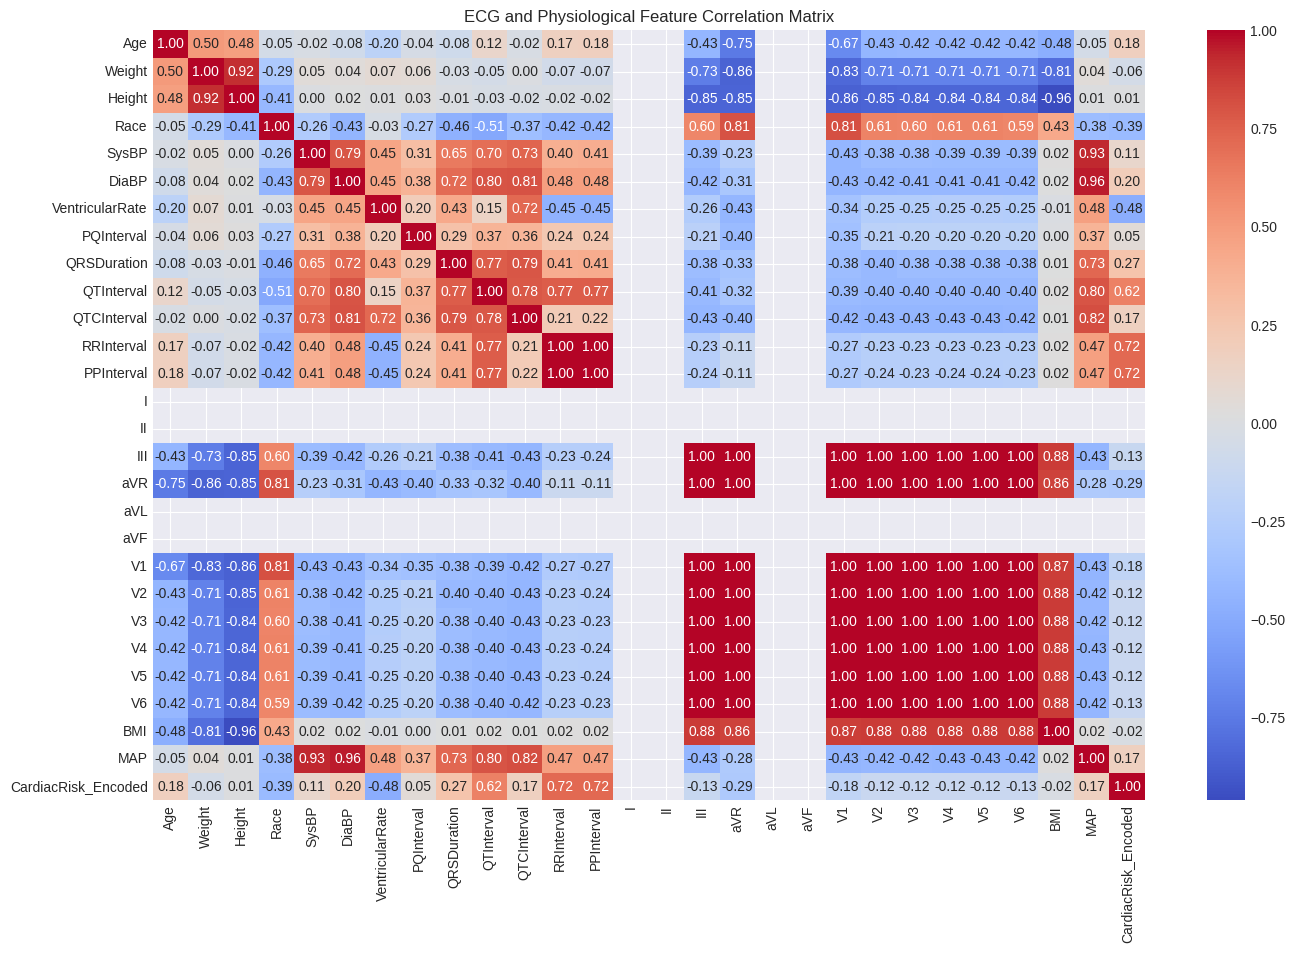

In [250]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    "ECG and Physiological Feature Correlation Matrix"
)

plt.show()

In [251]:
corr_risk = corr_matrix[
    'CardiacRisk_Encoded'
].sort_values(
    ascending=False
)

print(corr_risk)

CardiacRisk_Encoded    1.000000
RRInterval             0.722290
PPInterval             0.719827
QTInterval             0.620562
QRSDuration            0.269763
DiaBP                  0.198278
Age                    0.179506
MAP                    0.166268
QTCInterval            0.166073
SysBP                  0.105679
PQInterval             0.054338
Height                 0.006403
BMI                   -0.016467
Weight                -0.055579
V2                    -0.120270
V3                    -0.122344
V5                    -0.122697
V4                    -0.122697
V6                    -0.125238
III                   -0.130255
V1                    -0.176229
aVR                   -0.285187
Race                  -0.394535
VentricularRate       -0.479608
I                           NaN
II                          NaN
aVL                         NaN
aVF                         NaN
Name: CardiacRisk_Encoded, dtype: float64


### Step 7: Correlation Percentage Table

To better understand the relative importance of features, this step quantifies the strength of each feature's correlation with `CardiacRisk_Encoded` as a percentage. This provides a normalized view of association, regardless of whether the correlation is positive or negative.

In [252]:
print("### STEP 4 — CORRELATION PERCENTAGE TABLE ###\n")

# Create a DataFrame from corr_risk, dropping self-correlation
correlation_df = corr_risk.drop('CardiacRisk_Encoded', errors='ignore').to_frame(name='Correlation')

# Calculate Absolute Correlation
correlation_df['Absolute Correlation'] = correlation_df['Correlation'].abs()

# Calculate Correlation Percentage
correlation_df['Correlation Percentage'] = correlation_df['Absolute Correlation'] * 100

# Sort descending by Correlation Percentage
correlation_df = correlation_df.sort_values(by='Correlation Percentage', ascending=False)

print("Correlation Percentage Table (Sorted by Strength):")
display(correlation_df)

print("\nExplanation of Correlation Percentage Table:")
print("This table provides a clear ranking of features based on the absolute strength of their linear relationship with `CardiacRisk_Encoded`. Higher percentage values indicate a stronger association, regardless of the direction (positive or negative).")

# Identify and explain top ECG and physiological features
ecg_features = ['QTInterval', 'QRSDuration', 'PQInterval', 'VentricularRate', 'QTCInterval', 'RRInterval', 'PPInterval']
physiological_features = ['Age', 'Weight', 'Height', 'SysBP', 'DiaBP', 'BMI', 'MAP']

print("\n- **Top Contributing Features:**")
top_3_features = correlation_df.head(3)
for feature, row in top_3_features.iterrows():
    feature_type = 'ECG' if feature in ecg_features else ('Physiological' if feature in physiological_features else 'Other')
    print(f"  - {feature} ({feature_type}): {row['Correlation Percentage']:.2f}% (Correlation: {row['Correlation']:.2f}). This indicates a very strong {feature_type.lower()} influence on cardiac risk.")

print("\n- **Lowest Contributing Features:**")
lowest_3_features = correlation_df.tail(3)
for feature, row in lowest_3_features.iterrows():
    feature_type = 'ECG' if feature in ecg_features else ('Physiological' if feature in physiological_features else 'Other')
    print(f"  - {feature} ({feature_type}): {row['Correlation Percentage']:.2f}% (Correlation: {row['Correlation']:.2f}). These features show very weak linear association with cardiac risk in this dataset.")

print("\nThis detailed breakdown helps in identifying primary and secondary risk factors, guiding further analysis and model development.")

### STEP 4 — CORRELATION PERCENTAGE TABLE ###

Correlation Percentage Table (Sorted by Strength):


,Correlation,Absolute Correlation,Correlation Percentage
RRInterval,0.722290,0.722290,72.229009
PPInterval,0.719827,0.719827,71.982680
QTInterval,0.620562,0.620562,62.056153
VentricularRate,-0.479608,0.479608,47.960809
Race,-0.394535,0.394535,39.453504
aVR,-0.285187,0.285187,28.518652
QRSDuration,0.269763,0.269763,26.976330
DiaBP,0.198278,0.198278,19.827777
Age,0.179506,0.179506,17.950564
V1,-0.176229,0.176229,17.622905



Explanation of Correlation Percentage Table:
This table provides a clear ranking of features based on the absolute strength of their linear relationship with `CardiacRisk_Encoded`. Higher percentage values indicate a stronger association, regardless of the direction (positive or negative).

- **Top Contributing Features:**
  - RRInterval (ECG): 72.23% (Correlation: 0.72). This indicates a very strong ecg influence on cardiac risk.
  - PPInterval (ECG): 71.98% (Correlation: 0.72). This indicates a very strong ecg influence on cardiac risk.
  - QTInterval (ECG): 62.06% (Correlation: 0.62). This indicates a very strong ecg influence on cardiac risk.

- **Lowest Contributing Features:**
  - II (Other): nan% (Correlation: nan). These features show very weak linear association with cardiac risk in this dataset.
  - aVL (Other): nan% (Correlation: nan). These features show very weak linear association with cardiac risk in this dataset.
  - aVF (Other): nan% (Correlation: nan). These features

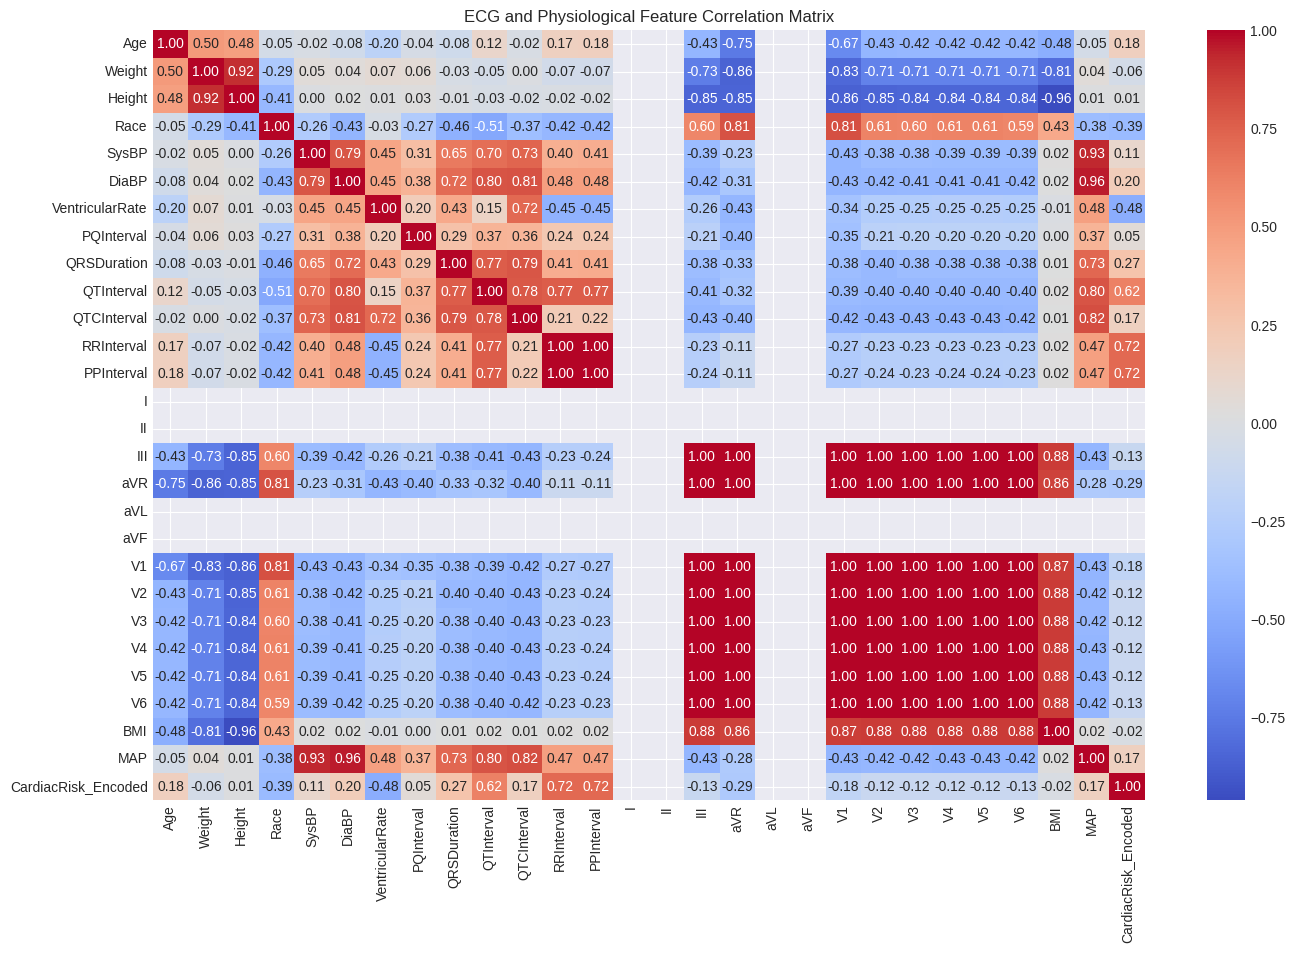

In [253]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    "ECG and Physiological Feature Correlation Matrix"
)

plt.show()


In [254]:
corr_df = corr_risk.reset_index()

corr_df.columns = [
    'Feature',
    'Correlation'
]

corr_df['Correlation_Percentage'] = (
    corr_df['Correlation'].abs() * 100
)

corr_df = corr_df.sort_values(
    by='Correlation_Percentage',
    ascending=False
)

corr_df

,Feature,Correlation,Correlation_Percentage
0,CardiacRisk_Encoded,1.000000,100.000000
1,RRInterval,0.722290,72.229009
2,PPInterval,0.719827,71.982680
3,QTInterval,0.620562,62.056153
23,VentricularRate,-0.479608,47.960809
22,Race,-0.394535,39.453504
21,aVR,-0.285187,28.518652
4,QRSDuration,0.269763,26.976330
5,DiaBP,0.198278,19.827777
6,Age,0.179506,17.950564


In [255]:
print("corr_risk" in globals())

True


In [256]:
corr_matrix = pf_df.corr(
    numeric_only=True
)

In [257]:
corr_risk = corr_matrix[
    'CardiacRisk_Encoded'
].sort_values(
    ascending=False
)

print(corr_risk)

CardiacRisk_Encoded    1.000000
RRInterval             0.722290
PPInterval             0.719827
QTInterval             0.620562
QRSDuration            0.269763
DiaBP                  0.198278
Age                    0.179506
MAP                    0.166268
QTCInterval            0.166073
SysBP                  0.105679
PQInterval             0.054338
Height                 0.006403
BMI                   -0.016467
Weight                -0.055579
V2                    -0.120270
V3                    -0.122344
V5                    -0.122697
V4                    -0.122697
V6                    -0.125238
III                   -0.130255
V1                    -0.176229
aVR                   -0.285187
Race                  -0.394535
VentricularRate       -0.479608
I                           NaN
II                          NaN
aVL                         NaN
aVF                         NaN
Name: CardiacRisk_Encoded, dtype: float64


In [258]:
corr_df = corr_risk.reset_index()

corr_df.columns = [
    'Feature',
    'Correlation'
]

corr_df['Correlation_Percentage'] = (
    corr_df['Correlation'].abs() * 100
)

corr_df = corr_df.sort_values(
    by='Correlation_Percentage',
    ascending=False
)

corr_df

,Feature,Correlation,Correlation_Percentage
0,CardiacRisk_Encoded,1.000000,100.000000
1,RRInterval,0.722290,72.229009
2,PPInterval,0.719827,71.982680
3,QTInterval,0.620562,62.056153
23,VentricularRate,-0.479608,47.960809
22,Race,-0.394535,39.453504
21,aVR,-0.285187,28.518652
4,QRSDuration,0.269763,26.976330
5,DiaBP,0.198278,19.827777
6,Age,0.179506,17.950564


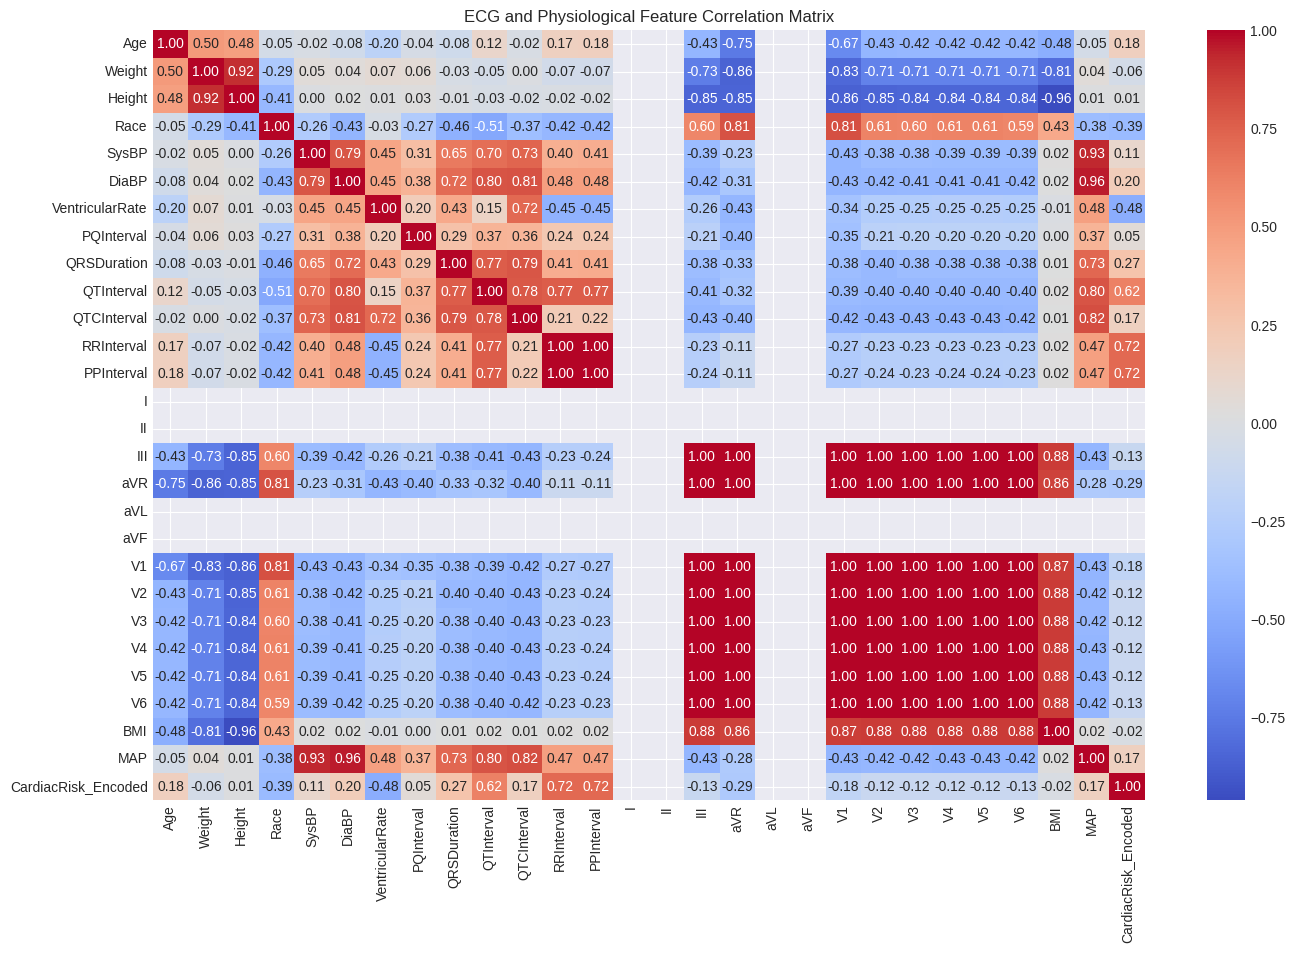

In [259]:
plt.figure(figsize=(16,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    "ECG and Physiological Feature Correlation Matrix"
)

plt.show()

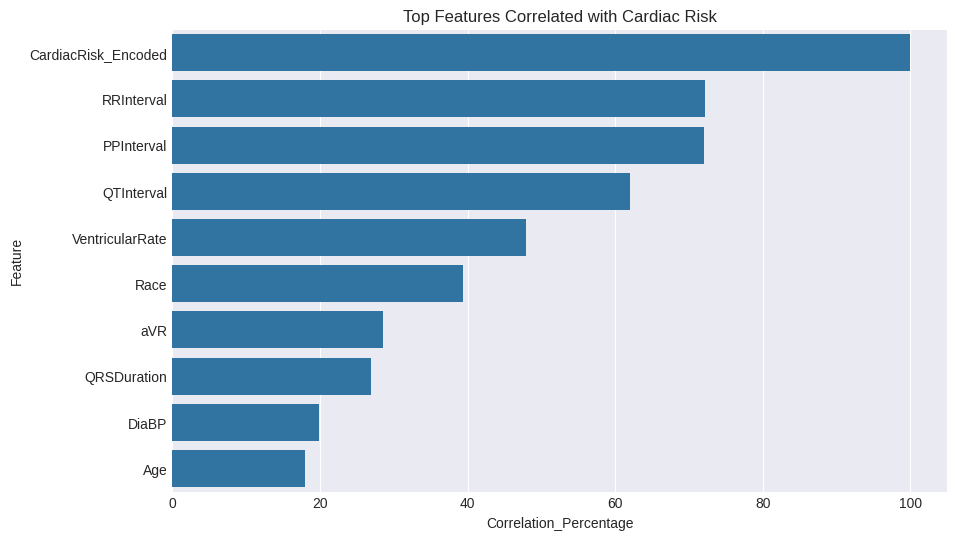

In [260]:
import matplotlib.pyplot as plt
import seaborn as sns

top_corr = corr_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_corr,
    x='Correlation_Percentage',
    y='Feature'
)

plt.title(
    'Top Features Correlated with Cardiac Risk'
)

plt.show()

In [261]:
top_features = corr_df[
    ['Feature','Correlation_Percentage']
].head(10)

print(top_features)

                Feature  Correlation_Percentage
0   CardiacRisk_Encoded              100.000000
1            RRInterval               72.229009
2            PPInterval               71.982680
3            QTInterval               62.056153
23      VentricularRate               47.960809
22                 Race               39.453504
21                  aVR               28.518652
4           QRSDuration               26.976330
5                 DiaBP               19.827777
6                   Age               17.950564
